# Import Packages and Load Variables

In [ ]:
import uproot
print("uproot version: ", uproot.__version__)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm
import pickle
from collections import Counter
from particle import Particle

import awkward as ak

f = uproot.open('/Users/katherinepulido/Desktop/SURPRISE_Test_Samples_v10_04_07_05_Run4b_hyper_unified_reco2_BNB_nu_NC_pi0_overlay_may8_reco2_hist_62280465_snapshot.root')
fdirt = uproot.open('/Users/katherinepulido/Downloads/SURPRISE_Test_Samples_v10_04_07_05_Run4b_hyper_unified_reco2_BNB_dirt_may8_reco2_hist_62280564_snapshot.root')
fnu = uproot.open('/Users/katherinepulido/Downloads/SURPRISE_Test_Samples_v10_04_07_05_Run4b_super_unified_reco2_BNB_nu_overlay_reco2_hist.root')

fwc_pandora = uproot.open('/Users/katherinepulido/Desktop/MicroBooNE_Photon/merged_wc_pmtinfo.root')

fdata = uproot.open('/Users/katherinepulido/Downloads/smaller_SURPRISE_BNB_data_file.root')

uproot version:  5.6.2


## Load Variables

In [3]:

T_bdt_vars = ['cosmict_flag']           # variables involved with BDT training (if you want to train your own BDT, lots of these variables will be useful)
                            # many of these variables describe specific features of the WC spacepoints using this code: https://github.com/BNLIF/wire-cell-pid/blob/master/src/NeutrinoID_nue_tagger.h
#    'single_photon_ncpi0_score',                        # here, we just include higher level outputs:
##    "nue_score",                    # BDT score for nue selection, used for the WC inclusive nueCC analysis
 #   "numu_score",                   # BDT score for numu selection, used for the WC inclusive numuCC selections
 #   "nc_delta_score",               # BDT score for NC Delta selection
 #   "nc_pio_score",                 # BDT score for NC pi0 selection
 #   "numu_cc_flag",                 # flag, -1 means not generic selected, 0 means generic selected, 1 means cut-based numuCC selected. We often use "numu_cc_flag >= 0" to apply generic neutrino selection.
    
#]

T_eval_vars = [             # variables involved with low level reconstruction and truth information
    "run",                         # run number
    "subrun",                       # subrun number
    "event",                        # event number
    "match_isFC",                   # reconstructed cluster is fully contained (FC), boolean
    "truth_nuEnergy",               # true neutrino energy (MeV)
    "truth_nuPdg",                  # true neutrino pdg code
    "truth_isCC",                   # true interaction type is charged current, boolean
    "match_completeness_energy",    # the true energy deposited in the clusters that are 3D-matched with the reconstructed neutrino clusters (MeV)
    "truth_energyInside",           # the true energy deposited in the TPC Fiducial Volume (MeV)
    "truth_vtxInside",              # boolean, true neutrino vertex is inside the TPC Fiducial Volume
    "truth_vtxX",                   # true neutrino vertex x (cm)
    "truth_vtxY",                   # true neutrino vertex y (cm)
    "truth_vtxZ",                   # true neutrino vertex z (cm)
    "weight_cv",                    # GENIE MicroBooNE tune event weight (which should be corrected by also using weight_spline)
    "weight_spline",                # additional weight to correct the GENIE tune for certain events
    'flash_measPe',
    'flash_predPe',
]
T_eval_data_vars = [        # same as above, but for data files we do not attempt to load any truth information
    "run",
    "subrun",
    "event",
    "match_isFC",
]

T_kine_vars = [             # variables involved with kinematic reconstruction
    "kine_reco_Enu",                # reconstructed neutrino energy (MeV). "kine_reco_Enu > 0" is another way to apply generic neutrino selection.
    "kine_energy_particle",         # energy of each reco particle
    "kine_particle_type", # pdg code of each reco particle
    "kine_pio_mass",
    "kine_pio_energy_2",
    "kine_pio_flag"
]

T_pf_vars = [               # variables involved with individual particles
    "truth_NprimPio",
    "truth_NCDelta",
    "reco_nuvtxX",
    "reco_nuvtxY",
    "reco_nuvtxZ",
    "reco_muonMomentum",            # reconstructed muon momentum 4-vector (p_x, p_y, p_z, p_t), in (GeV/c, GeV/c, GeV/c, GeV)
    "reco_showerMomentum",          # reconstructed primary shower momentum 4-vector (p_x, p_y, p_z, p_t), in (GeV/c, GeV/c, GeV/c, GeV)
    "reco_showervtxX",
    "reco_showervtxY",
    "reco_showervtxZ",

    # truth shower = xyz ke

    'truth_corr_showervtxX', 
    'truth_corr_showervtxY', 
    'truth_corr_showervtxZ', 
    'truth_showerKE',

    # These variables are related to individual true particles
    "truth_Ntrack",
    "truth_id",
    "truth_pdg",
    "truth_mother",
    "truth_startMomentum",
    "truth_startXYZT",
    "truth_endXYZT",

    # These variables are related to individual reco particles
    "reco_Ntrack",
    "reco_id",
    "reco_pdg",
    "reco_mother",
    "reco_startMomentum",
    "reco_startXYZT",
    "reco_endXYZT",
    "Ph_Tot", 
    'PMT_Amp', # Amplitude of the PMT pulse if PE equivalent.
    'PMT_Time', # Time of the PMT pulse in ns.
    'RWM_Time', # time the RWM pulse arrived in ns. This serves as your “t0” and is always 0 for MC
    'PMT_Sat', # flag indicating if the given PMT was saturated (1) or not (0)
    'PMT_TimeDL', # Amount of time the “first photon” propagated before hitting the PMT. This is used to obtain the time for the event and reveal the beam structure.
    'PMT_TimeDP', # Amount of time daughter particle that produced the “first photon” propagated before hitting the PMT. This is used to obtain the time for the event and reveal the beam structure.
    'PMT_TimeProp', # Sum of the previous two variables.
    'PMT_ID' # ID of the PMT, useful for bookkeeping an needed to determine its location if you are going to recalculate and times.
]

T_pf_data_vars = [          # same as above, but for data files we do not attempt to load any truth information
    "reco_nuvtxX",
    "reco_nuvtxY",
    "reco_nuvtxZ",
    "reco_muonMomentum",
    "reco_showerMomentum",
    "reco_showervtxX",
    "reco_showervtxY",
    "reco_showervtxZ",
    "reco_Ntrack",
    "reco_id",
    "reco_pdg",
    "reco_mother",
    "reco_startMomentum",
    "reco_startXYZT",
    "reco_endXYZT",
    'kine_reco_Enu'
]

blip_vars = [
    "nblips_saved",
    "blip_x",
    "blip_y",
    "blip_z",
    #"blip_size",
    "blip_energy",
    "blip_charge",
    "blip_nplanes",
    "blip_proxtrkdist",
    "blip_proxtrkid",
    "blip_touchtrk",
    "blip_touchtrkid",
    #"blip_badwirefrac",
    "blip_pl0_nwires",
    "blip_pl1_nwires",
    "blip_pl2_nwires",
    "blip_pl0_bydeadwire",
    "blip_pl1_bydeadwire",
    "blip_pl2_bydeadwire",
    #"blip_pl0_centerwire",
    #"blip_pl1_centerwire",
    #"blip_pl2_centerwire",
    "blip_true_g4id",
    "blip_true_pdg",
    "blip_true_energy",
]

CRT_vars = [
    'crtveto', # closest distance between shw start and space points to 
    'CosmicIP',
    '_closestNuCosmicDist',
    'crthitpe',
]

PMT_vars = [
    'flash_pe_flash_matching_v', # vector of photo electrons 
    'flash_pe_flash_matching', # sum of above vector
    'slice_pe_flash_matching_v', # vector of predicted photoelectrons ? 
    'flash_time_flash_matching', # 
    'flash_y_flash_matching',
    'flash_z_flash_matching',
    'flash_timewidth_flash_matching',
    'flash_ywidth_flash_matching',
    'flash_zwidth_flash_matching',
    'nu_flashmatch_score',
    'nu_centerX',
    'nu_centerY',
    'nu_centerZ',
    'best_cosmic_flashmatch_score',
]

spacepoints = [
    'Trecchargeblob_spacepoints_x',
    'Trecchargeblob_spacepoints_y',
    'Trecchargeblob_spacepoints_z',
    'Trecchargeblob_spacepoints_q'
]

vars = {}
vars.update(f["wcpselection"]["T_BDTvars"].arrays(T_bdt_vars, library="np"))
vars.update(f["wcpselection"]["T_eval"].arrays(T_eval_vars, library="np"))
vars.update(f["wcpselection"]["T_KINEvars"].arrays(T_kine_vars, library="np"))
vars.update(f["wcpselection"]["T_PFeval"].arrays(T_pf_vars, library="np"))
vars.update(f["nuselection"]["NeutrinoSelectionFilter"].arrays(blip_vars, library="np"))
vars.update(f["nuselection"]["NeutrinoSelectionFilter"].arrays(PMT_vars, library="np"))
vars.update(f["nuselection"]["NeutrinoSelectionFilter"].arrays(CRT_vars, library="np"))
vars.update(f["wcpselection"]["T_spacepoints"].arrays(spacepoints, library="np"))

vars.update(f["wcpselection"]["T_BDTvars"]['shw_sp_n_20mev_showers'].arrays(library="np"))
vars.update(f["wcpselection"]["T_BDTvars"]['shw_sp_20mev_showers'].arrays(library="np"))

file_POT = np.sum(f["wcpselection"]["T_pot"].arrays("pot_tor875good", library="np")["pot_tor875good"])
for col in vars:
    vars[col] = vars[col].tolist()
wc_df = pd.DataFrame(vars)

In [ ]:
T_bdt_vars = []              # variables involved with BDT training (if you want to train your own BDT, lots of these variables will be useful)
                            # many of these variables describe specific features of the WC spacepoints using this code: https://github.com/BNLIF/wire-cell-pid/blob/master/src/NeutrinoID_nue_tagger.h
#    'single_photon_ncpi0_score',                        # here, we just include higher level outputs:
##    "nue_score",                    # BDT score for nue selection, used for the WC inclusive nueCC analysis
 #   "numu_score",                   # BDT score for numu selection, used for the WC inclusive numuCC selections
 #   "nc_delta_score",               # BDT score for NC Delta selection
 #   "nc_pio_score",                 # BDT score for NC pi0 selection
 #   "numu_cc_flag",                 # flag, -1 means not generic selected, 0 means generic selected, 1 means cut-based numuCC selected. We often use "numu_cc_flag >= 0" to apply generic neutrino selection.
#]

T_eval_vars = [             # variables involved with low level reconstruction and truth information
    "run",                         # run number
    "subrun",                       # subrun number
    "event",                        # event number
    "match_isFC",                   # reconstructed cluster is fully contained (FC), boolean
    "truth_nuEnergy",               # true neutrino energy (MeV)
    "truth_nuPdg",                  # true neutrino pdg code
    "truth_isCC",                   # true interaction type is charged current, boolean
    "match_completeness_energy",    # the true energy deposited in the clusters that are 3D-matched with the reconstructed neutrino clusters (MeV)
    "truth_energyInside",           # the true energy deposited in the TPC Fiducial Volume (MeV)
    "truth_vtxInside",              # boolean, true neutrino vertex is inside the TPC Fiducial Volume
    "truth_vtxX",                   # true neutrino vertex x (cm)
    "truth_vtxY",                   # true neutrino vertex y (cm)
    "truth_vtxZ",                   # true neutrino vertex z (cm)
    "weight_cv",                    # GENIE MicroBooNE tune event weight (which should be corrected by also using weight_spline)
    "weight_spline",                # additional weight to correct the GENIE tune for certain events
    'flash_measPe',
    'flash_predPe',    
]
T_eval_data_vars = [        # same as above, but for data files we do not attempt to load any truth information
    "run",
    "subrun",
    "event",
    "match_isFC",
]

T_kine_vars = [             # variables involved with kinematic reconstruction
    "kine_reco_Enu",                # reconstructed neutrino energy (MeV). "kine_reco_Enu > 0" is another way to apply generic neutrino selection.
    "kine_energy_particle",         # energy of each reco particle
    "kine_particle_type", # pdg code of each reco particle
    "kine_pio_mass",
    "kine_pio_energy_2",
    "kine_pio_flag"
]

T_pf_vars = [               # variables involved with individual particles
    "truth_NprimPio",
    "truth_NCDelta",
    "reco_nuvtxX",
    "reco_nuvtxY",
    "reco_nuvtxZ",
    "reco_muonMomentum",            # reconstructed muon momentum 4-vector (p_x, p_y, p_z, p_t), in (GeV/c, GeV/c, GeV/c, GeV)
    "reco_showerMomentum",          # reconstructed primary shower momentum 4-vector (p_x, p_y, p_z, p_t), in (GeV/c, GeV/c, GeV/c, GeV)
    "reco_showervtxX",
    "reco_showervtxY",
    "reco_showervtxZ",

    # truth shower = xyz ke

    'truth_corr_showervtxX', 
    'truth_corr_showervtxY', 
    'truth_corr_showervtxZ', 
    'truth_showerKE',

    # These variables are related to individual true particles
    "truth_Ntrack",
    "truth_id",
    "truth_pdg",
    "truth_mother",
    "truth_startMomentum",
    "truth_startXYZT",
    "truth_endXYZT",

    # These variables are related to individual reco particles
    "reco_Ntrack",
    "reco_id",
    "reco_pdg",
    "reco_mother",
    "reco_startMomentum",
    "reco_startXYZT",
    "reco_endXYZT",
    "Ph_Tot", 
    'PMT_Amp', # Amplitude of the PMT pulse if PE equivalent.
    'PMT_Time', # Time of the PMT pulse in ns.
    'RWM_Time', # time the RWM pulse arrived in ns. This serves as your “t0” and is always 0 for MC
    'PMT_Sat', # flag indicating if the given PMT was saturated (1) or not (0)
    'PMT_TimeDL', # Amount of time the “first photon” propagated before hitting the PMT. This is used to obtain the time for the event and reveal the beam structure.
    'PMT_TimeDP', # Amount of time daughter particle that produced the “first photon” propagated before hitting the PMT. This is used to obtain the time for the event and reveal the beam structure.
    'PMT_TimeProp', # Sum of the previous two variables.
    'PMT_ID' # ID of the PMT, useful for bookkeeping an needed to determine its location if you are going to recalculate and times.
]

T_pf_data_vars = [          # same as above, but for data files we do not attempt to load any truth information
    "reco_nuvtxX",
    "reco_nuvtxY",
    "reco_nuvtxZ",
    "reco_muonMomentum",
    "reco_showerMomentum",
    "reco_showervtxX",
    "reco_showervtxY",
    "reco_showervtxZ",
    "reco_Ntrack",
    "reco_id",
    "reco_pdg",
    "reco_mother",
    "reco_startMomentum",
    "reco_startXYZT",
    "reco_endXYZT",
    'kine_reco_Enu'
]

blip_vars = [
    "nblips_saved",
    "blip_x",
    "blip_y",
    "blip_z",
    #"blip_size",
    "blip_energy",
    "blip_charge",
    "blip_nplanes",
    "blip_proxtrkdist",
    "blip_proxtrkid",
    "blip_touchtrk",
    "blip_touchtrkid",
    #"blip_badwirefrac",
    "blip_pl0_nwires",
    "blip_pl1_nwires",
    "blip_pl2_nwires",
    "blip_pl0_bydeadwire",
    "blip_pl1_bydeadwire",
    "blip_pl2_bydeadwire",
    #"blip_pl0_centerwire",
    #"blip_pl1_centerwire",
    #"blip_pl2_centerwire",
    "blip_true_g4id",
    "blip_true_pdg",
    "blip_true_energy",
]

# CRT and light variables

CRT_vars = [
    'crtveto', # closest distance between shw start and space points to 
    'CosmicIP',
    '_closestNuCosmicDist',
    'crthitpe',
]

PMT_vars = [
    'flash_pe_flash_matching_v', # vector of photo electrons 
    'flash_pe_flash_matching', # sum of above vector
    'slice_pe_flash_matching_v', # vector of predicted photoelectrons ? 
    'flash_time_flash_matching', # 
    'flash_y_flash_matching',
    'flash_z_flash_matching',
    'flash_timewidth_flash_matching',
    'flash_ywidth_flash_matching',
    'flash_zwidth_flash_matching',
    'nu_flashmatch_score',
    'nu_centerX',
    'nu_centerY',
    'nu_centerZ',
    'best_cosmic_flashmatch_score',
]

spacepoints = [
    'Trecchargeblob_spacepoints_x',
    'Trecchargeblob_spacepoints_y',
    'Trecchargeblob_spacepoints_z',
    'Trecchargeblob_spacepoints_q'
]

vars = {}
vars.update(fdirt["nuselection"]["NeutrinoSelectionFilter"].arrays(PMT_vars, library="np"))
vars.update(fdirt["wcpselection"]["T_BDTvars"].arrays(T_bdt_vars, library="np"))
vars.update(fdirt["wcpselection"]["T_eval"].arrays(T_eval_vars, library="np"))
vars.update(fdirt["wcpselection"]["T_KINEvars"].arrays(T_kine_vars, library="np"))
vars.update(fdirt["wcpselection"]["T_PFeval"].arrays(T_pf_vars, library="np"))
vars.update(fdirt["wcpselection"]["T_BDTvars"]['shw_sp_n_20mev_showers'].arrays(library="np"))

vars.update(fdirt["nuselection"]["NeutrinoSelectionFilter"].arrays(blip_vars, library="np"))
vars.update(fdirt["nuselection"]["NeutrinoSelectionFilter"].arrays(CRT_vars, library="np"))
vars.update(fdirt["wcpselection"]["T_spacepoints"].arrays(spacepoints, library="np"))

vars.update(fdirt["wcpselection"]["T_BDTvars"]['shw_sp_20mev_showers'].arrays(library="np"))
vars.update(fdirt["nuselection"]["NeutrinoSelectionFilter"].arrays(blip_vars, library="np"))
file_POT = np.sum(fdirt["wcpselection"]["T_pot"].arrays("pot_tor875good", library="np")["pot_tor875good"])

for col in vars:
    vars[col] = vars[col].tolist()
dirt_df = pd.DataFrame(vars)


In [5]:
T_bdt_vars = []              # variables involved with BDT training (if you want to train your own BDT, lots of these variables will be useful)
                            # many of these variables describe specific features of the WC spacepoints using this code: https://github.com/BNLIF/wire-cell-pid/blob/master/src/NeutrinoID_nue_tagger.h
#    'single_photon_ncpi0_score',                        # here, we just include higher level outputs:
##    "nue_score",                    # BDT score for nue selection, used for the WC inclusive nueCC analysis
 #   "numu_score",                   # BDT score for numu selection, used for the WC inclusive numuCC selections
 #   "nc_delta_score",               # BDT score for NC Delta selection
 #   "nc_pio_score",                 # BDT score for NC pi0 selection
 #   "numu_cc_flag",                 # flag, -1 means not generic selected, 0 means generic selected, 1 means cut-based numuCC selected. We often use "numu_cc_flag >= 0" to apply generic neutrino selection.
#]

T_eval_vars = [             # variables involved with low level reconstruction and truth information
    "run",                         # run number
    "subrun",                       # subrun number
    "event",                        # event number
    "match_isFC",                   # reconstructed cluster is fully contained (FC), boolean
    "truth_nuEnergy",               # true neutrino energy (MeV)
    "truth_nuPdg",                  # true neutrino pdg code
    "truth_isCC",                   # true interaction type is charged current, boolean
    "match_completeness_energy",    # the true energy deposited in the clusters that are 3D-matched with the reconstructed neutrino clusters (MeV)
    "truth_energyInside",           # the true energy deposited in the TPC Fiducial Volume (MeV)
    "truth_vtxInside",              # boolean, true neutrino vertex is inside the TPC Fiducial Volume
    "truth_vtxX",                   # true neutrino vertex x (cm)
    "truth_vtxY",                   # true neutrino vertex y (cm)
    "truth_vtxZ",                   # true neutrino vertex z (cm)
    "weight_cv",                    # GENIE MicroBooNE tune event weight (which should be corrected by also using weight_spline)
    "weight_spline",                # additional weight to correct the GENIE tune for certain events
    'flash_measPe',
    'flash_predPe',
]
T_eval_data_vars = [        # same as above, but for data files we do not attempt to load any truth information
    "run",
    "subrun",
    "event",
    "match_isFC",
]

T_kine_vars = [             # variables involved with kinematic reconstruction
    "kine_reco_Enu",                # reconstructed neutrino energy (MeV). "kine_reco_Enu > 0" is another way to apply generic neutrino selection.
    "kine_energy_particle",         # energy of each reco particle
    "kine_particle_type", # pdg code of each reco particle
    "kine_pio_mass",
    "kine_pio_energy_2",
    "kine_pio_flag"
]

T_pf_vars = [               # variables involved with individual particles
    "truth_NprimPio",
    "truth_NCDelta",
    "reco_nuvtxX",
    "reco_nuvtxY",
    "reco_nuvtxZ",
    "reco_muonMomentum",            # reconstructed muon momentum 4-vector (p_x, p_y, p_z, p_t), in (GeV/c, GeV/c, GeV/c, GeV)
    "reco_showerMomentum",          # reconstructed primary shower momentum 4-vector (p_x, p_y, p_z, p_t), in (GeV/c, GeV/c, GeV/c, GeV)
    "reco_showervtxX",
    "reco_showervtxY",
    "reco_showervtxZ",

    # truth shower = xyz ke

    'truth_corr_showervtxX', 
    'truth_corr_showervtxY', 
    'truth_corr_showervtxZ', 
    'truth_showerKE',

    # These variables are related to individual true particles
    "truth_Ntrack",
    "truth_id",
    "truth_pdg",
    "truth_mother",
    "truth_startMomentum",
    "truth_startXYZT",
    "truth_endXYZT",

    # These variables are related to individual reco particles
    "reco_Ntrack",
    "reco_id",
    "reco_pdg",
    "reco_mother",
    "reco_startMomentum",
    "reco_startXYZT",
    "reco_endXYZT",
    "Ph_Tot", 
    'PMT_Amp', # Amplitude of the PMT pulse if PE equivalent.
    'PMT_Time', # Time of the PMT pulse in ns.
    'RWM_Time', # time the RWM pulse arrived in ns. This serves as your “t0” and is always 0 for MC
    'PMT_Sat', # flag indicating if the given PMT was saturated (1) or not (0)
    'PMT_TimeDL', # Amount of time the “first photon” propagated before hitting the PMT. This is used to obtain the time for the event and reveal the beam structure.
    'PMT_TimeDP', # Amount of time daughter particle that produced the “first photon” propagated before hitting the PMT. This is used to obtain the time for the event and reveal the beam structure.
    'PMT_TimeProp', # Sum of the previous two variables.
    'PMT_ID' # ID of the PMT, useful for bookkeeping an needed to determine its location if you are going to recalculate and times.
]

T_pf_data_vars = [          # same as above, but for data files we do not attempt to load any truth information
    "reco_nuvtxX",
    "reco_nuvtxY",
    "reco_nuvtxZ",
    "reco_muonMomentum",
    "reco_showerMomentum",
    "reco_showervtxX",
    "reco_showervtxY",
    "reco_showervtxZ",
    "reco_Ntrack",
    "reco_id",
    "reco_pdg",
    "reco_mother",
    "reco_startMomentum",
    "reco_startXYZT",
    "reco_endXYZT",
    'kine_reco_Enu'
]

blip_vars = [
    #"nblips_saved",
    "blip_x",
    "blip_y",
    "blip_z",
    #"blip_size",
    "blip_energy",
    "blip_charge",
    "blip_nplanes",
    "blip_proxtrkdist",
    "blip_proxtrkid",
    "blip_touchtrk",
    "blip_touchtrkid",
    #"blip_badwirefrac",
    "blip_pl0_nwires",
    "blip_pl1_nwires",
    "blip_pl2_nwires",
    "blip_pl0_bydeadwire",
    "blip_pl1_bydeadwire",
    "blip_pl2_bydeadwire",
    #"blip_pl0_centerwire",
    #"blip_pl1_centerwire",
    #"blip_pl2_centerwire",
    "blip_true_g4id",
    "blip_true_pdg",
    "blip_true_energy",
]

# CRT and light variables

CRT_vars = [
    'crtveto', # closest distance between shw start and space points to 
    'CosmicIP',
    '_closestNuCosmicDist',
    'crthitpe',
]

PMT_vars = [
    'flash_pe_flash_matching_v', # vector of photo electrons 
    'flash_pe_flash_matching', # sum of above vector
    'slice_pe_flash_matching_v', # vector of predicted photoelectrons ? 
    'flash_time_flash_matching', # 
    'flash_y_flash_matching',
    'flash_z_flash_matching',
    'flash_timewidth_flash_matching',
    'flash_ywidth_flash_matching',
    'flash_zwidth_flash_matching',
    'nu_flashmatch_score',
    'nu_centerX',
    'nu_centerY',
    'nu_centerZ',
    'best_cosmic_flashmatch_score',
]

spacepoints = [
    'Trecchargeblob_spacepoints_x',
    'Trecchargeblob_spacepoints_y',
    'Trecchargeblob_spacepoints_z',
    'Trecchargeblob_spacepoints_q'
]

vars = {}
vars.update(fnu["nuselection"]["NeutrinoSelectionFilter"].arrays(PMT_vars, library="np"))
vars.update(fnu["wcpselection"]["T_BDTvars"].arrays(T_bdt_vars, library="np"))
vars.update(fnu["wcpselection"]["T_eval"].arrays(T_eval_vars, library="np"))
vars.update(fnu["wcpselection"]["T_KINEvars"].arrays(T_kine_vars, library="np"))
vars.update(fnu["wcpselection"]["T_PFeval"].arrays(T_pf_vars, library="np"))

#vars.update(fnu["nuselection"]["NeutrinoSelectionFilter"].arrays(blip_vars, library="np"))
vars.update(fnu["nuselection"]["NeutrinoSelectionFilter"].arrays(CRT_vars, library="np"))
vars.update(fnu["wcpselection"]["T_spacepoints"].arrays(spacepoints, library="np"))

vars.update(fnu["wcpselection"]["T_BDTvars"]['shw_sp_n_20mev_showers'].arrays(library="np"))
vars.update(fnu["wcpselection"]["T_BDTvars"]['shw_sp_20mev_showers'].arrays(library="np"))
#vars.update(fnu["nuselection"]["NeutrinoSelectionFilter"].arrays(blip_vars, library="np"))
file_POT = np.sum(fnu["wcpselection"]["T_pot"].arrays("pot_tor875good", library="np")["pot_tor875good"])

for col in vars:
    vars[col] = vars[col].tolist()
nu_df = pd.DataFrame(vars)


## Post processing all files

In [6]:
# lee's code unedited

import sys
import uproot
import numpy as np
from tqdm import tqdm
import pickle
import argparse
import pandas as pd

#from helpers.plotting_3d import generate_box_edge_points, plot_event
#from helpers.spacepoint_sampling import fps_clustering_downsample, get_min_dists, energy_weighted_density_sampling


def get_vtx_and_true_gamma_info(f, num_events):
    # loads non-spacepoint information from the root file, including RSE, true nu vtx, reco nu vtx, and true gamma info

    print("getting true gamma information")

    rse = f["wcpselection"]["T_eval"].arrays(["run", "subrun", "event"], library="np", entry_start=0, entry_stop=num_events)
    true_nu_vtx = f["wcpselection"]["T_eval"].arrays(["truth_vtxX", "truth_vtxY", "truth_vtxZ"], library="np", entry_start=0, entry_stop=num_events)
    true_nu_vtx = np.stack([true_nu_vtx["truth_vtxX"], true_nu_vtx["truth_vtxY"], true_nu_vtx["truth_vtxZ"]], axis=-1)
    reco_nu_vtx = f["wcpselection"]["T_PFeval"].arrays(["reco_nuvtxX", "reco_nuvtxY", "reco_nuvtxZ"], library="np", entry_start=0, entry_stop=num_events)
    reco_nu_vtx = np.stack([reco_nu_vtx["reco_nuvtxX"], reco_nu_vtx["reco_nuvtxY"], reco_nu_vtx["reco_nuvtxZ"]], axis=-1)

    true_gamma_info_df = pd.DataFrame({
        "run": rse["run"],
        "subrun": rse["subrun"],
        "event": rse["event"],
        "true_nu_vtx_x": true_nu_vtx[:, 0],
        "true_nu_vtx_y": true_nu_vtx[:, 1],
        "true_nu_vtx_z": true_nu_vtx[:, 2],
        "reco_nu_vtx_x": reco_nu_vtx[:, 0],
        "reco_nu_vtx_y": reco_nu_vtx[:, 1],
        "reco_nu_vtx_z": reco_nu_vtx[:, 2],
    })

    # these variables will be used to define signal vs background
    # only includes gammas from a pi0 (primary or non-primary)
    true_num_gamma = []
    true_gamma_energies = []
    true_gamma_pairconversion_xs = []
    true_gamma_pairconversion_ys = []
    true_gamma_pairconversion_zs = []
    
    true_gamma_pairconversion_pxs = []
    true_gamma_pairconversion_pys = []
    true_gamma_pairconversion_pzs = []
    true_gamma_pairconversion_engys = []
    
    true_num_gamma_pairconvert = []
    true_num_gamma_pairconvert_in_FV = []
    true_num_gamma_pairconvert_in_FV_20_MeV = []
    true_momentum_of_original = []
    pi0_inside = np.full(num_events, True, dtype=bool)

    wc_geant_dic = f["wcpselection"]["T_PFeval"].arrays(["truth_id", "truth_mother", "truth_pdg", "truth_startMomentum", "truth_startXYZT", "truth_endXYZT"], library="np")

    for event_i in tqdm(range(num_events)):
        
        num_particles = len(wc_geant_dic["truth_id"][event_i])
                
        curr_true_num_gamma = 0
        curr_true_gamma_energies = []
        curr_true_gamma_pairconversion_xs = []
        curr_true_gamma_pairconversion_ys = []
        curr_true_gamma_pairconversion_zs = []
        
        curr_true_gamma_pairconversion_pxs = []
        curr_true_gamma_pairconversion_pys = []
        curr_true_gamma_pairconversion_pzs = []
        curr_true_gamma_pairconversion_engys = []
        
        curr_original_momentum = []
        curr_true_num_gamma_pairconvert = 0
        curr_true_num_gamma_pairconvert_in_FV = 0
        curr_true_num_gamma_pairconvert_in_FV_20_MeV = 0

        pi0_ids = []
        for i in range(num_particles):
            if wc_geant_dic["truth_pdg"][event_i][i] == 111:
                pi0_ids.append(wc_geant_dic["truth_id"][event_i][i])
                pi0x, pi0y, pi0z, _ = wc_geant_dic["truth_startXYZT"][event_i][i]
                if not (-1.0 <= pi0x <= 254.3 and -115.0 <= pi0y <= 117.0 and 0.6 <= pi0z <= 1036.4):
                    pi0_inside[event_i] = False
                

        primary_or_pi0_gamma_ids = []
        for i in range(num_particles):
            if wc_geant_dic["truth_mother"][event_i][i] in pi0_ids or wc_geant_dic["truth_mother"][event_i][i] == 0: # this is a daughter of a pi0 or a primary gamma (most likely from an eta or Delta radiative)
                if wc_geant_dic["truth_pdg"][event_i][i] == 22: # this is a gamma from a pi0
                    curr_true_num_gamma += 1
                    curr_true_gamma_energies.append(wc_geant_dic["truth_startMomentum"][event_i][i][3])
                    curr_original_momentum.append([wc_geant_dic["truth_startMomentum"][event_i][i][0], wc_geant_dic["truth_startMomentum"][event_i][i][1], wc_geant_dic["truth_startMomentum"][event_i][i][2]])
                    primary_or_pi0_gamma_ids.append(wc_geant_dic["truth_id"][event_i][i])


        # looking for the first point where the photon transfers more than half its energy to daughter charged particles
        # should be 100% for pair production, but compton scatters can also effectively cause the start of a shower
        # daughter particles could disappear from the geant tree even if it pair converts, that type of photon won't be included here

        # looking for pair conversion points, allowing for the possibility of Compton scattering
        for i in range(num_particles):
            if wc_geant_dic["truth_id"][event_i][i] in primary_or_pi0_gamma_ids: # pi0/primary -> gamma

                original_gamma_energy = wc_geant_dic["truth_startMomentum"][event_i][i][3]
                px = wc_geant_dic["truth_startMomentum"][event_i][i][0]
                py = wc_geant_dic["truth_startMomentum"][event_i][i][1]
                pz = wc_geant_dic["truth_startMomentum"][event_i][i][2]
                cumulative_deposited_energy = 0
                curr_id = wc_geant_dic["truth_id"][event_i][i]
                # loop until we deposit enough charged energy, or run out of daughters
                loop_counter = 0
                while True:
                    loop_counter += 1
                    if loop_counter > 100:
                        print(f"infinite loop detected in event {event_i}")
                        break

                    
                    descendants_ids = []
                    descendants_indices = []
                    descendants_pdgs = []
                    for j in range(num_particles):
                        if wc_geant_dic["truth_mother"][event_i][j] == curr_id: # pi0/primary -> gamma -> this particle
                            descendants_ids.append(wc_geant_dic["truth_id"][event_i][j])
                            descendants_indices.append(j)
                            descendants_pdgs.append(wc_geant_dic["truth_pdg"][event_i][j])

                    for descendant_i in range(len(descendants_indices)):
                        if abs(descendants_pdgs[descendant_i]) == 11: # electron/positron daughter
                            cumulative_deposited_energy += wc_geant_dic["truth_startMomentum"][event_i][descendants_indices[descendant_i]][3]

                    if cumulative_deposited_energy > original_gamma_energy / 2: # it has deposited enough energy to effectively count as a pair conversion
                        break

                    if 22 in descendants_pdgs: # found a compton scatter, hasn't deposited enough energy yet, loop to consider that next photon
                        curr_id = descendants_ids[descendants_pdgs.index(22)]
                        #print("doing a compton scatter")
                    else: # no compton scatter, we're done, it's either a pair conversion or photoelectric absorption or a Geant tree deletion
                        break

                if cumulative_deposited_energy < original_gamma_energy / 2: # weird event, didn't deposit enough energy to count as a pair conversion
                    #print(f"weird event, no daughter photon, but also deposited less than half the energy: {cumulative_deposited_energy} / {original_gamma_energy}, {count}")
                    pass
                else:
                    curr_true_gamma_pairconversion_xs.append(wc_geant_dic["truth_startXYZT"][event_i][descendants_indices[0]][0])
                    curr_true_gamma_pairconversion_ys.append(wc_geant_dic["truth_startXYZT"][event_i][descendants_indices[0]][1])
                    curr_true_gamma_pairconversion_zs.append(wc_geant_dic["truth_startXYZT"][event_i][descendants_indices[0]][2])
                    
                    curr_true_gamma_pairconversion_pxs.append(wc_geant_dic["truth_startMomentum"][event_i][descendants_indices[0]][0])
                    curr_true_gamma_pairconversion_pys.append(wc_geant_dic["truth_startMomentum"][event_i][descendants_indices[0]][1])
                    curr_true_gamma_pairconversion_pzs.append(wc_geant_dic["truth_startMomentum"][event_i][descendants_indices[0]][2])
                    curr_true_gamma_pairconversion_engys.append(wc_geant_dic["truth_startMomentum"][event_i][descendants_indices[0]][3])
                    
                    
                    
                    curr_true_num_gamma_pairconvert += 1

                    if -1 < curr_true_gamma_pairconversion_xs[-1] <= 254.3 and -115.0 < curr_true_gamma_pairconversion_ys[-1] <= 117.0 and 0.6 < curr_true_gamma_pairconversion_zs[-1] <= 1036.4:
                        curr_true_num_gamma_pairconvert_in_FV += 1

                        if original_gamma_energy > 0.02:
                            curr_true_num_gamma_pairconvert_in_FV_20_MeV += 1


        true_num_gamma.append(curr_true_num_gamma)
        true_gamma_energies.append(curr_true_gamma_energies)
        true_gamma_pairconversion_xs.append(curr_true_gamma_pairconversion_xs)
        true_gamma_pairconversion_ys.append(curr_true_gamma_pairconversion_ys)
        true_gamma_pairconversion_zs.append(curr_true_gamma_pairconversion_zs)
        
        true_gamma_pairconversion_pxs.append(curr_true_gamma_pairconversion_pxs)
        true_gamma_pairconversion_pys.append(curr_true_gamma_pairconversion_pys)
        true_gamma_pairconversion_pzs.append(curr_true_gamma_pairconversion_pzs)
        true_gamma_pairconversion_engys.append(curr_true_gamma_pairconversion_engys)
        
        
        true_num_gamma_pairconvert.append(curr_true_num_gamma_pairconvert)
        true_num_gamma_pairconvert_in_FV.append(curr_true_num_gamma_pairconvert_in_FV)
        true_num_gamma_pairconvert_in_FV_20_MeV.append(curr_true_num_gamma_pairconvert_in_FV_20_MeV)
        
        true_momentum_of_original.append(curr_original_momentum)

    true_gamma_info_df["true_num_gamma"] = true_num_gamma
    true_gamma_info_df["true_gamma_energies"] = true_gamma_energies
    true_gamma_info_df["true_gamma_pairconversion_xs"] = true_gamma_pairconversion_xs
    true_gamma_info_df["true_gamma_pairconversion_ys"] = true_gamma_pairconversion_ys
    true_gamma_info_df["true_gamma_pairconversion_zs"] = true_gamma_pairconversion_zs
    
    true_gamma_info_df["true_gamma_pairconversion_pxs"] = true_gamma_pairconversion_pxs
    true_gamma_info_df["true_gamma_pairconversion_pys"] = true_gamma_pairconversion_pys
    true_gamma_info_df["true_gamma_pairconversion_pzs"] = true_gamma_pairconversion_pzs
    true_gamma_info_df["true_gamma_pairconversion_engys"] = true_gamma_pairconversion_engys
    
    true_gamma_info_df["true_num_gamma_pairconvert"] = true_num_gamma_pairconvert
    true_gamma_info_df["true_num_gamma_pairconvert_in_FV"] = true_num_gamma_pairconvert_in_FV
    true_gamma_info_df["true_num_gamma_pairconvert_in_FV_20_MeV"] = true_num_gamma_pairconvert_in_FV_20_MeV
    
    true_gamma_info_df['pi0_inside'] = pi0_inside
    
    true_gamma_info_df["true_momentum_of_original"] = true_momentum_of_original

    # returning the vertex information separately, since that will be used for downsampling
    return true_nu_vtx, reco_nu_vtx, true_gamma_info_df


true_nu_vtx, reco_nu_vtx, true_gamma_info_df = get_vtx_and_true_gamma_info(f, wc_df.shape[0])
_, _, true_gamma_dirt_df = get_vtx_and_true_gamma_info(fdirt, dirt_df.shape[0])
_, _, true_gamma_nu_df = get_vtx_and_true_gamma_info(fnu, nu_df.shape[0])


#true_gamma_all_df = pd.concat([true_gamma_dirt_df, true_gamma_nu_df], axis=0, ignore_index=True)

getting true gamma information


100%|██████████| 43212/43212 [00:02<00:00, 18328.94it/s]


getting true gamma information


100%|██████████| 45159/45159 [00:00<00:00, 100127.97it/s]


getting true gamma information


100%|██████████| 99680/99680 [00:02<00:00, 38983.62it/s]


In [157]:


def do_meas_minus_pred(all_df):
    
    meas_pmt_array = all_df['flash_measPe'].to_numpy()
    pred_pmt_array = all_df["flash_predPe"].to_numpy()
    
   # pmt_amp = all_df['PMT_Amp'].to_numpy()
    # old definition
    
    meas_pmt = all_df['flash_pe_flash_matching_v'].to_numpy()
    pred_pmt = all_df['slice_pe_flash_matching_v'].to_numpy()

    measured_total_wc = np.zeros(all_df.shape[0])
    pred_total_wc = np.zeros(all_df.shape[0])

    measured_total_pandora = np.zeros(all_df.shape[0])
    pred_total_pandora = np.zeros(all_df.shape[0])

    #pmtamp_total = np.zeros(all_df.shape[0])
    
    threshold_total_wc = np.zeros(all_df.shape[0])
    threshold_total_pred_wc = np.zeros(all_df.shape[0])
    
    threshold_total_pandora = np.zeros(all_df.shape[0])
    threshold_total_pred_pandora = np.zeros(all_df.shape[0])
    
    for event_i in range(all_df.shape[0]):
        measured_total_wc[event_i] = np.sum(meas_pmt_array[event_i])
        pred_total_wc[event_i] = np.sum(pred_pmt_array[event_i])
        
        # sum just values above 2.5
        threshold_total_wc[event_i] = np.sum(meas_pmt_array[event_i][meas_pmt_array[event_i] > 2.5])
        threshold_total_pred_wc[event_i] = np.sum(pred_pmt_array[event_i][pred_pmt_array[event_i] > 2.5])
        
        #pmtamp_total[event_i] = np.sum(pmt_amp[event_i])
    
        measured_total_pandora[event_i] = np.sum(meas_pmt[event_i])
        pred_total_pandora[event_i] = np.sum(pred_pmt[event_i])  
        
        threshold_total_pandora[event_i] = np.sum(meas_pmt[event_i][meas_pmt[event_i] > 2.5])
        threshold_total_pred_pandora[event_i] = np.sum(pred_pmt[event_i][pred_pmt[event_i] > 2.5])
        
        
        #measured_total[event_i] = meas_pmt[event_i]
        #pred_total[event_i] = pred_pmt[event_i]
        
    all_df['meas_total_wc'] = measured_total_wc
    all_df['pred_total_wc'] = pred_total_wc
    
    all_df['meas_total_pandora'] = measured_total_pandora
    all_df['pred_total_pandora'] = pred_total_pandora
    
    all_df['threshold_total_pandora'] = threshold_total_pandora
    all_df['threshold_total_wc'] = threshold_total_wc

    all_df['threshold_total_pred_wc'] = threshold_total_pred_wc
    all_df['threshold_total_pred_pandora'] = threshold_total_pred_pandora
    
    
    meas_minus_pred_arr_wc = np.zeros(all_df.shape[0])
    meas_minus_pred_arr_pandora = np.zeros(all_df.shape[0])
    
    actually_meas_minus_pred_wc =  np.zeros(all_df.shape[0])
    actually_meas_minus_pred_pandora = np.zeros(all_df.shape[0])
    
    #meas_over_pred_arr = np.zeros(all_df.shape[0])

    mask = pred_total_wc != 0
    meas_minus_pred_arr_wc[mask] = (measured_total_wc[mask] - pred_total_wc[mask]) / pred_total_wc[mask]
    
    actually_meas_minus_pred_wc[mask] =  (measured_total_wc[mask] - pred_total_wc[mask])
    
    mask = pred_total_pandora != 0
    meas_minus_pred_arr_pandora[mask] = (measured_total_pandora[mask] - pred_total_pandora[mask]) / pred_total_pandora[mask]
    actually_meas_minus_pred_pandora[mask] = (measured_total_pandora[mask] - pred_total_pandora[mask])

    #meas_over_pred_arr[mask] = measured_total[mask] / pred_total[mask]

    all_df['meas_minus_pred_wc'] = meas_minus_pred_arr_wc
    all_df['meas_minus_pred_pandora'] = meas_minus_pred_arr_pandora
    
    all_df['actually_meas_minus_pred_wc'] = actually_meas_minus_pred_wc
    all_df['actually_meas_minus_pred_pandora'] = actually_meas_minus_pred_pandora

    #all_df['meas_over_pred'] = meas_over_pred_arr
    
    return all_df

In [8]:
# flag raising

def raise_flags(true_gamma_df, info_df):
    
    info_df = do_meas_minus_pred(info_df)

    true_gamma_xs = true_gamma_df["true_gamma_pairconversion_xs"].to_numpy()
    true_gamma_ys = true_gamma_df["true_gamma_pairconversion_ys"].to_numpy()
    true_gamma_zs = true_gamma_df["true_gamma_pairconversion_zs"].to_numpy()

    true_gamma_pxs = true_gamma_df["true_gamma_pairconversion_pxs"].to_numpy()
    true_gamma_pys = true_gamma_df["true_gamma_pairconversion_pys"].to_numpy()
    true_gamma_pzs = true_gamma_df["true_gamma_pairconversion_pzs"].to_numpy()
    true_gamma_engys = true_gamma_df["true_gamma_pairconversion_engys"].to_numpy()

    true_gamma_energies = true_gamma_df["true_gamma_energies"].to_numpy()

    true_nu_xs = true_gamma_df['true_nu_vtx_x'].to_numpy()
    true_nu_ys = true_gamma_df['true_nu_vtx_y'].to_numpy()
    true_nu_zs = true_gamma_df['true_nu_vtx_z'].to_numpy()

    inside = 0
    outside = 0
    both = 0

    signal_flag = np.full(info_df.shape[0], False, dtype=bool)
    background_flag = np.full(info_df.shape[0], False, dtype=bool)
    pi0_flag = np.full(info_df.shape[0], False, dtype=bool)
    good_chg_reco = np.full(info_df.shape[0], False, dtype=bool)
    
    FC_missedshw = np.full(info_df.shape[0], False, dtype=bool)
    no_missed_shw_pi0 = np.full(info_df.shape[0], False, dtype=bool)
    
    one_outside_tpc = np.full(info_df.shape[0], False, dtype=bool)
    one_inside_tpc = np.full(info_df.shape[0], False, dtype=bool)
    
    missed_shw_close_to_pmt = np.full(info_df.shape[0], False, dtype=bool) 

    outside_tpc_shw_vtxX = np.ones(info_df.shape[0])
    outside_tpc_shw_vtxY = np.ones(info_df.shape[0])
    outside_tpc_shw_vtxZ = np.ones(info_df.shape[0])
    
    truth_pi0 = info_df["truth_NprimPio"].to_numpy()

    outside_tpc_shw_px = np.zeros(info_df.shape[0])
    outside_tpc_shw_py = np.zeros(info_df.shape[0])
    outside_tpc_shw_pz = np.zeros(info_df.shape[0])
    outside_tpc_shw_e = np.zeros(info_df.shape[0])

    truth_particle_vtx_e = info_df["truth_endXYZT"].to_numpy()
    truth_momentum = info_df["truth_startMomentum"].to_numpy()

    truth_ids = info_df["truth_id"].to_numpy()
    truth_pdgs = info_df["truth_pdg"].to_numpy()
    truth_mother = info_df["truth_mother"].to_numpy()

    enu = info_df["kine_reco_Enu"].to_numpy()
    e_inside = info_df['truth_energyInside'].to_numpy()
    
    is_FC = info_df["match_isFC"].to_numpy()


    for i in tqdm(range(info_df.shape[0])):
        
        if truth_pi0[i] > 0:
            pi0_flag[i] = True
        #elif info_df.all == wc_df.all:
            #print(f'truth_NprimPio = {truth_pi0[i]}, {i} = i')
            
        if .8 * e_inside[i] < enu[i] < 1.2 * e_inside[i]:
            good_chg_reco[i] = True
        
        index_distance_list_truth_s = []
        
        one_outside_tpc[i] = False
        one_inside_tpc[i] = False
        
        one_high_energy = False
        one_low_energy = False
        
        well_contained = False
        
        if enu[i] < 0:
            continue
        
        nu_x, nu_y, nu_z = true_nu_xs[i], true_nu_ys[i], true_nu_zs[i]
        
        if (29.0 <= nu_x <= 224.3 and -85 <= nu_y <= 87.0 and 30.6 <= nu_z <= 1006.4):
            well_contained = True
        
        if len(true_gamma_xs[i]) > 0 and len(true_gamma_ys[i]) > 0 and len(true_gamma_zs[i]) > 0:
            for particle in range(len(true_gamma_xs[i])):
                x, y, z = true_gamma_xs[i][particle], true_gamma_ys[i][particle], true_gamma_zs[i][particle]
                px, py, pz, engy = true_gamma_pxs[i][particle], true_gamma_pys[i][particle], true_gamma_pzs[i][particle], true_gamma_engys[i][particle]
                if not (-1.0 <= x <= 254.3 and -115.0 <= y <= 117.0 and 0.6 <= z <= 1036.4):
                    one_outside_tpc[i] = True
                    outside_tpc_shw_vtxX[i] = x
                    outside_tpc_shw_vtxY[i] = y 
                    outside_tpc_shw_vtxZ[i] = z
                    outside_tpc_shw_px[i] = px
                    outside_tpc_shw_py[i] = py
                    outside_tpc_shw_pz[i] = pz
                    outside_tpc_shw_e[i] = engy
                    if -11.0 <= x <= 1.0:
                        missed_shw_close_to_pmt[i] = True
                        
                else:
                    one_inside_tpc[i] = True
                energy = true_gamma_energies[i][particle]
                if energy > .02:
                    one_high_energy = True
                if energy < .02: 
                    one_low_energy = True
        
        if one_outside_tpc[i]:
            outside += 1
        if one_inside_tpc[i]:
            inside += 1
        if one_outside_tpc[i] and one_inside_tpc[i]:
            both += 1
            background_flag[i] = True
            if is_FC[i]:
                FC_missedshw[i] = True
        
        #if one_high_energy and one_low_energy and not one_outside_tpc:
        if not one_outside_tpc[i] and pi0_flag[i]:
            no_missed_shw_pi0[i] = True
            if well_contained:
                signal_flag[i] = True
            


        #distance_particle_truth_end.append(index_distance_list_truth_e)

    print(f'signal percentage: {100 * np.sum(signal_flag)/info_df.shape[0]}')
    print(f'background percentage: {100 * np.sum(background_flag)/info_df.shape[0]}')


    print(np.sum(background_flag), np.sum(signal_flag))

    #info_df['signal_v1'] = signal_flag # signal_v1 should still be old definition of signal (one above 20mev, one below)
    #info_df['background_v1'] = background_flag

    info_df['signal_v2'] = signal_flag # v2 has at least 30cm of boundary and no lost shower
    info_df['background_v2'] = background_flag

    info_df['missed_photon_vtxX'] = outside_tpc_shw_vtxX
    info_df['missed_photon_vtxY'] = outside_tpc_shw_vtxY
    info_df['missed_photon_vtxZ'] = outside_tpc_shw_vtxZ
    
    info_df['missed_shw_close_to_pmt'] = missed_shw_close_to_pmt
    
    info_df['missed_photon_px'] = outside_tpc_shw_px
    info_df['missed_photon_py'] = outside_tpc_shw_py
    info_df['missed_photon_pz'] = outside_tpc_shw_pz
    info_df['missed_photon_e'] = outside_tpc_shw_e
    
    info_df['pi0_flag'] = pi0_flag
    info_df['good_chg_reco'] = good_chg_reco
    info_df['FC_missedshw'] = FC_missedshw
    info_df['no_missed_shw_pi0'] = no_missed_shw_pi0
    
    info_df['one_outside_tpc'] = one_outside_tpc
    info_df['one_inside_tpc'] = one_inside_tpc

    signal_df = info_df[info_df["signal_v2"] == True]
    background_df = info_df[info_df["background_v2"] == True]
    
    pi0_events_df = info_df[info_df['pi0_flag'] == True]

    missed_shw_events = background_df.index

    signal_and_bkgrnd_df = info_df.query("background_v2 == True or signal_v2 == True")
    
    return info_df, signal_df, background_df, missed_shw_events, signal_and_bkgrnd_df, pi0_events_df
    
pi0_df, pi0_signal, pi0_background, pi0_missed_shw, pi0_signal_and_backgound, pi0_pi0_df = raise_flags(true_gamma_info_df, wc_df)
dirt_df, dirt_signal, dirt_background, dirt_missed_shw, dirt_signal_and_background, dirt_pi0_df = raise_flags(true_gamma_dirt_df, dirt_df)
nu_df, nu_signal, nu_background, nu_missed_shw, nu_signal_and_background, nu_pi0_df = raise_flags(true_gamma_nu_df, nu_df)

#pmt_df, pmt_signal, pmt_background, pmt_missed_shw, pmt_signal_and_background, pmt_pi0_df = raise_flags(true_gamma_pmt_df, wc_pandora_df)

print(f'dirt pi0 events: {dirt_pi0_df.shape}, pi0 overlay: {pi0_pi0_df.shape}, nu overlay: {nu_pi0_df.shape}')

print(f'dirt signal events: {dirt_signal.shape}, pi0 overlay: {pi0_signal.shape}, nu overlay: {nu_signal.shape}')

print(pi0_df.query("good_chg_reco == True").shape)



100%|██████████| 43212/43212 [00:00<00:00, 635394.11it/s]


signal percentage: 41.64352494677404
background percentage: 6.058502267888549
2618 17995


100%|██████████| 45159/45159 [00:00<00:00, 2659551.16it/s]


signal percentage: 0.0
background percentage: 0.022143980158993777
10 0


100%|██████████| 99680/99680 [00:00<00:00, 1501678.16it/s]

signal percentage: 2.8230337078651684
background percentage: 1.0202648475120386
1017 2814
dirt pi0 events: (0, 132), pi0 overlay: (42722, 133), nu overlay: (14013, 112)
dirt signal events: (0, 132), pi0 overlay: (17995, 133), nu overlay: (2814, 112)
(19007, 133)


## Misc Initializations

In [9]:
# dictionaries of pmt locations 

reco_position_dic = {
    0: [-11.6415, 55.313, 951.861],
    1: [-11.8345, 55.822, 911.065],
    2: [-11.4175, 27.607, 989.712],
    3: [-12.1765, -0.722, 865.599],
    4: [-11.4545, -28.625, 990.356],
    5: [-11.7755, -56.514, 951.865],
    6: [-12.0585, -56.309, 911.939],
    7: [-12.5405, 55.625, 751.884],
    8: [-12.6615, 55.8, 711.073],
    9: [-12.3045, -0.502, 796.208],
    10: [-12.6245, -0.051, 664.203],
    11: [-12.6045, -56.284, 751.905],
    12: [-12.6125, -56.408, 711.274],
    13: [-12.8735, 55.822, 540.929],
    14: [-12.9835, 55.771, 500.134],
    15: [-12.6515, -0.549, 585.284],
    16: [-12.6185, -0.875, 453.096],
    17: [-12.6205, -56.205, 540.616],
    18: [-12.5945, -56.323, 500.221],
    19: [-13.1865, 54.693, 328.212],
    20: [-13.4175, 54.646, 287.976],
    21: [-13.0855, -0.706, 373.839],
    22: [-13.1505, -0.829, 242.014],
    23: [-12.6485, -57.022, 328.341],
    24: [-13.0075, -56.261, 287.639],
    25: [-13.3965, 55.249, 128.354],
    26: [-13.5415, 55.249, 87.7605],
    27: [-13.4345, 27.431, 51.1015],
    28: [-13.4415, -0.303, 173.743],
    29: [-13.1525, -28.576, 50.4745],
    30: [-13.2784, -56.203, 128.18],
    31: [-13.2375, -56.615, 87.8695],
}

true_position_dic = {
    0: [-11.4545, -28.625, 990.356],
    1: [-11.4175, 27.607, 989.712],
    2: [-11.7755, -56.514, 951.865],
    3: [-11.6415, 55.313, 951.861],
    4: [-12.0585, -56.309, 911.939],
    5: [-11.8345, 55.822, 911.065],
    6: [-12.1765, -0.722, 865.599],
    7: [-12.3045, -0.502, 796.208],
    8: [-12.6045, -56.284, 751.905],
    9: [-12.5405, 55.625, 751.884],
    10: [-12.6125, -56.408, 711.274],
    11: [-12.6615, 55.8, 711.073],
    12: [-12.6245, -0.051, 664.203],
    13: [-12.6515, -0.549, 585.284],
    14: [-12.8735, 55.822, 540.929],
    15: [-12.6205, -56.205, 540.616],
    16: [-12.5945, -56.323, 500.221],
    17: [-12.9835, 55.771, 500.134],
    18: [-12.6185, -0.875, 453.096],
    19: [-13.0855, -0.706, 373.839],
    20: [-12.6485, -57.022, 328.341],
    21: [-13.1865, 54.693, 328.212],
    22: [-13.4175, 54.646, 287.976],
    23: [-13.0075, -56.261, 287.639],
    24: [-13.1505, -0.829, 242.014],
    25: [-13.4415, -0.303, 173.743],
    26: [-13.3965, 55.249, 128.354],
    27: [-13.2784, -56.203, 128.18],
    28: [-13.2375, -56.615, 87.8695],
    29: [-13.5415, 55.249, 87.7605],
    30: [-13.4345, 27.431, 51.1015],
    31: [-13.1525, -28.576, 50.4745],
}

## Unify dfs

In [10]:
all_df = pd.concat([pi0_df, dirt_df, nu_df], axis=0, ignore_index=True)
all_pi0_df = pd.concat([pi0_pi0_df, dirt_pi0_df, nu_pi0_df], axis=0, ignore_index=True)

true_gamma_df = pd.concat([true_gamma_info_df, true_gamma_dirt_df, true_gamma_nu_df], axis=0, ignore_index=True)

signal_df = pd.concat([pi0_signal, nu_signal], axis=0, ignore_index=True)
background_df = pd.concat([pi0_background, nu_background], axis=0, ignore_index=True)

FC_missed_shw_df = all_df.query("FC_missedshw")
FC_no_missed_shw_pi0_df = all_df.query('no_missed_shw_pi0 and match_isFC')


## Define interesting PMT vars

list of bdt variables:

- [x] Nanosecond timing standard deviation (0, 1, 2, ..., 5 outliers discarded, and only +/- 5 nanoseconds from median) ('pmts_within_ns_std_def')
- [x] Nanosecond timing latest minus earliest (0, 1, 2, ..., 5 outliers discarded, and only +/- 5 nanoseconds from median) ('pmt_latest_minus_earliest')
- [x] Nanosecond timing dipole (0, 1, 2, ..., 5 outliers discarded, and only +/- 5 nanoseconds from median) 
- [x] Pandora and Wire-Cell total (meas-pred)/pred
- [x] Pandora and Wire-Cell total meas-pred
- [x] "net difference" (bottom panel), largest positive, largest negative (0, 1, 2, 3, 4 outliers discarded)
- [x] "net difference" num positive, num negative (0, 1, 2, 3, 4, 5 outliers discarded) ('net_diff_num_pos')
- [x] "net difference" sum positive, sum negative (0, 1, 2, 3, 4 outliers discarded) ('net_diff_pos_sum')
- [x] "net difference" dipole ('net_diff_vector_length')
- [ ] Pandora meas mean x - pred mean x, same for y and (x, y) distance

** get all of these plotted on histograms, 2d correlations with kine_reco_enu and x position


In [11]:
# define distance between missed shower and inside shower

missed_shower_df = all_df.query('one_outside_tpc and one_inside_tpc')

# full bool list of missed shower events
missed_shw_distance = np.zeros(all_df.shape[0])  # initialize with zeros
for event in missed_shower_df.index:
    missed_shw_vtxX = missed_shower_df.loc[event, 'missed_photon_vtxX']
    missed_shw_vtxY = missed_shower_df.loc[event, 'missed_photon_vtxY']
    missed_shw_vtxZ = missed_shower_df.loc[event, 'missed_photon_vtxZ']
    
    # Get associated true gamma vertices for this event
    inside_shw_vtxX = true_gamma_df.loc[event, "true_gamma_pairconversion_xs"]
    inside_shw_vtxY = true_gamma_df.loc[event, "true_gamma_pairconversion_ys"]
    inside_shw_vtxZ = true_gamma_df.loc[event, "true_gamma_pairconversion_zs"]
    
    if len(inside_shw_vtxX) == 0:
        continue  # skip if no gammas

    distances = np.sqrt((missed_shw_vtxX - np.array(inside_shw_vtxX))**2 +
                        (missed_shw_vtxY - np.array(inside_shw_vtxY))**2 +
                        (missed_shw_vtxZ - np.array(inside_shw_vtxZ))**2)
    
    missed_shw_distance[event] = np.max(distances)

all_df['missed_shw_distance'] = missed_shw_distance

In [12]:
# ns timing bdt variables

pmt_time = all_df['PMT_Time'].to_numpy()
wc_ID_pmt_array = all_df['PMT_ID'].to_numpy()

pmts_within_ns = []
pmts_within_ns_std_dev = []
pmt_latest_minus_earliest = []

for event_times, event_pmts in zip(pmt_time, wc_ID_pmt_array):
    median = np.median(event_times)
    pmts_near_median_of_event = []
    pmt_times_near_median_of_event = []


    for pmt, pmt_id in zip(event_times, event_pmts):
        if abs(pmt - median) < 5:  # within +/-5 ns
            pmts_near_median_of_event.append(pmt_id)
            pmt_times_near_median_of_event.append(pmt - median)
            
    pmts_within_ns.append(len(pmts_near_median_of_event))
    if len(pmt_times_near_median_of_event) > 1:
        pmt_latest_minus_earliest.append(np.max(pmt_times_near_median_of_event) - np.min(pmt_times_near_median_of_event))
        pmts_within_ns_std_dev.append(np.std(pmt_times_near_median_of_event))
    else:
        pmt_latest_minus_earliest.append(np.nan)
        pmts_within_ns_std_dev.append(np.nan)
        


all_df['pmts_within_ns'] = pmts_within_ns

all_df['pmts_within_ns_std_dev'] = pmts_within_ns_std_dev
all_df['pmt_latest_minus_earliest'] = pmt_latest_minus_earliest



/Users/katherinepulido/Library/Python/3.9/lib/python/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/katherinepulido/Library/Python/3.9/lib/python/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [13]:

# compute dipole -- one over distance to reco vertex times PE ?

pmt_time = all_df['PMT_Time'].to_numpy()
wc_ID_pmt_array = all_df['PMT_ID'].to_numpy()
wc_meas_pe_event = all_df['PMT_Amp'].to_numpy()

reco_vtxY = all_df['reco_nuvtxY'].to_numpy()
reco_vtxZ = all_df['reco_nuvtxZ'].to_numpy()
reco_vtxX = all_df['reco_nuvtxX'].to_numpy()

pmt_pe_vector_length = []
pmt_ns_vector_length = []

pmt_pe_3dvector_length = []

total_measuredPE = []

for event_times, event_pmts, event_pe, y_vtx, z_vtx, x_vtx in zip(pmt_time, wc_ID_pmt_array, wc_meas_pe_event, reco_vtxY, reco_vtxZ, reco_vtxX):
    
    median = np.median(event_times)
    
    pmts_near_median_of_event = []
    pmt_times_near_median_of_event = []
    pmt_pe_near_median_of_event = []
    
    total_measuredPE.append(sum(event_pe))
    
    

    if sum(event_pe) == 0:
        pmt_ns_vector_length.append(0)
        pmt_pe_3dvector_length.append(0)
        pmt_pe_vector_length.append(0)
        continue  # or use: mean_x = mean_y = mean_z = 0
    else:
        mean_x = np.average([true_position_dic[id][0] for id in event_pmts], weights=event_pe)
        mean_y = np.average([true_position_dic[id][1] for id in event_pmts], weights=event_pe)
        mean_z = np.average([true_position_dic[id][2] for id in event_pmts], weights=event_pe)


    pmt_pe_mean = np.mean(event_pe)
    
    event_y_pe = 0
    event_z_pe = 0
    event_x_pe = 0
    
    event_y_ns = 0
    event_z_ns = 0
    
    for time, id, pe in zip(event_times, event_pmts, event_pe):
        if abs(time - median) < 5:  # within +/-5 ns
            pmts_near_median_of_event.append(id)
            pmt_times_near_median_of_event.append(time - median)
            pmt_pe_near_median_of_event.append(pe)
                
        if id in true_position_dic:
            pos = true_position_dic[id]
        
        event_y_pe += (pe - pmt_pe_mean) * (pos[1] - mean_y)
        event_z_pe += (pe - pmt_pe_mean) * (pos[2] - mean_z)
        event_x_pe += (pe - pmt_pe_mean) * (pos[0] - mean_x)

    pmt_pe_vector_length.append(np.sqrt(event_y_pe**2 + event_z_pe**2))
    #print(f'x: {event_x_pe} y: {event_y_pe} z: {event_z_pe}')
    #print(f'2d: {np.sqrt(event_y_pe**2 + event_z_pe**2)}, 3d: {np.sqrt(event_y_pe**2 + event_z_pe**2 + event_x_pe**2)}')
    pmt_pe_3dvector_length.append(np.sqrt(event_y_pe**2 + event_z_pe**2 + event_x_pe**2))
    
    for time, id, pe, in zip(pmt_times_near_median_of_event, pmts_near_median_of_event, pmt_pe_near_median_of_event):
        
        if id in true_position_dic:
            pos = true_position_dic[id]
        
        event_y_ns += (time - np.mean(pmt_times_near_median_of_event)) * (pos[1] - mean_y)
        event_z_ns += (time - np.mean(pmt_times_near_median_of_event)) * (pos[2] - mean_z)
        
    pmt_ns_vector_length.append(np.sqrt(event_y_ns**2 + event_z_ns**2))

all_df['wc_pmt_pe_vector_length'] = pmt_pe_vector_length
all_df['pmt_ns_vector_length'] = pmt_ns_vector_length
all_df['pmt_pe_3dvector_length'] = pmt_pe_3dvector_length


/Users/katherinepulido/Library/Python/3.9/lib/python/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/katherinepulido/Library/Python/3.9/lib/python/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [14]:
# net difference variables (bottom panel of event displays)

reco_vtxY = all_df['reco_nuvtxY'].to_numpy()
reco_vtxZ = all_df['reco_nuvtxZ'].to_numpy()
reco_vtxX = all_df['reco_nuvtxX'].to_numpy()

meas_pmt_array = all_df['flash_pe_flash_matching_v'].to_numpy()
pred_pmt_array = all_df['slice_pe_flash_matching_v'].to_numpy()

net_difference_largest_pos = []
net_difference_largest_neg = []
net_difference_num_pos = []
net_difference_num_neg = []
net_difference_pos_sum = []
net_difference_neg_sum = []
net_diff_vector_length = []


for event_meas, event_pred, y_vtx, z_vtx, x_vtx in zip(meas_pmt_array, pred_pmt_array, reco_vtxY, reco_vtxZ, reco_vtxX):
    
    if len(event_meas) != 32 or len(event_pred) != 32:
        net_diff_vector_length.append(np.nan)
        net_difference_largest_pos.append(np.nan)
        net_difference_largest_neg.append(np.nan)
        net_difference_num_pos.append(np.nan)
        net_difference_num_neg.append(np.nan)
        net_difference_pos_sum.append(np.nan)
        net_difference_neg_sum.append(np.nan)
        continue
    
        
    net_difference_event = np.zeros(32)
    
    for pmt_id in range(32):
        net_difference_event[pmt_id] = event_meas[pmt_id] / np.sum(event_meas) - event_pred[pmt_id] / np.sum(event_pred) # (normalized)

    # exclude outliers
    num_outliers_excluded = 4
        
    sorted_ids_by_diff = np.argsort(np.abs(net_difference_event))
    # keep only the indices excluding the largest outliers
    no_outliers_ids = sorted_ids_by_diff[:-num_outliers_excluded]
    net_difference_no_outliers = net_difference_event[no_outliers_ids]
    net_diff_mean = np.mean(net_difference_no_outliers)
    
    mean_x = np.average([true_position_dic[id][0] for id in no_outliers_ids], weights=net_difference_no_outliers)
    mean_y = np.average([true_position_dic[id][1] for id in no_outliers_ids], weights=net_difference_no_outliers)
    mean_z = np.average([true_position_dic[id][2] for id in no_outliers_ids], weights=net_difference_no_outliers)
    
    net_difference_largest_pos.append(max(net_difference_no_outliers))
    net_difference_largest_neg.append(min(net_difference_no_outliers))
    net_difference_num_pos.append(np.sum(net_difference_no_outliers > 0))
    net_difference_num_neg.append(np.sum(net_difference_no_outliers < 0))
    net_difference_pos_sum.append(np.sum(net_difference_no_outliers[net_difference_no_outliers > 0]))
    net_difference_neg_sum.append(np.sum(net_difference_no_outliers[net_difference_no_outliers < 0]))
    
    event_y_net_diff = 0.0
    event_z_net_diff = 0.0
    
    for id, net_diff in zip(no_outliers_ids, net_difference_no_outliers):   
        if id in true_position_dic:
            pos = true_position_dic[id]
        
        event_y_net_diff += (net_diff - net_diff_mean) * (pos[1] - mean_y)
        event_z_net_diff += (net_diff - net_diff_mean) * (pos[2] - mean_z)

    net_diff_vector_length.append(np.sqrt(event_y_net_diff**2 + event_z_net_diff**2))

all_df['net_diff_vector_length'] = net_diff_vector_length
all_df['net_diff_largest_pos'] = net_difference_largest_pos
all_df['net_diff_largest_neg'] = net_difference_largest_neg
all_df['net_diff_num_pos'] = net_difference_num_pos
all_df['net_diff_num_neg'] = net_difference_num_neg
all_df['net_diff_pos_sum'] = net_difference_pos_sum
all_df['net_diff_neg_sum'] = net_difference_neg_sum

/var/folders/_s/7j_881g14zd1rn9kv4_hn7nw0000gn/T/ipykernel_11520/319334804.py:35: RuntimeWarning: invalid value encountered in scalar divide
  net_difference_event[pmt_id] = event_meas[pmt_id] / np.sum(event_meas) - event_pred[pmt_id] / np.sum(event_pred) # (normalized)


In [106]:
# Pandora meas mean x - pred mean x, same for y and (x, y) distance

# use x position * pe / sum of pe

meas_mean_z_minus_pred = []
meas_mean_y_minus_pred = []
meas_minus_pred_distance = []

meas_pmt_array = all_df['flash_pe_flash_matching_v'].to_numpy()
pred_pmt_array = all_df['slice_pe_flash_matching_v'].to_numpy()

for event_meas, event_pred in zip(meas_pmt_array, pred_pmt_array):
    
    if len(event_meas) != 32 or len(event_pred) != 32:
        meas_mean_z_minus_pred.append(np.nan)
        meas_mean_y_minus_pred.append(np.nan)
        meas_minus_pred_distance.append(np.nan)
        continue
    
    mean_y_meas = np.average([true_position_dic[id][1] for id in np.arange(32)], weights=event_meas)
    mean_z_meas = np.average([true_position_dic[id][2] for id in np.arange(32)], weights=event_meas)
    
    if np.sum(event_pred) == 0:
        mean_y_pred = np.nan  # or np.nan, or another default value
    else:
        mean_y_pred = np.average([true_position_dic[id][1] for id in np.arange(32)], weights=event_pred)
        mean_z_pred = np.average([true_position_dic[id][2] for id in np.arange(32)], weights=event_pred)
    
    meas_mean_z_minus_pred.append(mean_z_meas - mean_z_pred)
    #print(f'{mean_z_meas} - {mean_z_pred}')
    meas_mean_y_minus_pred.append(mean_y_meas - mean_y_pred)
    meas_minus_pred_distance.append(np.sqrt((mean_y_meas - mean_y_pred)**2 + (mean_z_meas - mean_z_pred)**2))
    

all_df['meas_mean_z_minus_pred'] = meas_mean_z_minus_pred
all_df['meas_mean_y_minus_pred'] = meas_mean_y_minus_pred
all_df['meas_minus_pred_distance'] = meas_minus_pred_distance

[np.float64(-5.173195382030968),
 np.float64(31.869113493253934),
 np.float64(7.524718697000651),
 np.float64(8.550043930604602),
 np.float64(-8.876590398208293),
 np.float64(-90.69086433565838),
 np.float64(-632.337660065082),
 np.float64(-9.129131172313464),
 np.float64(26.380897213543108),
 np.float64(561.4100239271105),
 np.float64(-8.250771606359422),
 np.float64(-2.8716977411966127),
 np.float64(-405.8595738985008),
 np.float64(26.728481235763866),
 nan,
 np.float64(-542.6789552183639),
 np.float64(27.416844103888195),
 np.float64(43.71818629094645),
 np.float64(21.972504285841268),
 np.float64(39.94219286888659),
 np.float64(22.91614689457583),
 np.float64(9.579000171093782),
 np.float64(-667.04721454594),
 np.float64(-3.3944771777875076),
 np.float64(-27.460425602136297),
 np.float64(-65.40280508637409),
 np.float64(-682.2463180734934),
 np.float64(-1.9196762522542485),
 np.float64(-0.10220800671822872),
 np.float64(34.0649876124545),
 np.float64(-9.278413126760142),
 np.float6

# BDT variables histograms

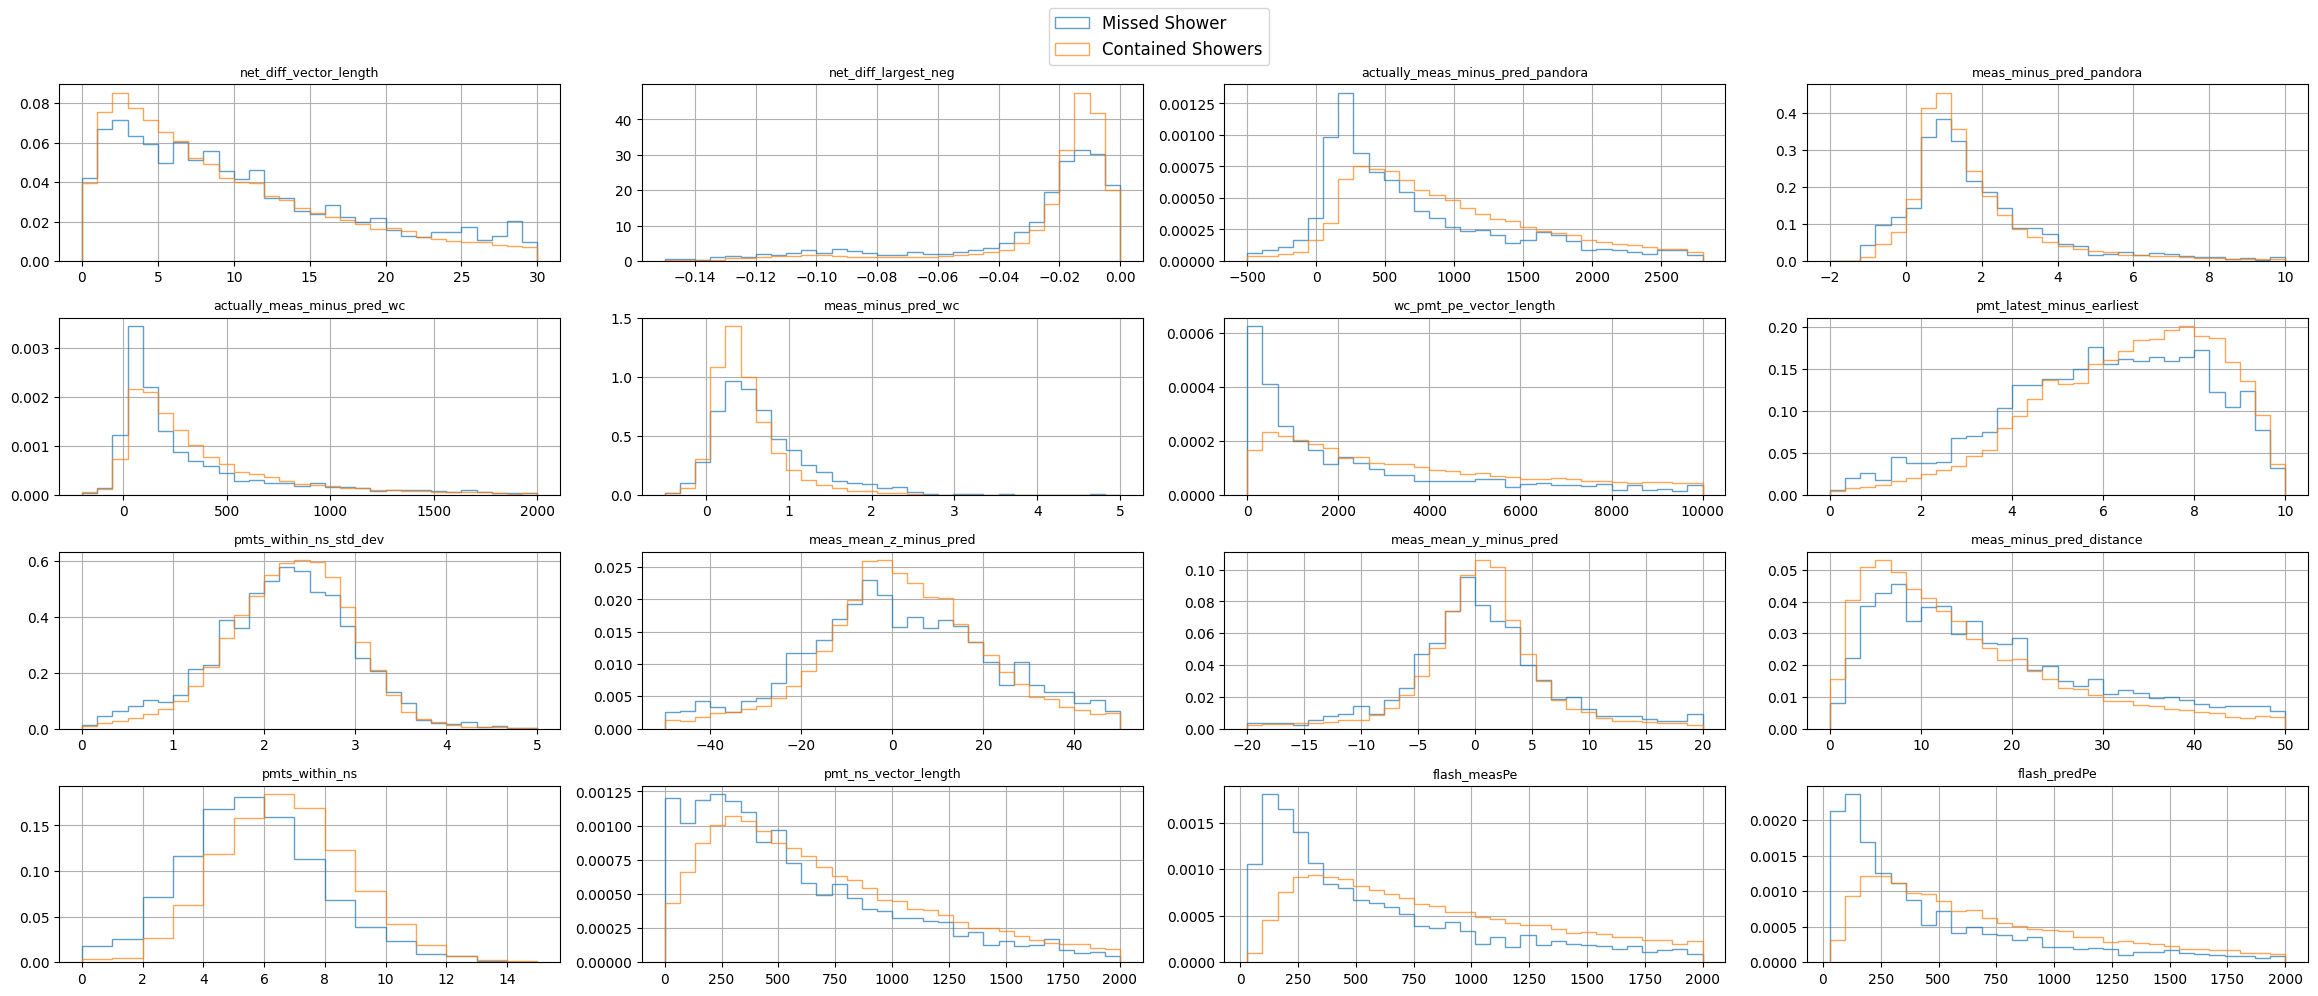

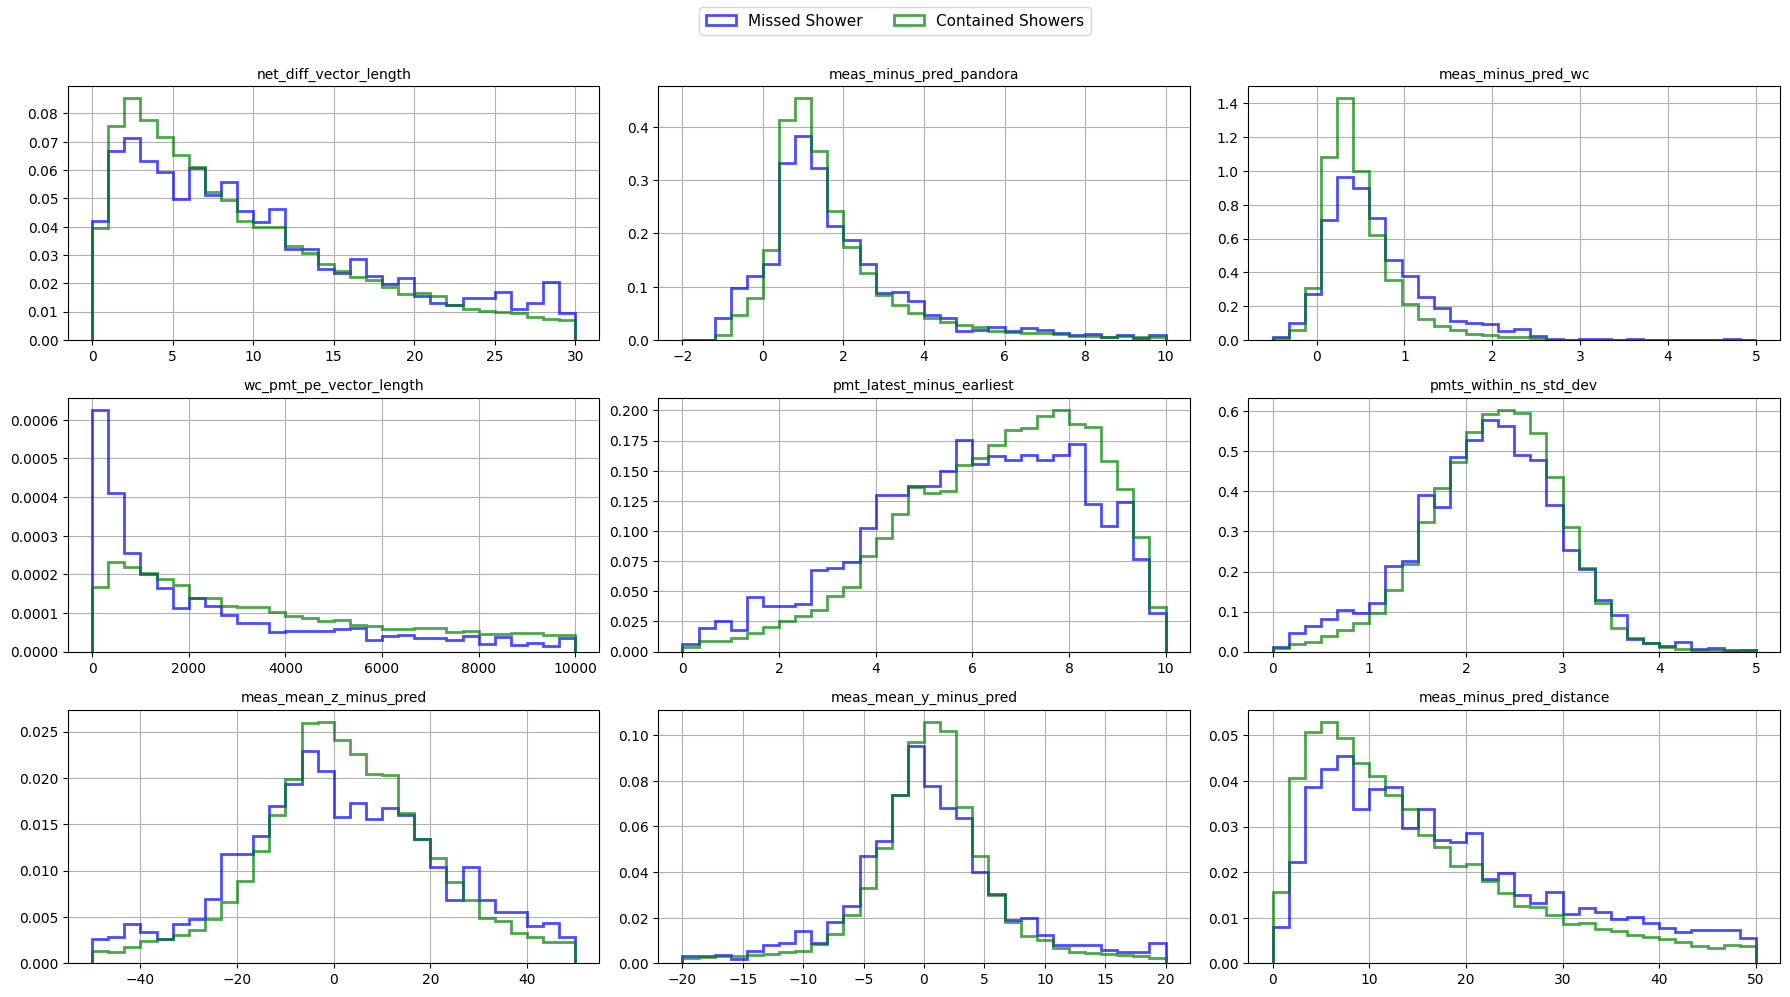

In [158]:
import matplotlib.pyplot as plt
import numpy as np

FC_missed_shw_df = all_df.query("FC_missedshw")
FC_no_missed_shw_pi0_df = all_df.query('no_missed_shw_pi0 and match_isFC')

light_bdt = [
    'net_diff_vector_length', 'net_diff_largest_neg',
    'actually_meas_minus_pred_pandora', 'meas_minus_pred_pandora',
    'actually_meas_minus_pred_wc', 'meas_minus_pred_wc',
    'wc_pmt_pe_vector_length', 'pmt_latest_minus_earliest', 'pmts_within_ns_std_dev',
    'meas_mean_z_minus_pred', 'meas_mean_y_minus_pred', 'meas_minus_pred_distance', 
    'pmts_within_ns', 'pmt_ns_vector_length', 'flash_measPe', 'flash_predPe'
]

# Customize binning per variable: (num_bins, min_val, max_val)
binning_dict = {
    'net_diff_vector_length': (30, 0, 30),
    'net_diff_largest_neg': (30, -.15, 0),
    'actually_meas_minus_pred_pandora': (30, -500, 2800),
    'meas_minus_pred_pandora': (30, -2, 10),
    'actually_meas_minus_pred_wc': (30, -200, 2000),
    'meas_minus_pred_wc': (30, -.5, 5),
    'wc_pmt_pe_vector_length': (30, 0, 10000),
    'pmt_latest_minus_earliest': (30, 0, 10),
    'pmts_within_ns_std_dev': (30, 0, 5),
    'meas_mean_z_minus_pred': (30, -50, 50),
    'meas_mean_y_minus_pred': (30, -20, 20),
    'meas_minus_pred_distance': (30, 0, 50),
    'pmts_within_ns': (15, 0, 15),
    'pmt_ns_vector_length': (30, 0, 2000),
    'flash_measPe': (30, 30, 2000),
    'flash_predPe': (30, 30, 2000),
}

fig, axs = plt.subplots(4, 4, figsize=(24, 10))
axs = axs.flatten()

for i, var in enumerate(light_bdt):
    ax = axs[i]

    bins, vmin, vmax = binning_dict.get(var, (30, None, None))
    
    # Auto-range fallback
    if vmin is None or vmax is None:
        vmin = min(FC_missed_shw_df[var].min(), FC_no_missed_shw_pi0_df[var].min())
        vmax = max(FC_missed_shw_df[var].max(), FC_no_missed_shw_pi0_df[var].max())

    if np.isclose(vmin, vmax):
        vmin -= 1
        vmax += 1

    ax.hist(
        FC_missed_shw_df[var], bins=bins, range=(vmin, vmax),
        alpha=0.7, label='Missed Shower', histtype='step', density=True
    )
    ax.hist(
        FC_no_missed_shw_pi0_df[var], bins=bins, range=(vmin, vmax),
        alpha=0.7, label='Contained Showers', histtype='step', density=True
    )
    
    ax.set_title(var, fontsize=9)
    ax.grid(True)

# Legend and title
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', fontsize=12)
#fig.suptitle('Comparison of Features — Missed vs Contained Showers', fontsize=16)
plt.tight_layout(rect=[0, 0, 0.97, 0.95])
plt.show()

FC_missed_shw_df['meas_mean_z_minus_pred']

import matplotlib.pyplot as plt
import numpy as np

# Filter the data
FC_missed_shw_df = all_df.query("FC_missedshw")
FC_no_missed_shw_pi0_df = all_df.query("no_missed_shw_pi0 and match_isFC")

# Cleaned list of 9 features for 3x3 grid
light_bdt = [
    'net_diff_vector_length',
    'meas_minus_pred_pandora',
    'meas_minus_pred_wc',
    'wc_pmt_pe_vector_length',
    'pmt_latest_minus_earliest',
    'pmts_within_ns_std_dev',
    'meas_mean_z_minus_pred',
    'meas_mean_y_minus_pred',
    'meas_minus_pred_distance'
]

# Keep only binning entries that match the new list
binning_dict = {
    'net_diff_vector_length': (30, 0, 30),
    'meas_minus_pred_pandora': (30, -2, 10),
    'meas_minus_pred_wc': (30, -.5, 5),
    'wc_pmt_pe_vector_length': (30, 0, 10000),
    'pmt_latest_minus_earliest': (30, 0, 10),
    'pmts_within_ns_std_dev': (30, 0, 5),
    'meas_mean_z_minus_pred': (30, -50, 50),
    'meas_mean_y_minus_pred': (30, -20, 20),
    'meas_minus_pred_distance': (30, 0, 50),
}

# Set up 3x3 grid
fig, axs = plt.subplots(3, 3, figsize=(18, 10))
axs = axs.flatten()

for i, var in enumerate(light_bdt):
    ax = axs[i]

    bins, vmin, vmax = binning_dict.get(var, (30, None, None))
    
    # Auto fallback for range
    if vmin is None or vmax is None:
        vmin = min(FC_missed_shw_df[var].min(), FC_no_missed_shw_pi0_df[var].min())
        vmax = max(FC_missed_shw_df[var].max(), FC_no_missed_shw_pi0_df[var].max())

    if np.isclose(vmin, vmax):
        vmin -= 1
        vmax += 1

    ax.hist(
        FC_missed_shw_df[var], bins=bins, range=(vmin, vmax),
        alpha=0.7, label='Missed Shower', histtype='step', density=True, color='blue', linewidth=2
    )
    ax.hist(
        FC_no_missed_shw_pi0_df[var], bins=bins, range=(vmin, vmax),
        alpha=0.7, label='Contained Showers', histtype='step', density=True, color='green', linewidth=2
    )
    
    ax.set_title(var, fontsize=10)
    ax.grid(True)

# Handle legend & layout
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', fontsize=11, ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


(2072, 150)
(25451, 150)
(14793, 150)
(3121, 150)


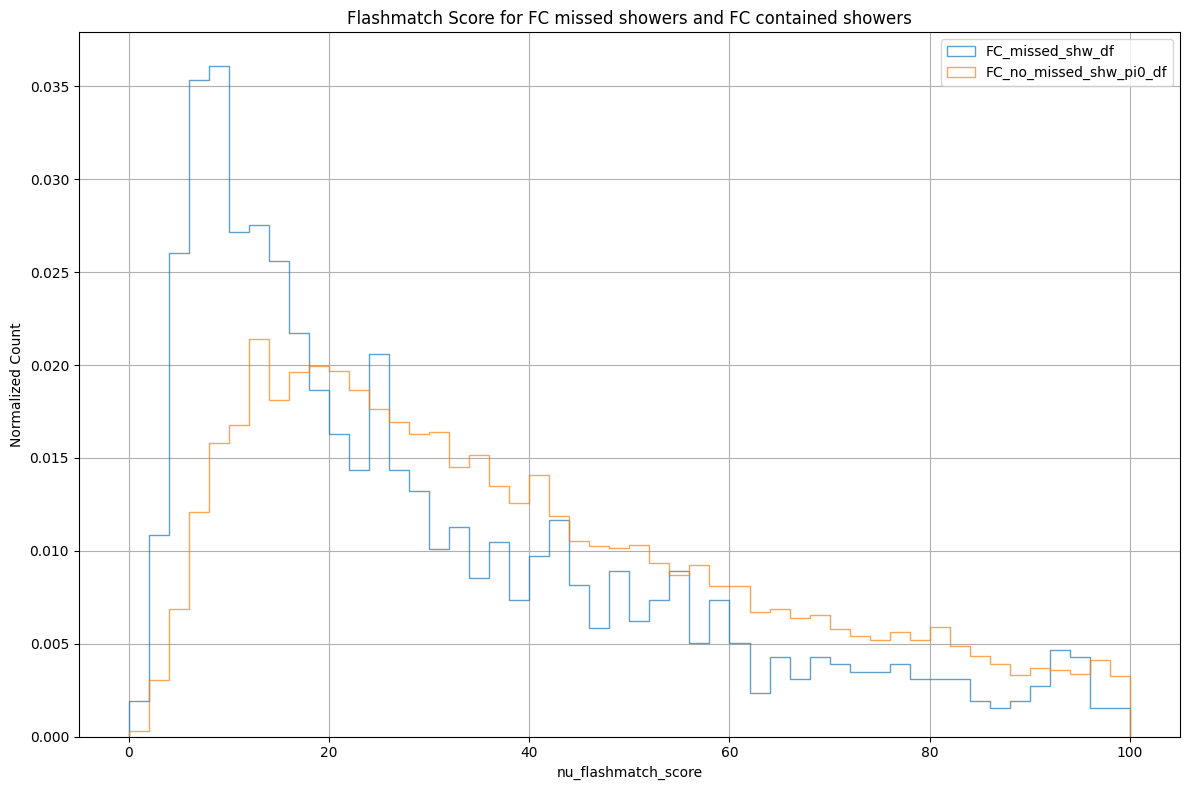

In [16]:
print(all_df.query("FC_missedshw").shape)
print(all_df.query("no_missed_shw_pi0 and match_isFC").shape)

print(all_df.query("net_diff_vector_length > 300").shape)
print(all_df.query("1>net_diff_vector_length <= 10").shape)

FC_missed_shw_df = all_df.query("FC_missedshw")
FC_no_missed_shw_pi0_df = all_df.query('no_missed_shw_pi0 and match_isFC')

pandora_likely_fail_df = all_df.query('net_diff_vector_length > 300')
pandora_good_df = all_df.query('1>net_diff_vector_length <= 10')

plt.figure(figsize=(12, 8))
plt.hist(FC_missed_shw_df['nu_flashmatch_score'], bins=50, alpha=0.7, range=(0, 100), label='FC_missed_shw_df', histtype='step', stacked=True, fill=False, density = True)
plt.hist(FC_no_missed_shw_pi0_df["nu_flashmatch_score"], bins=50, range=(0, 100), alpha=0.7, label='FC_no_missed_shw_pi0_df', histtype='step', stacked=True, fill=False, density = True)

plt.xlabel('nu_flashmatch_score')
plt.ylabel('Normalized Count')
plt.title('Flashmatch Score for FC missed showers and FC contained showers')  # generally signal should be higher
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 8))
plt.hist(FC_missed_shw_df['pmts_within_ns'], bins=15, alpha=0.7, range=(0, 15), label='Missed Shower', histtype='step', stacked=True, fill=False, density = True)
plt.hist(FC_no_missed_shw_pi0_df["pmts_within_ns"], bins=15, range=(0, 15), alpha=0.7, label='Contained Showers', histtype='step', stacked=True, fill=False, density = True)

plt.xlabel('number of pmts (pmts_within_ns)')
plt.ylabel('Normalized Count')
plt.title('Number of PMTS within 5ns of median for Signal and Background')  # generally signal should be higher
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




## ns timing 1d histograms

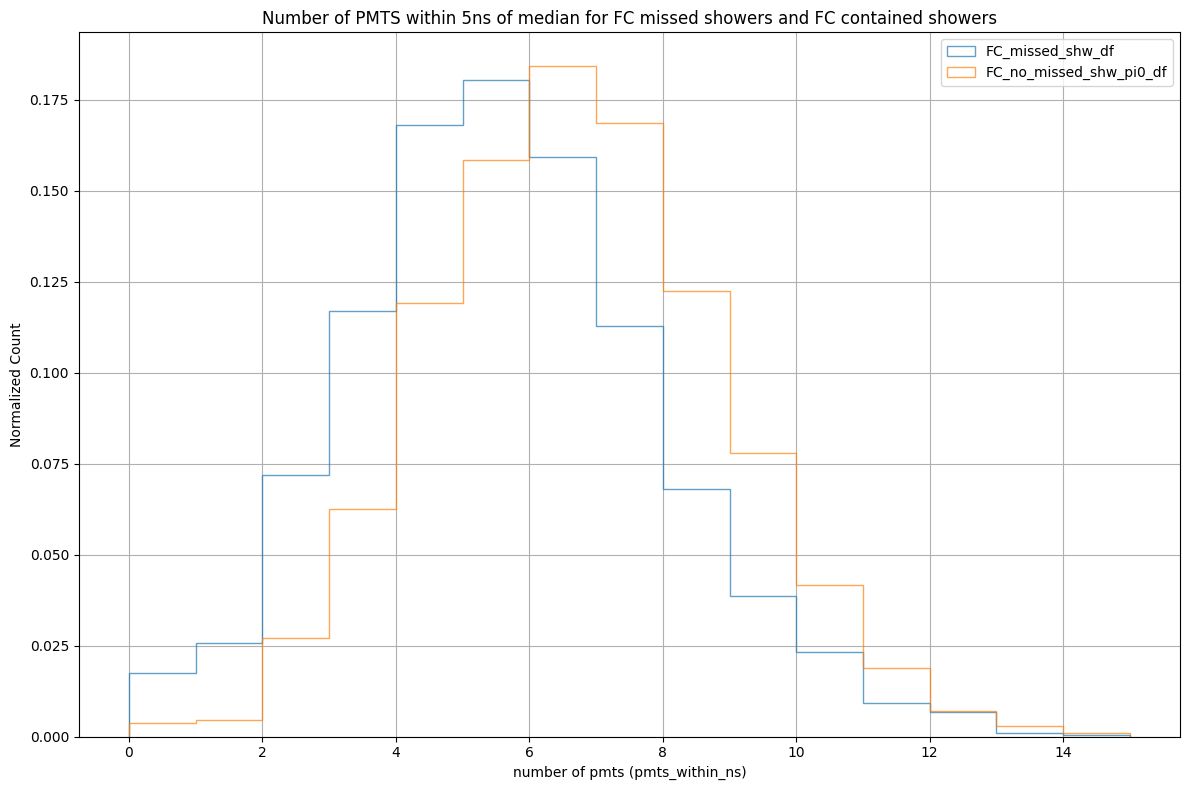

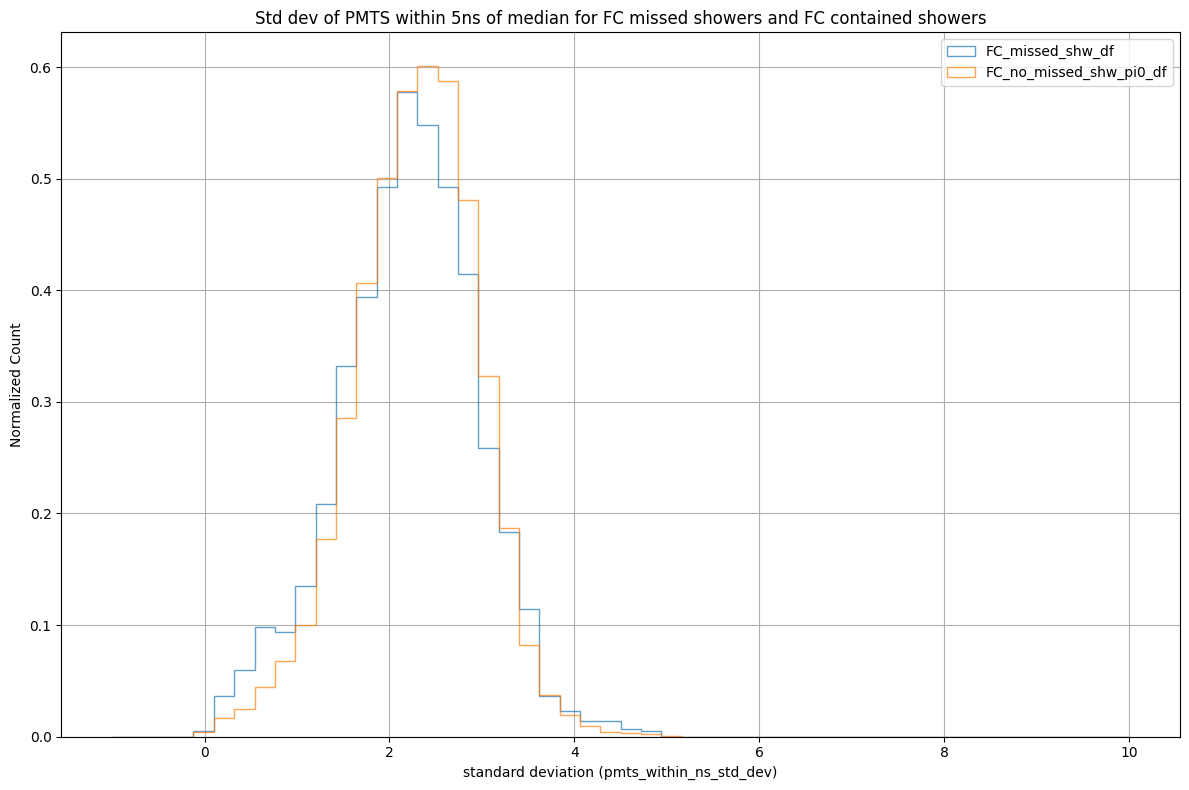

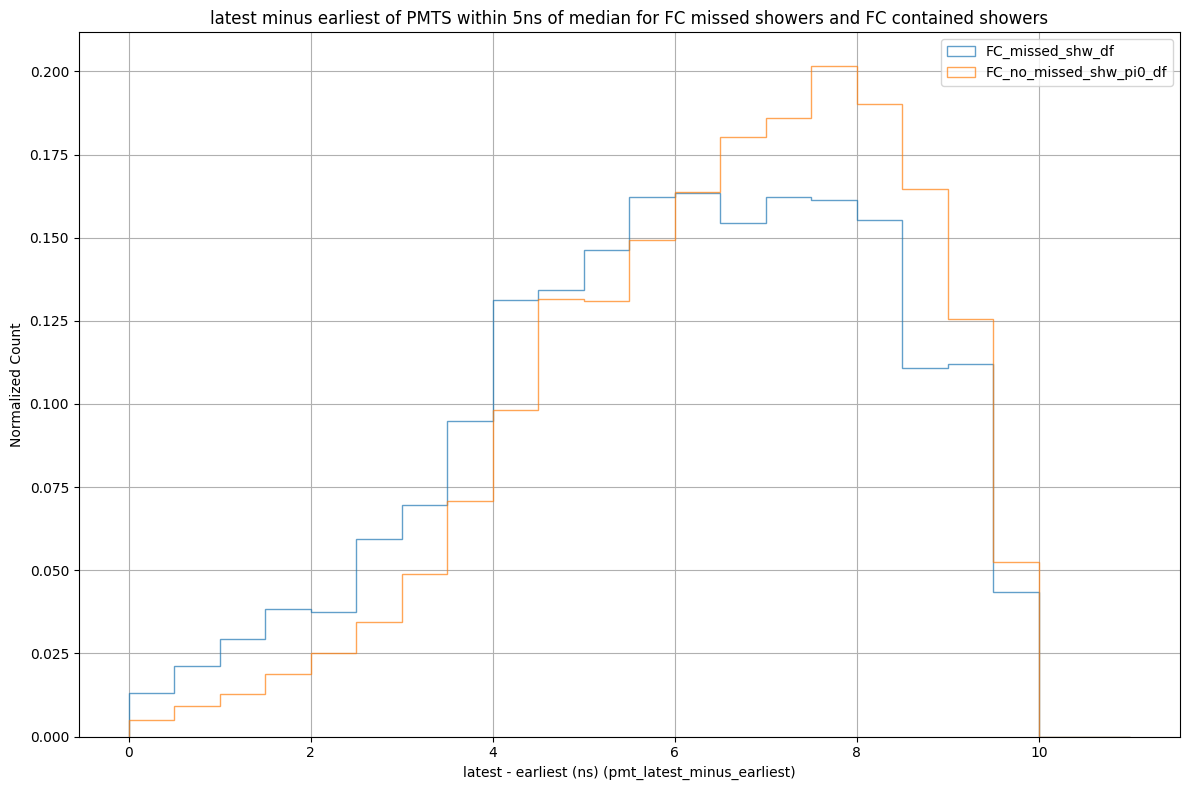

In [17]:

# ns timing 1d histograms


#print(no_missed_shw_pi0_df.shape)

plt.figure(figsize=(12, 8))
plt.hist(FC_missed_shw_df['pmts_within_ns'], bins=15, alpha=0.7, range=(0, 15), label='FC_missed_shw_df', histtype='step', stacked=True, fill=False, density = True)
plt.hist(FC_no_missed_shw_pi0_df["pmts_within_ns"], bins=15, range=(0, 15), alpha=0.7, label='FC_no_missed_shw_pi0_df', histtype='step', stacked=True, fill=False, density = True)

plt.xlabel('number of pmts (pmts_within_ns)')
plt.ylabel('Normalized Count')
plt.title('Number of PMTS within 5ns of median for FC missed showers and FC contained showers')  # generally signal should be higher
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
plt.hist(FC_missed_shw_df['pmts_within_ns_std_dev'], bins=50, alpha=0.7, range=(-1, 10), label='FC_missed_shw_df', histtype='step', stacked=True, fill=False, density = True)
plt.hist(FC_no_missed_shw_pi0_df["pmts_within_ns_std_dev"], bins=50, range=(-1, 10), alpha=0.7, label='FC_no_missed_shw_pi0_df', histtype='step', stacked=True, fill=False, density = True)

plt.xlabel('standard deviation (pmts_within_ns_std_dev)')
plt.ylabel('Normalized Count')
plt.title('Std dev of PMTS within 5ns of median for FC missed showers and FC contained showers')  # generally signal should be higher
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
plt.hist(FC_missed_shw_df['pmt_latest_minus_earliest'], bins=22, alpha=0.7, range=(0, 11), label='FC_missed_shw_df', histtype='step', stacked=True, fill=False, density = True)
plt.hist(FC_no_missed_shw_pi0_df["pmt_latest_minus_earliest"], bins=22, range=(0, 11), alpha=0.7, label='FC_no_missed_shw_pi0_df', histtype='step', stacked=True, fill=False, density = True)

plt.xlabel('latest - earliest (ns) (pmt_latest_minus_earliest)')
plt.ylabel('Normalized Count')
plt.title('latest minus earliest of PMTS within 5ns of median for FC missed showers and FC contained showers')  # generally signal should be higher
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## PE histograms

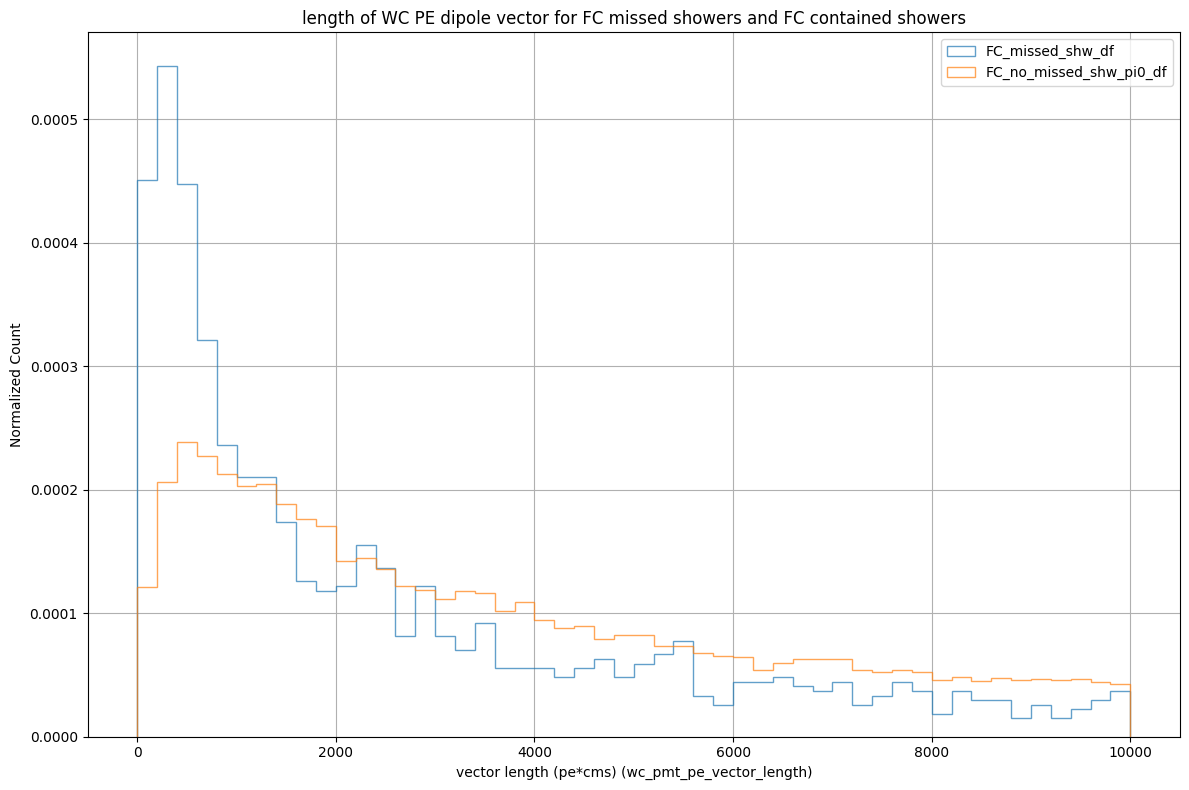

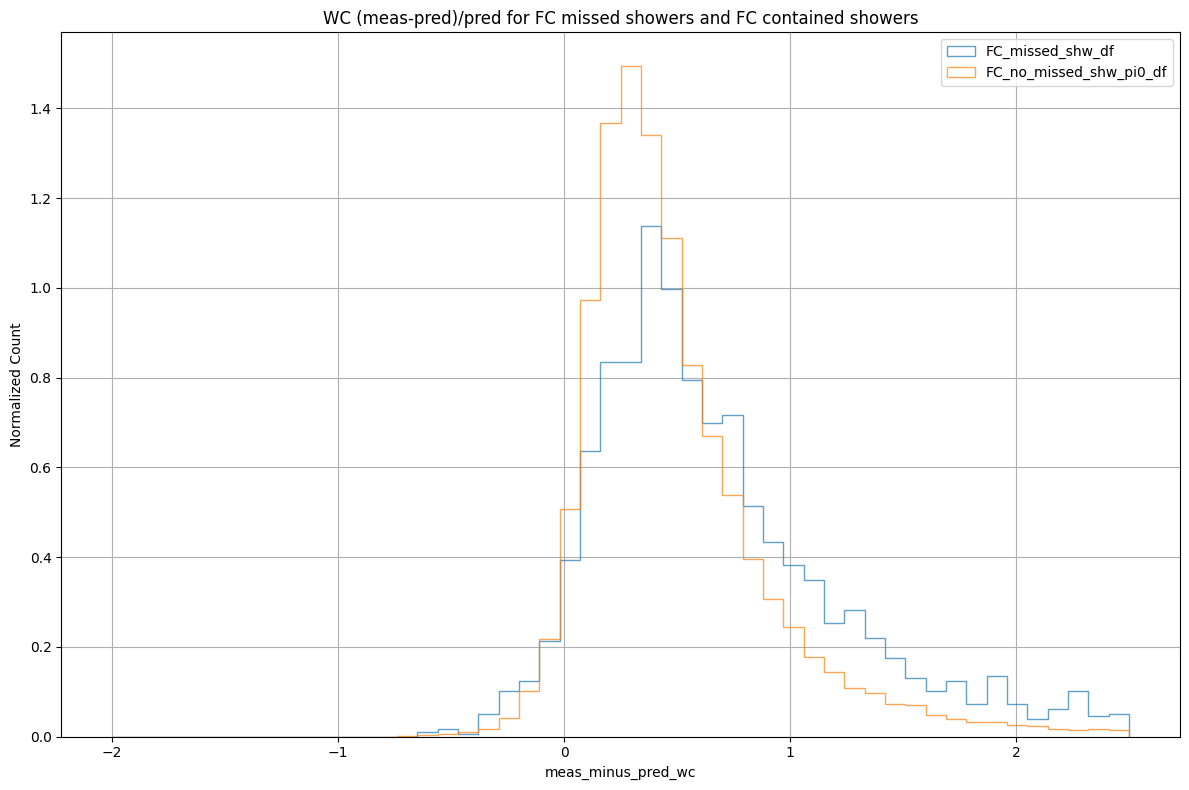

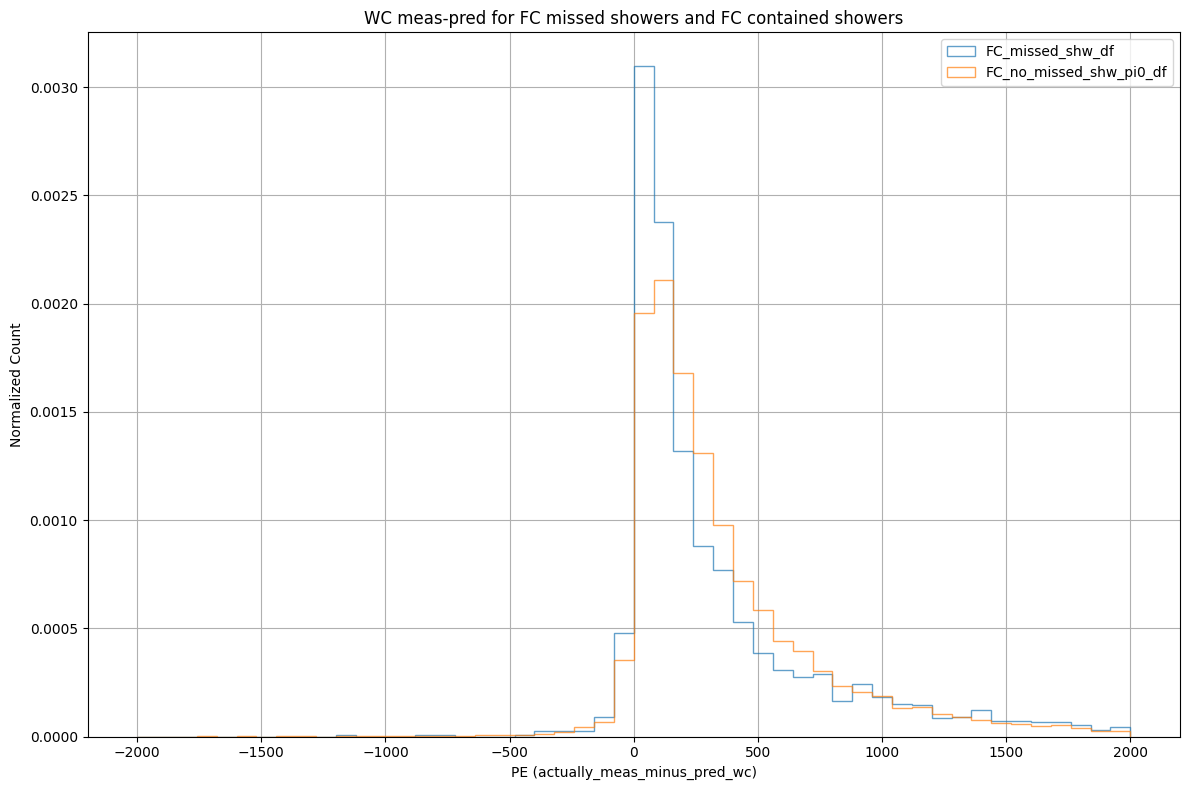

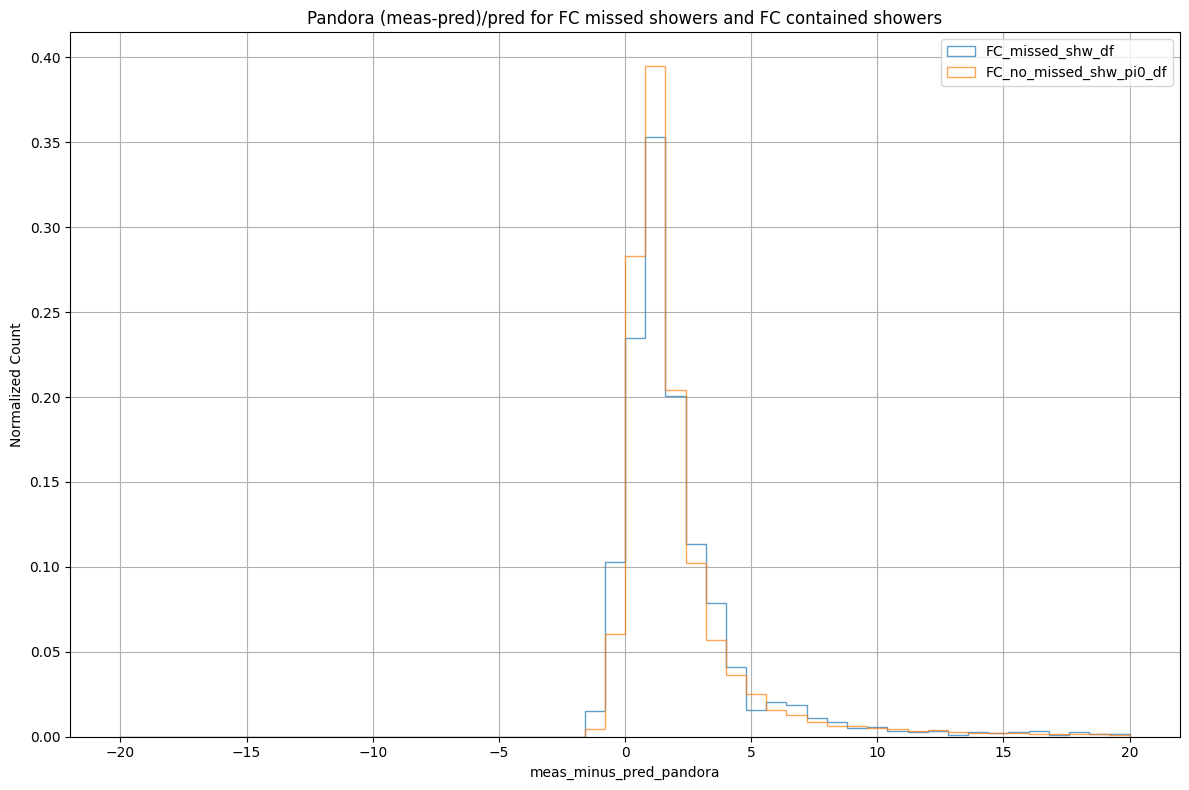

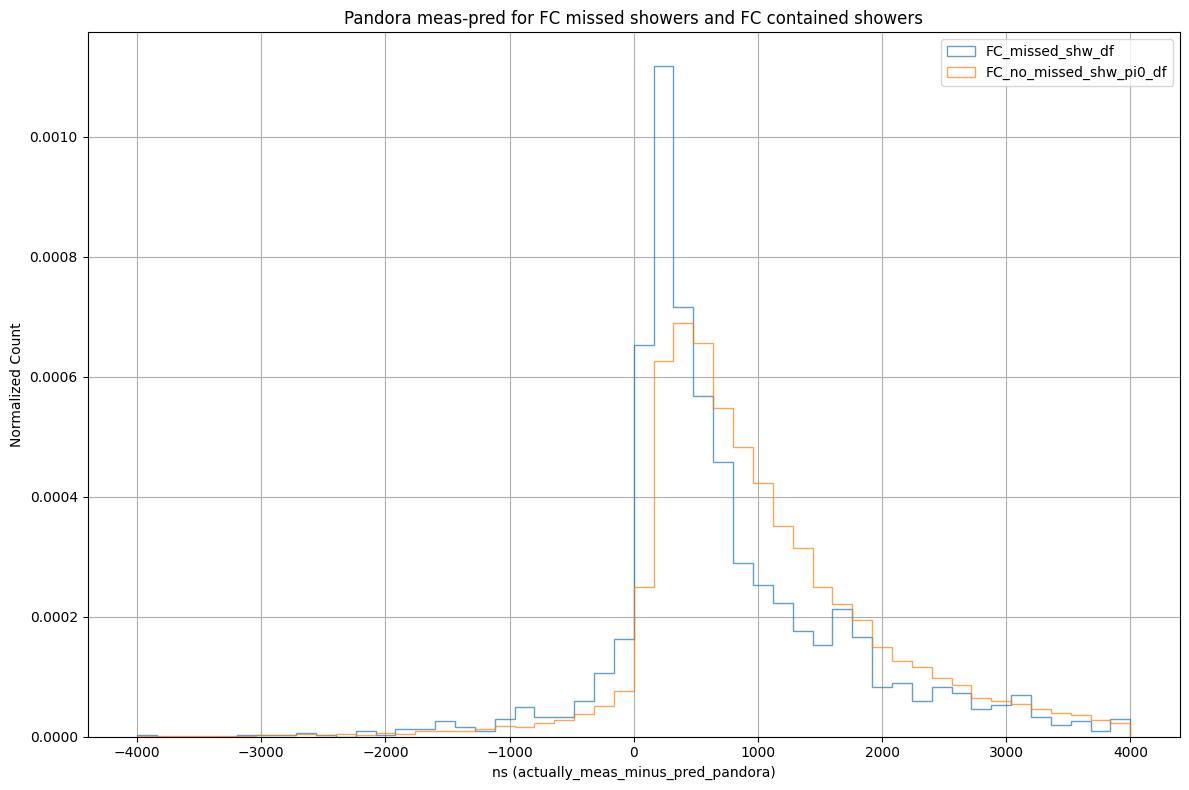

In [93]:
# PE histograms

FC_missed_shw_df_pmt = all_df.query("FC_missedshw and pmt_ns_vector_length > 0")
FC_no_missed_shw_pi0_df_pmt = all_df.query('no_missed_shw_pi0 and match_isFC and pmt_ns_vector_length > 0')
pmt_df = all_df.query('pmt_ns_vector_length > 0 and pi0_flag')

plt.figure(figsize=(12, 8))
plt.hist(FC_missed_shw_df_pmt['wc_pmt_pe_vector_length'], bins=50, alpha=0.7, range=(0, 10000), label='FC_missed_shw_df', histtype='step', stacked=True, fill=False, density = True)
plt.hist(FC_no_missed_shw_pi0_df_pmt["wc_pmt_pe_vector_length"], bins=50, range=(0, 10000), alpha=0.7, label='FC_no_missed_shw_pi0_df', histtype='step', stacked=True, fill=False, density = True)

plt.xlabel('vector length (pe*cms) (wc_pmt_pe_vector_length)')
plt.ylabel('Normalized Count')
plt.title('length of WC PE dipole vector for FC missed showers and FC contained showers')  # generally signal should be higher
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
plt.hist(FC_missed_shw_df_pmt['meas_minus_pred_wc'], bins=50, alpha=0.7, range=(-2, 2.5), label='FC_missed_shw_df', histtype='step', stacked=True, fill=False, density = True)
plt.hist(FC_no_missed_shw_pi0_df_pmt["meas_minus_pred_wc"], bins=50, range=(-2, 2.5), alpha=0.7, label='FC_no_missed_shw_pi0_df', histtype='step', stacked=True, fill=False, density = True)

plt.xlabel('meas_minus_pred_wc')
plt.ylabel('Normalized Count')
plt.title('WC (meas-pred)/pred for FC missed showers and FC contained showers')  # generally signal should be higher
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
plt.hist(FC_missed_shw_df_pmt['actually_meas_minus_pred_wc'], bins=50, alpha=0.7, range=(-2000, 2000), label='FC_missed_shw_df', histtype='step', stacked=True, fill=False, density = True)
plt.hist(FC_no_missed_shw_pi0_df_pmt["actually_meas_minus_pred_wc"], bins=50, range=(-2000, 2000), alpha=0.7, label='FC_no_missed_shw_pi0_df', histtype='step', stacked=True, fill=False, density = True)

plt.xlabel('PE (actually_meas_minus_pred_wc)')
plt.ylabel('Normalized Count')
plt.title('WC meas-pred for FC missed showers and FC contained showers')  # generally signal should be higher
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
plt.hist(FC_missed_shw_df_pmt['meas_minus_pred_pandora'], bins=50, alpha=0.7, range=(-20, 20), label='FC_missed_shw_df', histtype='step', stacked=True, fill=False, density = True)
plt.hist(FC_no_missed_shw_pi0_df_pmt["meas_minus_pred_pandora"], bins=50, range=(-20, 20), alpha=0.7, label='FC_no_missed_shw_pi0_df', histtype='step', stacked=True, fill=False, density = True)

plt.xlabel('meas_minus_pred_pandora')
plt.ylabel('Normalized Count')
plt.title('Pandora (meas-pred)/pred for FC missed showers and FC contained showers')  # generally signal should be higher
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
plt.hist(FC_missed_shw_df_pmt['actually_meas_minus_pred_pandora'], bins=50, alpha=0.7, range=(-4000, 4000), label='FC_missed_shw_df', histtype='step', stacked=True, fill=False, density = True)
plt.hist(FC_no_missed_shw_pi0_df_pmt["actually_meas_minus_pred_pandora"], bins=50, range=(-4000, 4000), alpha=0.7, label='FC_no_missed_shw_pi0_df', histtype='step', stacked=True, fill=False, density = True)

plt.xlabel('ns (actually_meas_minus_pred_pandora)')
plt.ylabel('Normalized Count')
plt.title('Pandora meas-pred for FC missed showers and FC contained showers')  # generally signal should be higher
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()






## Net difference histograms

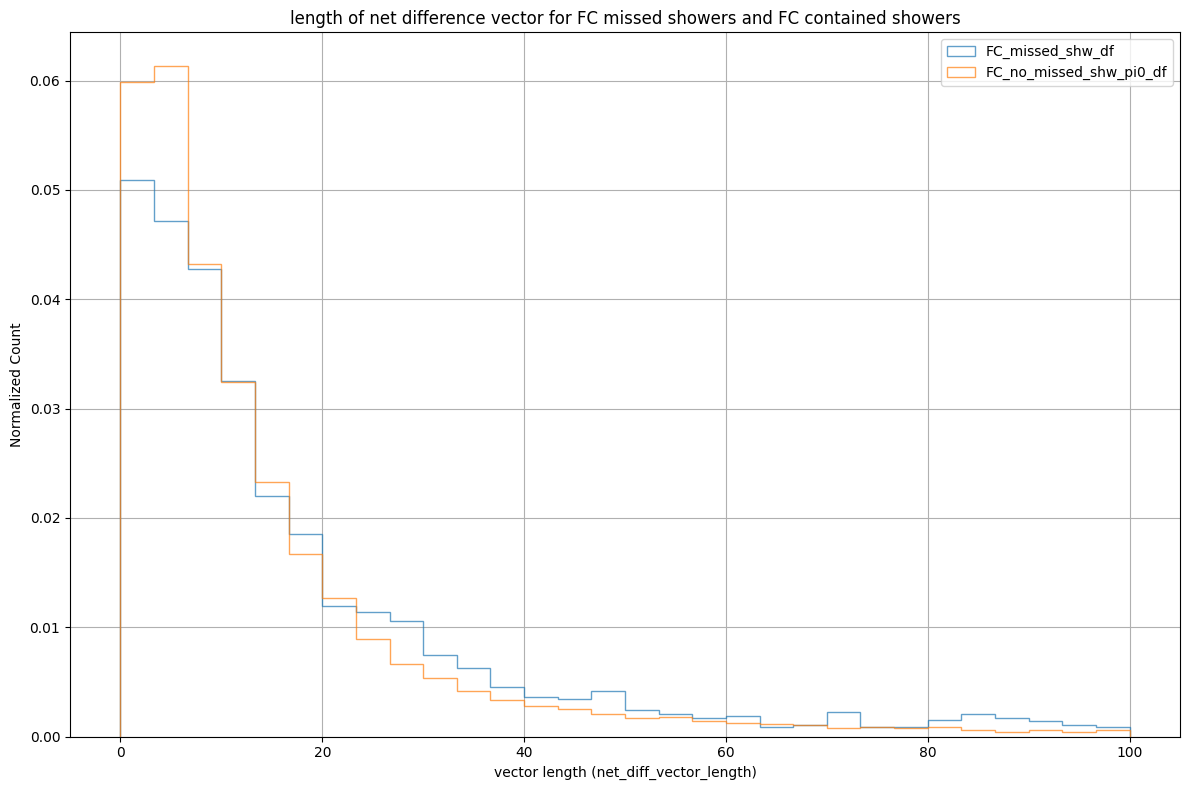

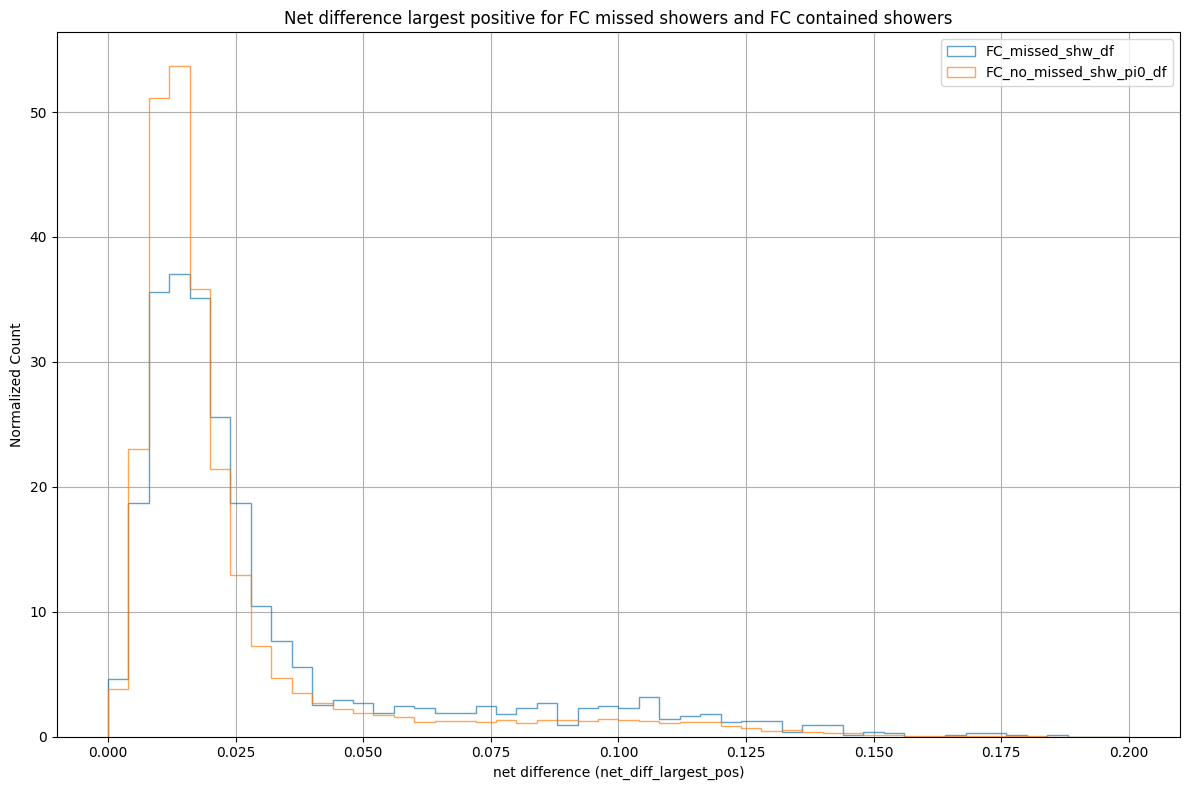

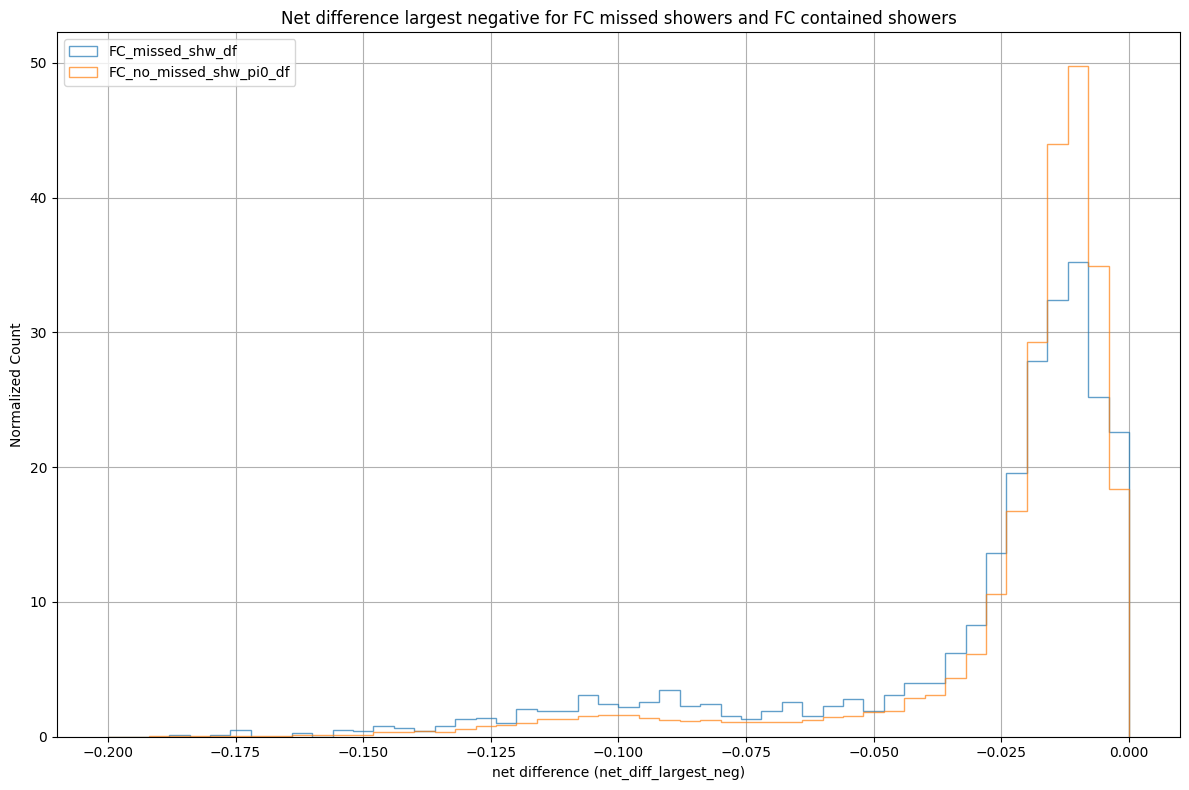

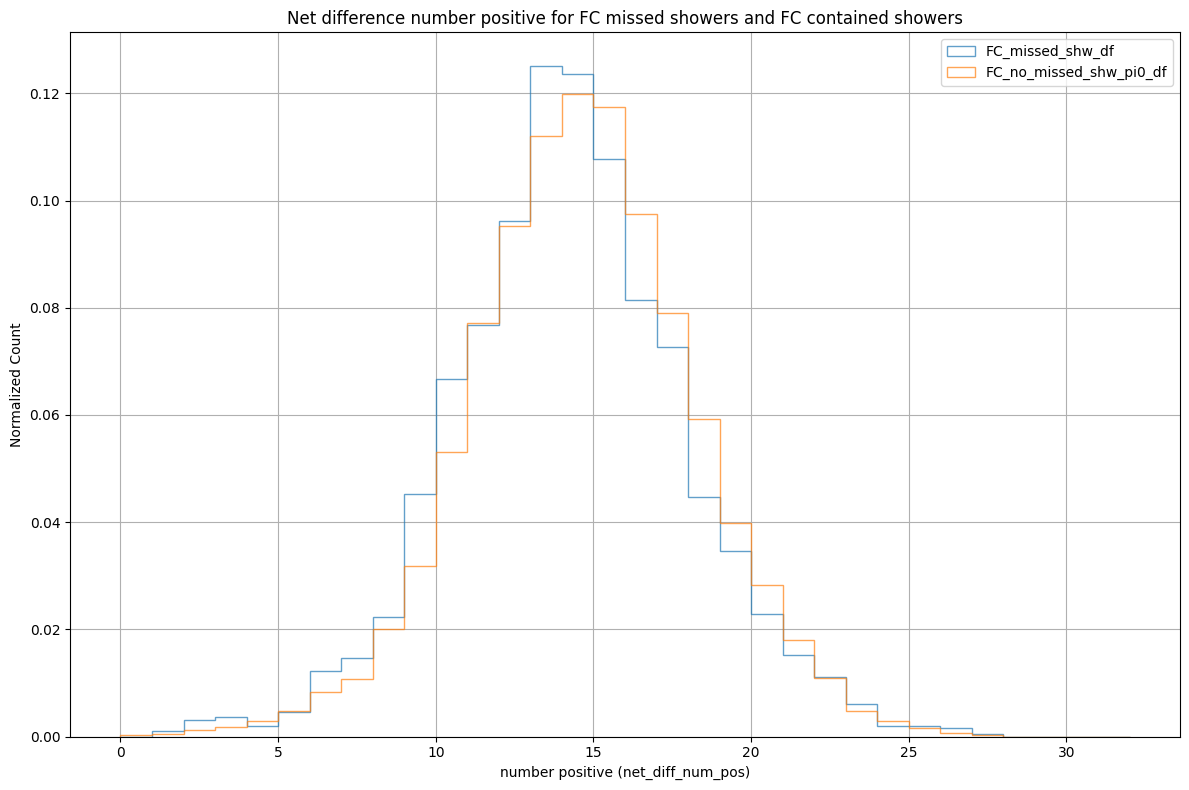

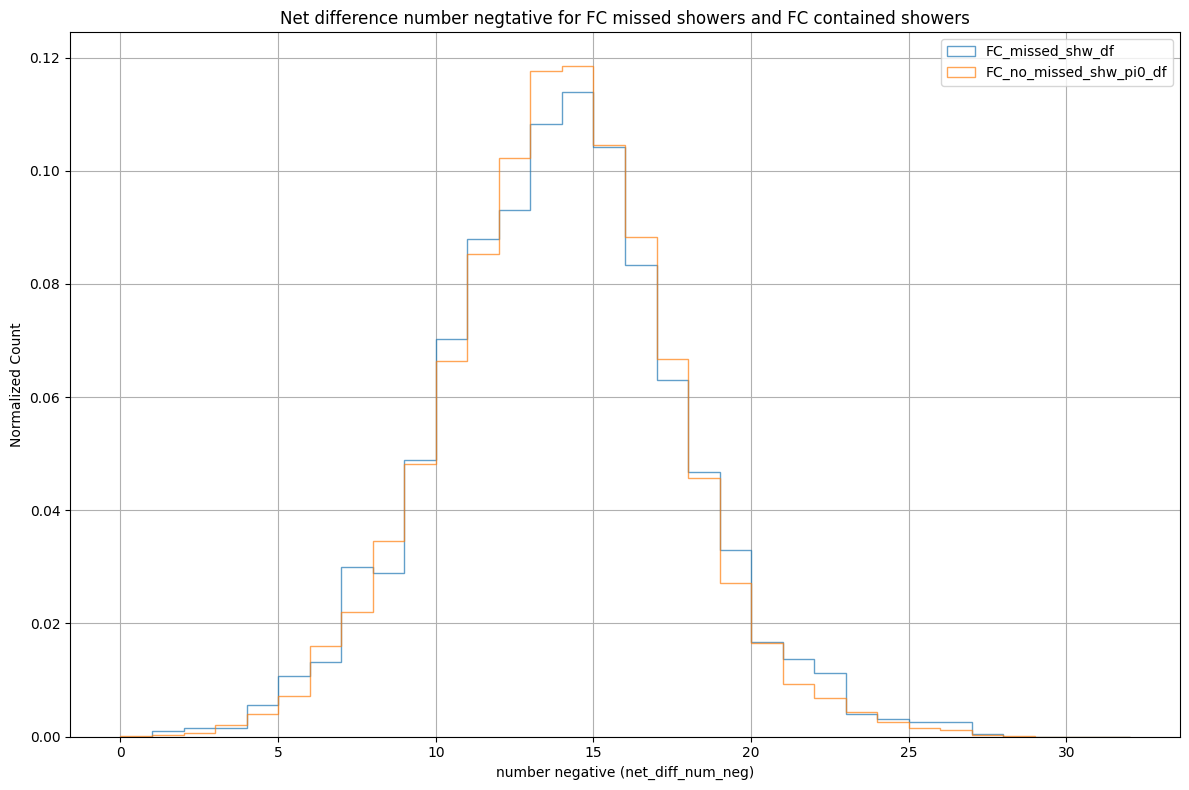

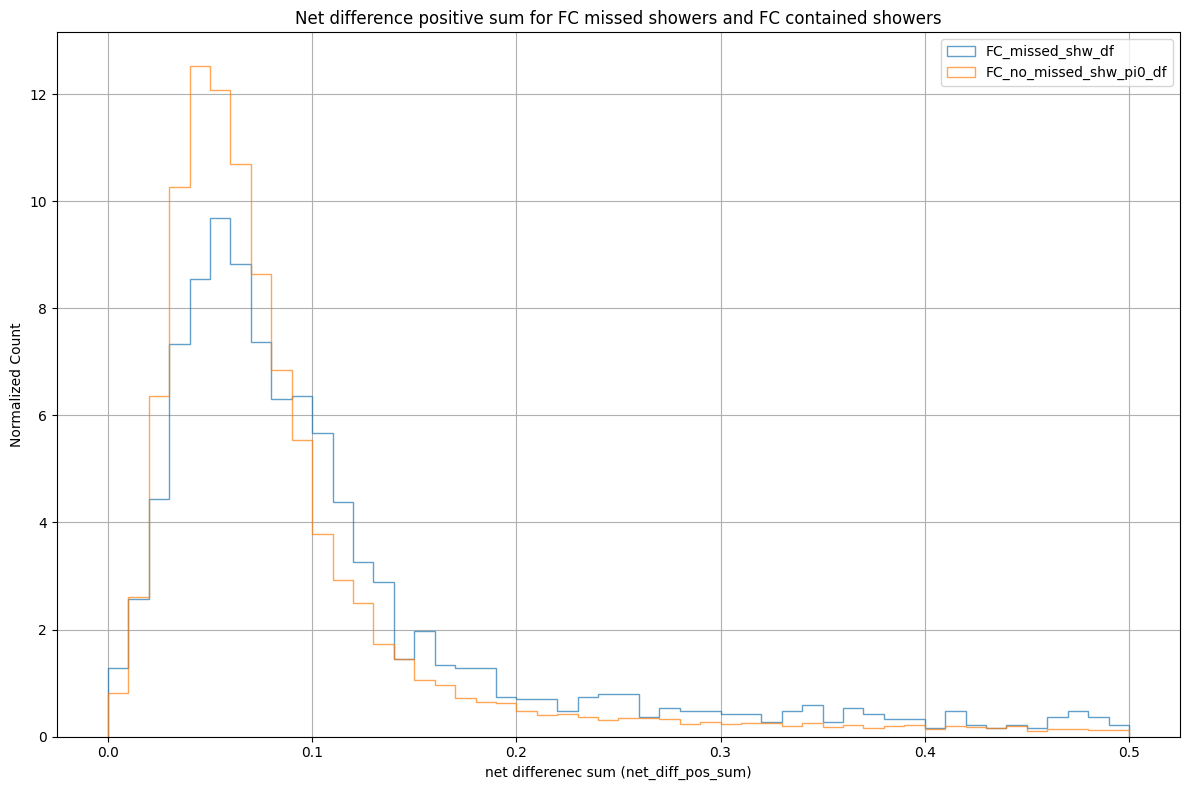

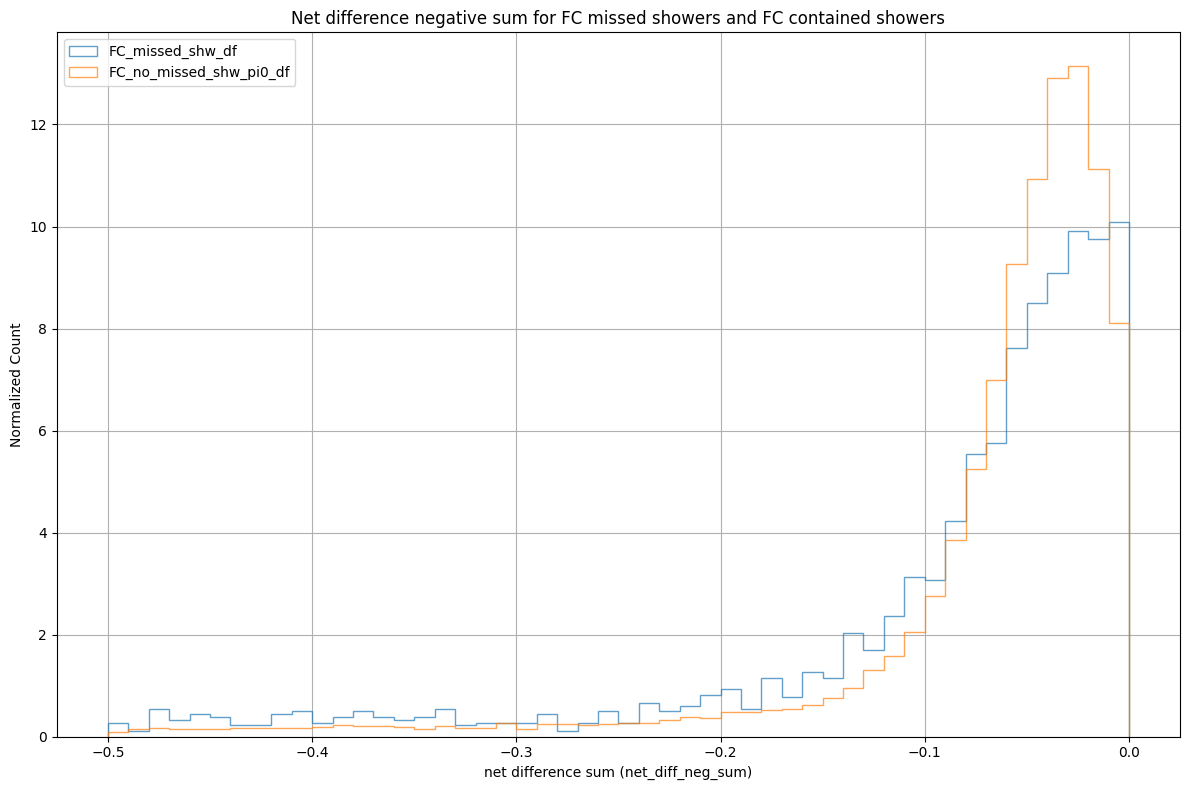

In [19]:
# net difference vector 1d hist

plt.figure(figsize=(12, 8))
plt.hist(FC_missed_shw_df_pmt['net_diff_vector_length'], bins=30, alpha=0.7, range=(0, 100), label='FC_missed_shw_df', histtype='step', stacked=True, fill=False, density = True)
plt.hist(FC_no_missed_shw_pi0_df_pmt["net_diff_vector_length"], bins=30, range=(0, 100), alpha=0.7, label='FC_no_missed_shw_pi0_df', histtype='step', stacked=True, fill=False, density = True)

plt.xlabel('vector length (net_diff_vector_length)')
plt.ylabel('Normalized Count')
plt.title('length of net difference vector for FC missed showers and FC contained showers')  # generally signal should be higher
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
plt.hist(FC_missed_shw_df_pmt['net_diff_largest_pos'], bins=50, alpha=0.7, range=(0, .2), label='FC_missed_shw_df', histtype='step', stacked=True, fill=False, density = True)
plt.hist(FC_no_missed_shw_pi0_df_pmt["net_diff_largest_pos"], bins=50, range=(0, .2), alpha=0.7, label='FC_no_missed_shw_pi0_df', histtype='step', stacked=True, fill=False, density = True)

plt.xlabel('net difference (net_diff_largest_pos)')
plt.ylabel('Normalized Count')
plt.title('Net difference largest positive for FC missed showers and FC contained showers')  # generally signal should be higher
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
plt.hist(FC_missed_shw_df_pmt['net_diff_largest_neg'], bins=50, alpha=0.7, range=(-.2, 0), label='FC_missed_shw_df', histtype='step', stacked=True, fill=False, density = True)
plt.hist(FC_no_missed_shw_pi0_df_pmt["net_diff_largest_neg"], bins=50, range=(-.2, 0), alpha=0.7, label='FC_no_missed_shw_pi0_df', histtype='step', stacked=True, fill=False, density = True)

plt.xlabel('net difference (net_diff_largest_neg)')
plt.ylabel('Normalized Count')
plt.title('Net difference largest negative for FC missed showers and FC contained showers')  # generally signal should be higher
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
plt.hist(FC_missed_shw_df_pmt['net_diff_num_pos'], bins=32, alpha=0.7, range=(0, 32), label='FC_missed_shw_df', histtype='step', stacked=True, fill=False, density = True)
plt.hist(FC_no_missed_shw_pi0_df_pmt["net_diff_num_pos"], bins=32, range=(0, 32), alpha=0.7, label='FC_no_missed_shw_pi0_df', histtype='step', stacked=True, fill=False, density = True)

plt.xlabel('number positive (net_diff_num_pos)')
plt.ylabel('Normalized Count')
plt.title('Net difference number positive for FC missed showers and FC contained showers')  # generally signal should be higher
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
plt.hist(FC_missed_shw_df_pmt['net_diff_num_neg'], bins=32, alpha=0.7, range=(0, 32), label='FC_missed_shw_df', histtype='step', stacked=True, fill=False, density = True)
plt.hist(FC_no_missed_shw_pi0_df_pmt["net_diff_num_neg"], bins=32, range=(0, 32), alpha=0.7, label='FC_no_missed_shw_pi0_df', histtype='step', stacked=True, fill=False, density = True)

plt.xlabel('number negative (net_diff_num_neg)')
plt.ylabel('Normalized Count')
plt.title('Net difference number negtative for FC missed showers and FC contained showers')  # generally signal should be higher
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
plt.hist(FC_missed_shw_df_pmt['net_diff_pos_sum'], bins=50, alpha=0.7, range=(0, .5), label='FC_missed_shw_df', histtype='step', stacked=True, fill=False, density = True)
plt.hist(FC_no_missed_shw_pi0_df_pmt["net_diff_pos_sum"], bins=50, range=(0, .5), alpha=0.7, label='FC_no_missed_shw_pi0_df', histtype='step', stacked=True, fill=False, density = True)

plt.xlabel('net differenec sum (net_diff_pos_sum)')
plt.ylabel('Normalized Count')
plt.title('Net difference positive sum for FC missed showers and FC contained showers')  # generally signal should be higher
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
plt.hist(FC_missed_shw_df_pmt['net_diff_neg_sum'], bins=50, alpha=0.7, range=(-.5, 0), label='FC_missed_shw_df', histtype='step', stacked=True, fill=False, density = True)
plt.hist(FC_no_missed_shw_pi0_df_pmt["net_diff_neg_sum"], bins=50, range=(-.5, 0), alpha=0.7, label='FC_no_missed_shw_pi0_df', histtype='step', stacked=True, fill=False, density = True)

plt.xlabel('net difference sum (net_diff_neg_sum)')
plt.ylabel('Normalized Count')
plt.title('Net difference negative sum for FC missed showers and FC contained showers')  # generally signal should be higher
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 2D kine_reco_enu and reco vertex x correlations

# Train BDT

/var/folders/_s/7j_881g14zd1rn9kv4_hn7nw0000gn/T/ipykernel_11520/2208399218.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  FC_missed_shw_df['binary_flag'] = 1
/var/folders/_s/7j_881g14zd1rn9kv4_hn7nw0000gn/T/ipykernel_11520/2208399218.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  FC_no_missed_shw_pi0_df['binary_flag'] = 0
/Users/katherinepulido/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [13:48:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 


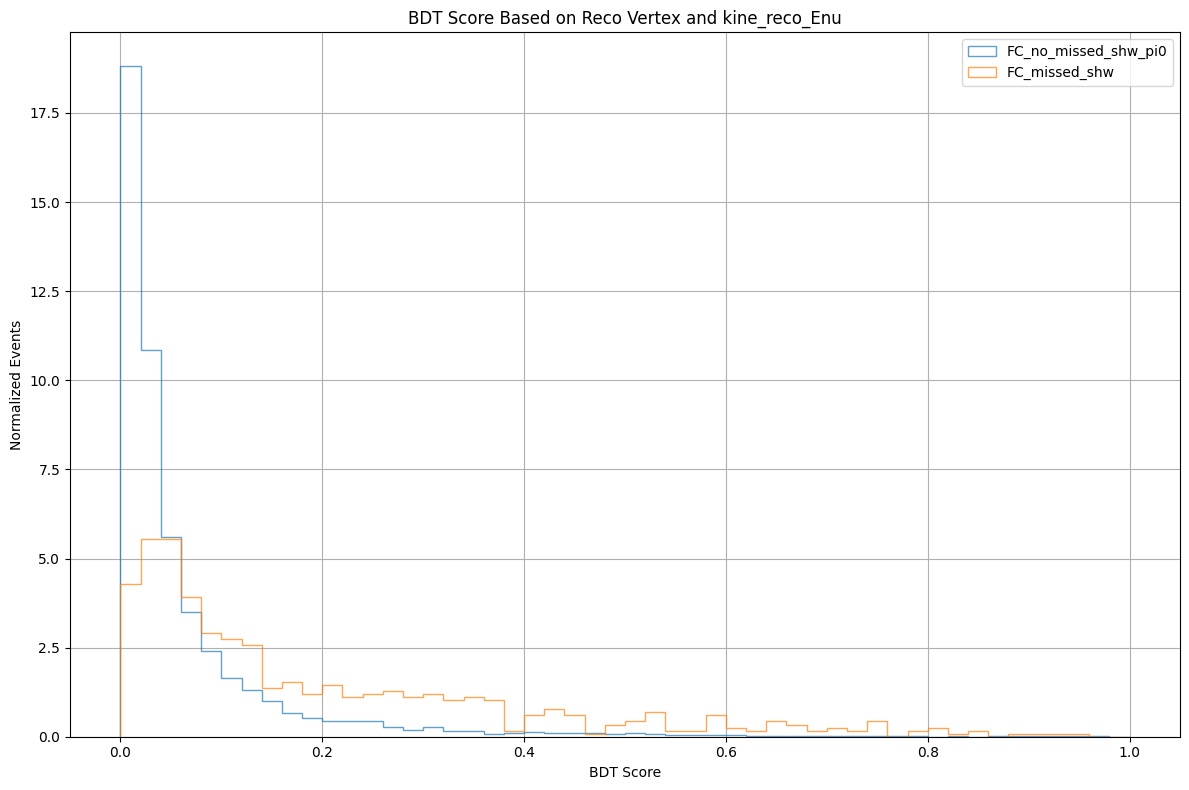

Accuracy: 0.9257599612450043
ROC AUC: 0.7771780834737039

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.99      0.96      7672
           1       0.41      0.11      0.17       585

    accuracy                           0.93      8257
   macro avg       0.67      0.55      0.56      8257
weighted avg       0.90      0.93      0.90      8257



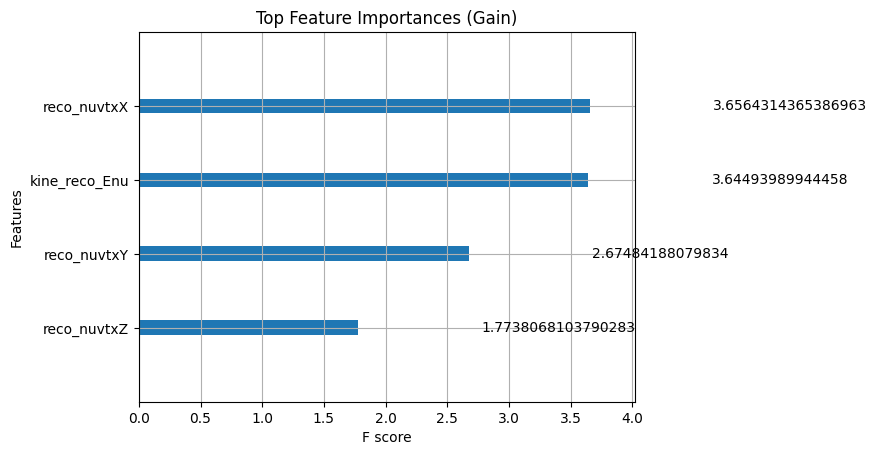

In [20]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

FC_missed_shw_df = all_df.query("FC_missedshw")
FC_no_missed_shw_pi0_df = all_df.query('no_missed_shw_pi0 and match_isFC')

FC_missed_shw_df['binary_flag'] = 1
FC_no_missed_shw_pi0_df['binary_flag'] = 0

bdt_df = pd.concat([FC_missed_shw_df, FC_no_missed_shw_pi0_df], ignore_index=True)

feature_cols = [
    'kine_reco_Enu', 'reco_nuvtxX', 'reco_nuvtxY', 'reco_nuvtxZ']

X_train, X_test, y_train, y_test = train_test_split(
    bdt_df[feature_cols], bdt_df['binary_flag'], test_size=0.3, random_state=42
)

model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=3,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

target_names = ["FC_no_missed_shw_pi0", "FC_missed_shw"]

# Score arrays for each true label
scores_0 = y_proba[np.array(y_test) == 0]
scores_1 = y_proba[np.array(y_test) == 1]

plt.figure(figsize=(12, 8))
plt.hist(scores_0, bins=50, alpha=0.7, range=(0,1),label='FC_no_missed_shw_pi0', histtype='step', stacked=True, fill=False, density = True)
plt.hist(scores_1, bins=50, alpha=0.7, range=(0,1),label='FC_missed_shw', histtype='step', stacked=True, fill=False, density = True)

#plt.hist(scores_0, bins=50, label='FC_no_missed_shw_pi0', fill=False, density=True)
#plt.hist(scores_1, bins=50, label='FC_missed_shw', fill=False, density=True) 
plt.title("BDT Score Based on Reco Vertex and kine_reco_Enu")
plt.xlabel("BDT Score")
plt.ylabel("Normalized Events")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

xgb.plot_importance(model, importance_type='gain', max_num_features=10)
plt.title("Top Feature Importances (Gain)")
plt.show()



Accuracy: 0.9292721327358605
ROC AUC: 0.7217258005579174
                      precision    recall  f1-score   support

FC_no_missed_shw_pi0       0.93      1.00      0.96      7672
       FC_missed_shw       0.51      0.05      0.08       585

            accuracy                           0.93      8257
           macro avg       0.72      0.52      0.52      8257
        weighted avg       0.90      0.93      0.90      8257



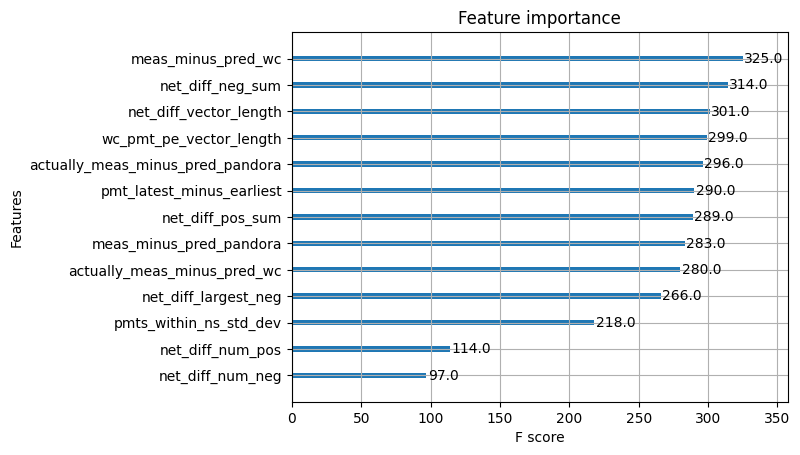

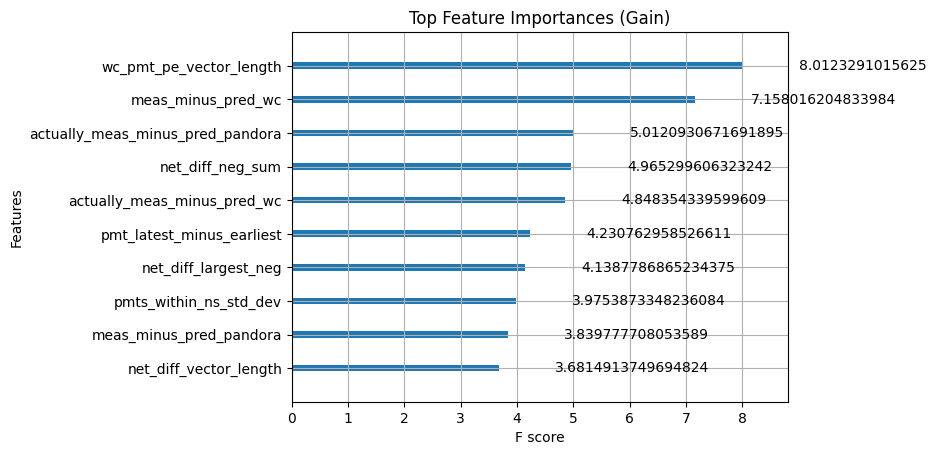

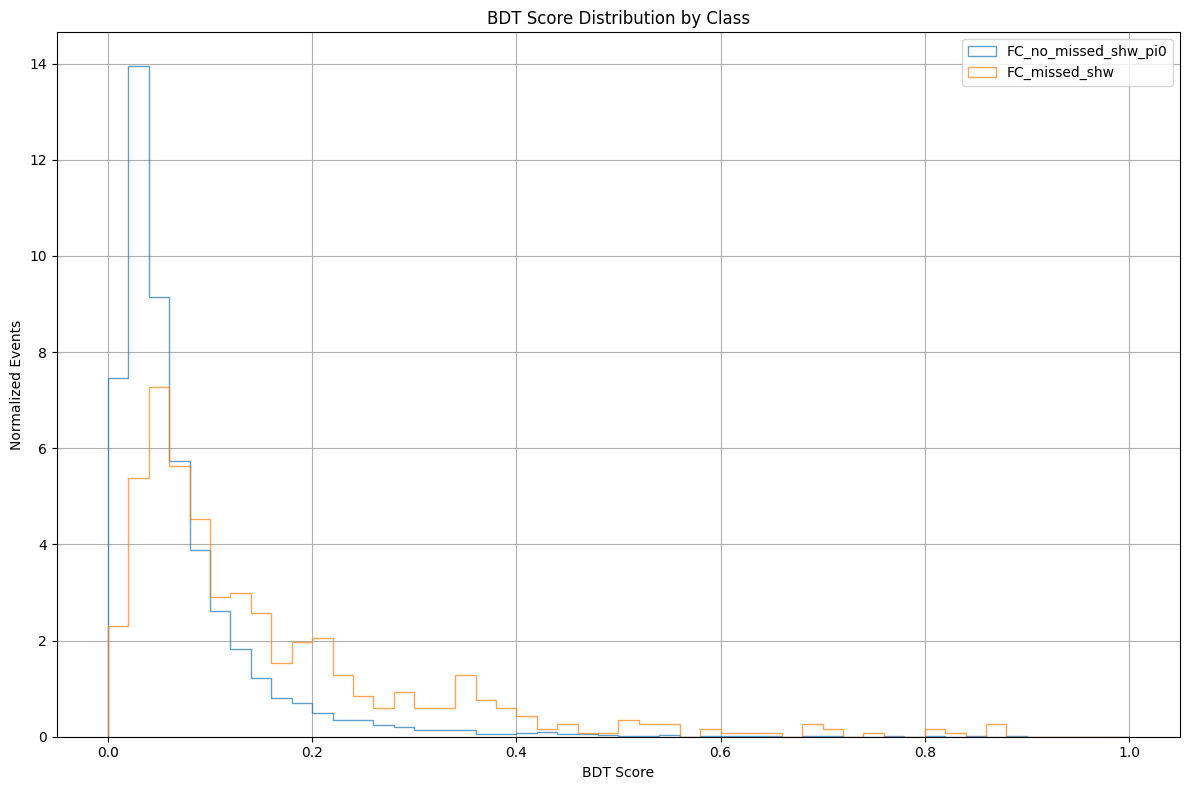

In [21]:
from sklearn import metrics

FC_missed_shw_df = all_df.query("FC_missedshw").copy()
FC_no_missed_shw_pi0_df = all_df.query('no_missed_shw_pi0 and match_isFC').copy()

FC_missed_shw_df['binary_flag'] = 1
FC_no_missed_shw_pi0_df['binary_flag'] = 0

bdt_df = pd.concat([FC_missed_shw_df, FC_no_missed_shw_pi0_df], ignore_index=True)

feature_cols = [
    'net_diff_neg_sum', 'net_diff_pos_sum', 'net_diff_num_pos', 'net_diff_num_neg',
    'net_diff_vector_length', 'net_diff_largest_neg',
    'actually_meas_minus_pred_pandora', 'meas_minus_pred_pandora',
    'actually_meas_minus_pred_wc', 'meas_minus_pred_wc',
    'wc_pmt_pe_vector_length', 'pmt_latest_minus_earliest', 'pmts_within_ns_std_dev'
]

X_train, X_test, y_train, y_test = train_test_split(
    bdt_df[feature_cols], bdt_df['binary_flag'], test_size=0.3, random_state=42
)

model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.1,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
#print("\nClassification Report:\n", classification_report(y_test, y_pred))

target_names = ["FC_no_missed_shw_pi0", "FC_missed_shw"]

print(metrics.classification_report(y_test, y_pred, target_names=target_names))

xgb.plot_importance(model)

xgb.plot_importance(model, importance_type='gain', max_num_features=10)
plt.title("Top Feature Importances (Gain)")
plt.show()

# Score arrays for each true label
scores_0 = y_proba[np.array(y_test) == 0]
scores_1 = y_proba[np.array(y_test) == 1]

plt.figure(figsize=(12, 8))
plt.hist(scores_0, bins=50, alpha=0.7, range=(0,1),label='FC_no_missed_shw_pi0', histtype='step', stacked=True, fill=False, density = True)
plt.hist(scores_1, bins=50, alpha=0.7, range=(0,1),label='FC_missed_shw', histtype='step', stacked=True, fill=False, density = True)

#plt.hist(scores_0, bins=50, label='FC_no_missed_shw_pi0', fill=False, density=True)
#plt.hist(scores_1, bins=50, label='FC_missed_shw', fill=False, density=True) 
plt.title("BDT Score Distribution by Class")
plt.xlabel("BDT Score")
plt.ylabel("Normalized Events")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# calculate efficiency and purity at every point:

In [ ]:

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe
from hyperopt.pyll.base import scope
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score, f1_score

def optimize_bdt_with_hyperopt(X_train, y_train, max_evals=100):
    space = {
        'max_depth': scope.int(hp.quniform('max_depth', 2, 10, 1)),
        'gamma': hp.uniform('gamma', 1, 9),
        'reg_alpha': scope.int(hp.quniform('reg_alpha', 40, 180, 1)),
        'reg_lambda': hp.uniform('reg_lambda', 0, 1),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1),
        'min_child_weight': scope.int(hp.quniform('min_child_weight', 0, 10, 1)), 
        'learning_rate': hp.uniform('learning_rate', 0.01, 0.1),
        'n_estimators': scope.int(hp.quniform('n_estimators', 100, 1000, 50)),
        'seed': 0
    }
    
    X_train_inner, X_val, y_train_inner, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

    def objective(space):
        
        clf = xgb.XGBClassifier(
            n_estimators=space['n_estimators'],
            max_depth=space['max_depth'],
            learning_rate=space['learning_rate'],
            gamma=space['gamma'],
            reg_alpha=space['reg_alpha'],
            reg_lambda=space['reg_lambda'],
            random_state=space['seed'],
            colsample_bytree=space['colsample_bytree'],
            min_child_weight=space['min_child_weight'],
            eval_metric='logloss',
            early_stopping_rounds=10,
            scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1])
        )
        
        evaluation = [(X_train_inner, y_train_inner), (X_val, y_val)]
    
        clf.fit(X_train_inner, y_train_inner,
            eval_set=evaluation, verbose=False)
    
        # Score on the validation set (or keep using test set, but don't use it in eval_set)
        
        pred_proba = clf.predict_proba(X_val)[:, 1]
        y_pred = (pred_proba > 0.5).astype(int)
        
        # Calculate per-class metrics
        from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
        
        precision, recall, f1, support = precision_recall_fscore_support(y_val, y_pred, average=None)
        tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
        
        class_0_acc = tn / (tn + fp)  # Specificity (correct negative rate)
        class_1_acc = tp / (tp + fn)  # Sensitivity (correct positive rate)
        
        balanced_acc = balanced_accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred)
        #print(f"Balanced accuracy: {balanced_acc:.4f}")
        return {'loss': -balanced_acc, 'status': STATUS_OK}

    trials = Trials()
    best_hyperparams = fmin(
        fn=objective,
        space=space,
        algo=tpe.suggest,
        max_evals=max_evals,
        trials=trials,
        rstate=np.random.default_rng(42)
    )
    return best_hyperparams, trials

def train_bdt_on_missed_shower(all_df, feature_cols, vars_name, test_size=0.3, random_state=42):
    # Prepare the data
    FC_missed_shw_df = all_df.query("FC_missedshw").copy()
    FC_no_missed_shw_pi0_df = all_df.query("no_missed_shw_pi0 and match_isFC").copy()
    
    FC_missed_shw_df["binary_flag"] = 1
    FC_no_missed_shw_pi0_df["binary_flag"] = 0
    
    bdt_df = pd.concat([FC_missed_shw_df, FC_no_missed_shw_pi0_df], ignore_index=True)
    
    X_train, X_test, y_train, y_test = train_test_split(
        bdt_df[feature_cols], bdt_df["binary_flag"], test_size=test_size, random_state=random_state
    )
    
    best_params, trials = optimize_bdt_with_hyperopt(X_train, y_train)
    print("Best hyperparameters:", best_params)
    
    # Convert y to numpy arrays (just to be sure)
    y_train = y_train.values if hasattr(y_train, 'values') else y_train
    y_test = y_test.values if hasattr(y_test, 'values') else y_test
    
    # Use the optimized hyperparameters instead of hardcoded values
    model = xgb.XGBClassifier(
        n_estimators=int(best_params['n_estimators']),
        max_depth=int(best_params['max_depth']),
        gamma=best_params['gamma'],
        reg_alpha=int(best_params['reg_alpha']),
        reg_lambda=best_params['reg_lambda'],
        colsample_bytree=best_params['colsample_bytree'],
        min_child_weight=int(best_params['min_child_weight']),
        random_state=0,
        learning_rate=best_params['learning_rate'],  # You can add this to hyperopt space if desired
        early_stopping_rounds=10,
        eval_metric='logloss',
        # Add class balancing to help with the imbalanced dataset
        scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1])
    )
    
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=False
    )
    
    evals_result = model.evals_result()

    xgb.plot_importance(model)
    
    # Predict and evaluate
    y_pred = model.predict(X_test)
    plot_confusion_matrix(y_test, y_pred, labels=["FC_no_missed_shw_pi0", "FC_missed_shw"], normalize=True)

    y_proba = model.predict_proba(X_test)[:, 1]
    
    scores_0 = y_proba[np.array(y_test) == 0]
    scores_1 = y_proba[np.array(y_test) == 1]
    

    
    
    #print("Accuracy:", accuracy_score(y_test, y_pred))
    #print("ROC AUC:", roc_auc_score(y_test, y_proba))
    #target_names = ["FC_no_missed_shw_pi0", "FC_missed_shw"]
    #print("\nClassification Report:\n")
    #print(classification_report(y_test, y_pred, target_names=target_names))
    
    plot_log_loss(evals_result, vars_name)
    
    return model, y_proba, y_test


def plot_log_loss(evals_result, vars_name):
    # Check keys
    print("Eval results keys:", evals_result.keys())
    # Use the keys as they appear, usually validation_0 and validation_1
    train_logloss = evals_result['validation_0']['logloss']
    test_logloss = evals_result['validation_1']['logloss']

    plt.figure(figsize=(10, 6))
    plt.plot(train_logloss, label='Train Log Loss')
    plt.plot(test_logloss, label='Test Log Loss')
    plt.xlabel('Boosting Round')
    plt.ylabel('Log Loss')
    plt.title(f'Log Loss vs Boosting Rounds for {vars_name}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def calculate_efficiency_purity(scores, y_true):
    thresholds = np.linspace(0, 1, 500)
    efficiencies = []
    purities = []

    for threshold in thresholds:
        predictions = (scores >= threshold).astype(int)
        #true_positives = np.sum((predictions == 1) & (y_true == 1))
        #false_positives = np.sum((predictions == 1) & (y_true == 0))
        #true_negatives = np.sum((predictions == 0) & (y_true == 0))
        #false_negatives = np.sum((predictions == 0) & (y_true == 1))
        
        true_positives = np.sum((predictions == 0) & (y_true == 0))
        false_positives = np.sum((predictions == 0) & (y_true == 1))
        true_negatives = np.sum((predictions == 1) & (y_true == 1))
        false_negatives = np.sum((predictions == 1) & (y_true == 0))



        efficiency = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
        purity = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0

        efficiencies.append(efficiency)
        purities.append(purity)

    return thresholds, efficiencies, purities

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, labels=None, normalize=False, title='Confusion Matrix', cmap='viridis'):

    cm = confusion_matrix(y_true, y_pred)
    if labels is None:
        labels = [str(i) for i in np.unique(y_true)]

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)

    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=labels, yticklabels=labels,
           xlabel='Predicted label',
           ylabel='True label',
           title=title)

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    fig.tight_layout()
    plt.grid(False)
    plt.show()
    




In [23]:
all_df.query('one_outside_tpc and one_inside_tpc').shape

(3645, 150)

100%|██████████| 100/100 [00:21<00:00,  4.64trial/s, best loss: -0.6989427614879442]
Best hyperparameters: {'colsample_bytree': np.float64(0.9597370637408449), 'gamma': np.float64(5.951444441423449), 'learning_rate': np.float64(0.09891218596694022), 'max_depth': np.float64(4.0), 'min_child_weight': np.float64(3.0), 'n_estimators': np.float64(200.0), 'reg_alpha': np.float64(125.0), 'reg_lambda': np.float64(0.7810878336638913)}


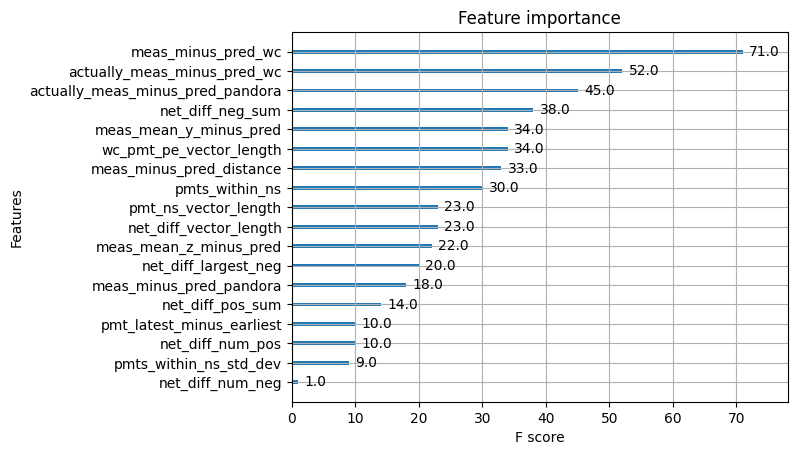

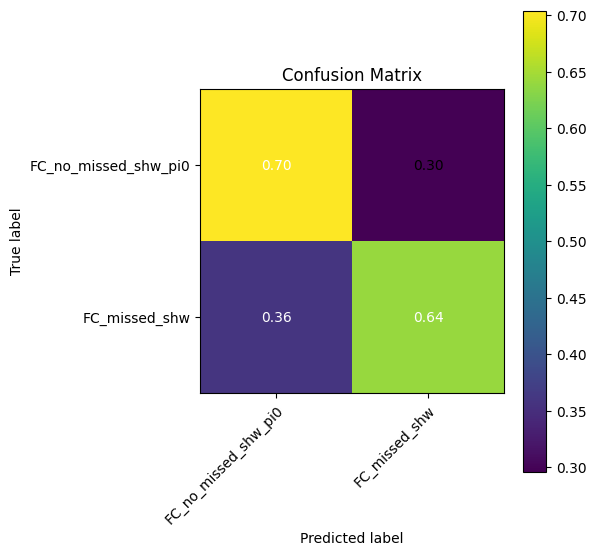

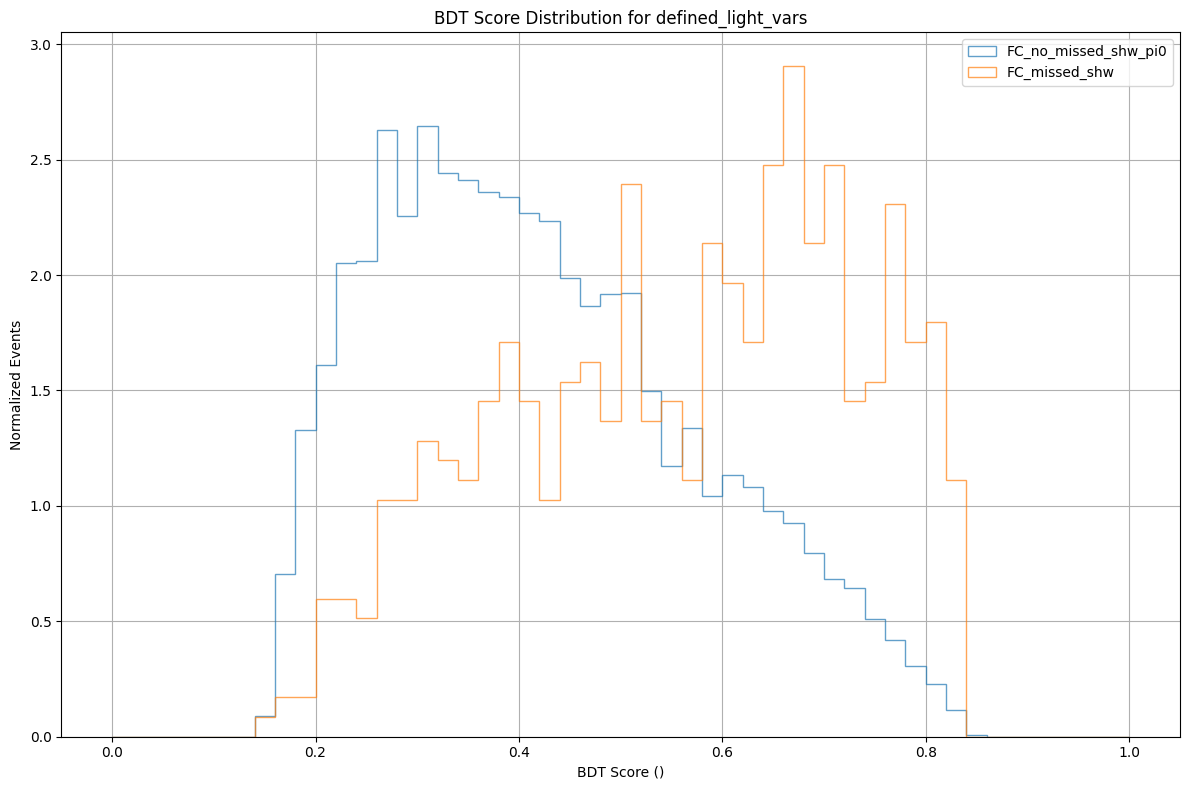

Eval results keys: dict_keys(['validation_0', 'validation_1'])


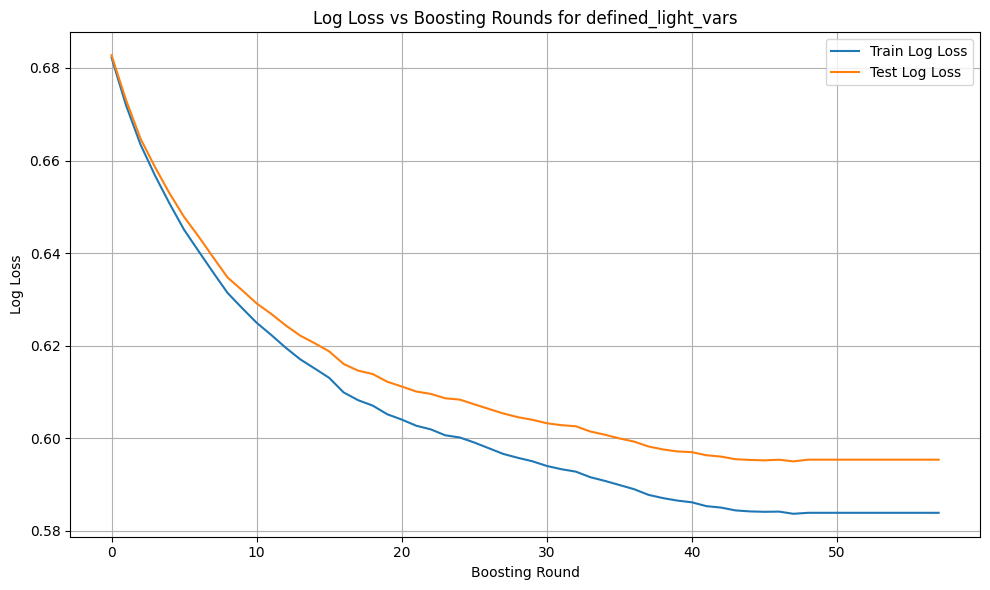

100%|██████████| 100/100 [00:19<00:00,  5.08trial/s, best loss: -0.7238588253222911]
Best hyperparameters: {'colsample_bytree': np.float64(0.7673443812522065), 'gamma': np.float64(3.8058664622514504), 'learning_rate': np.float64(0.07950402114437988), 'max_depth': np.float64(10.0), 'min_child_weight': np.float64(6.0), 'n_estimators': np.float64(600.0), 'reg_alpha': np.float64(134.0), 'reg_lambda': np.float64(0.9189656587866601)}


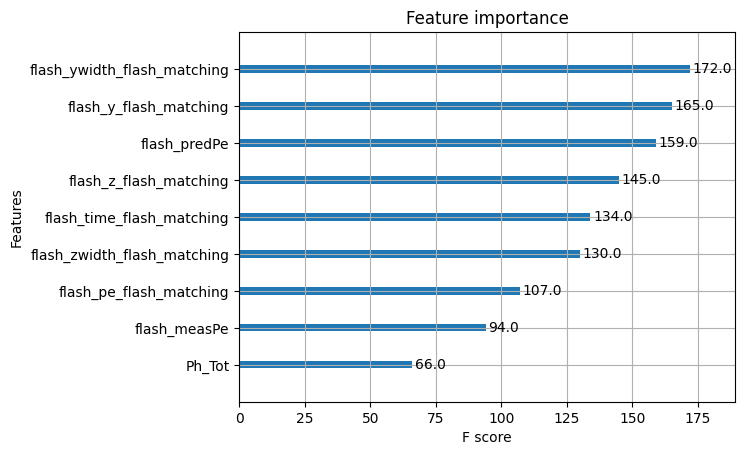

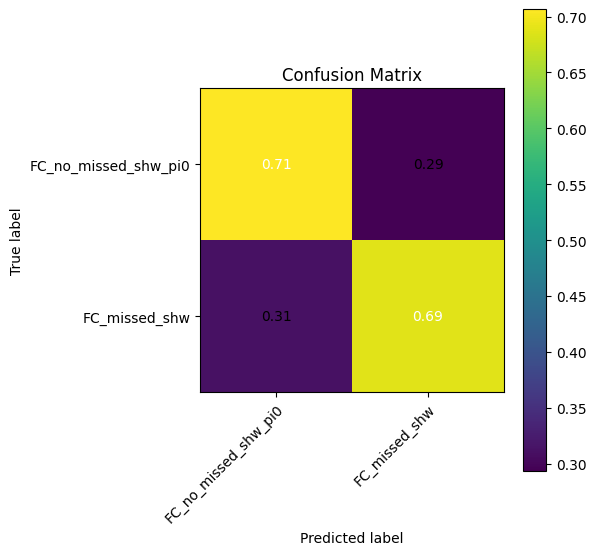

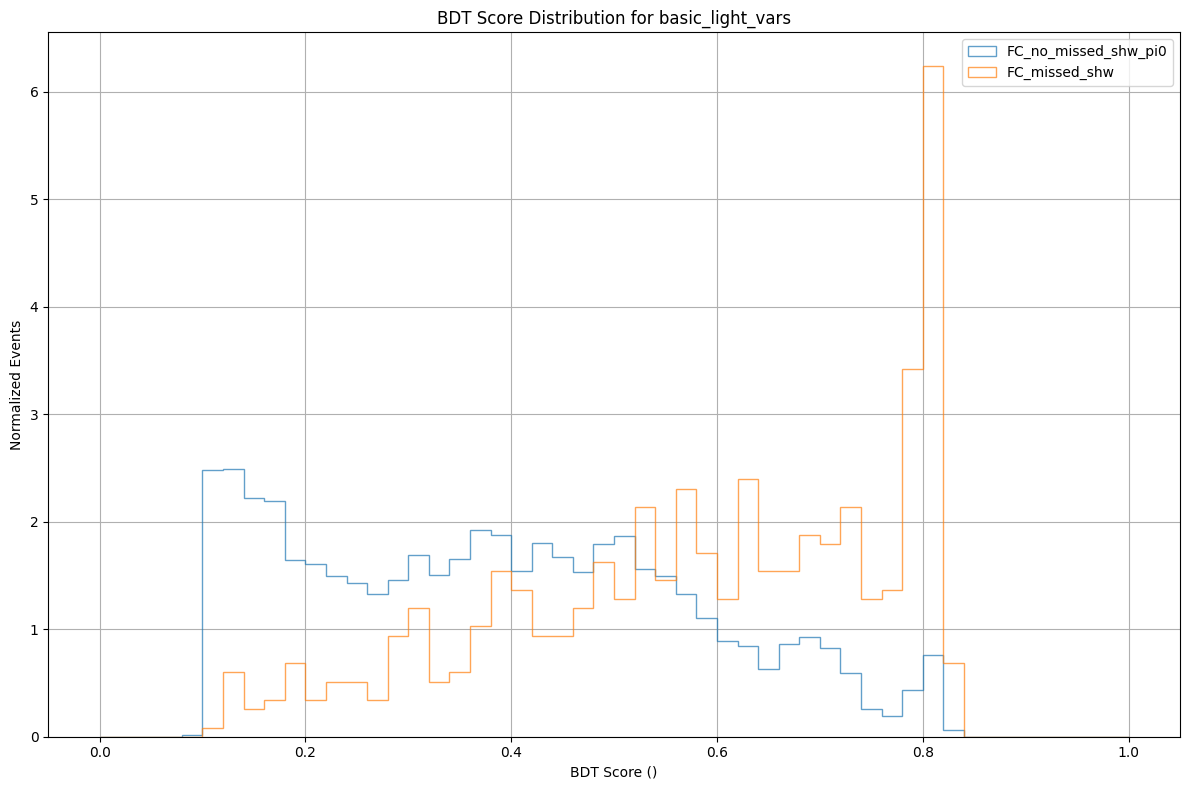

Eval results keys: dict_keys(['validation_0', 'validation_1'])


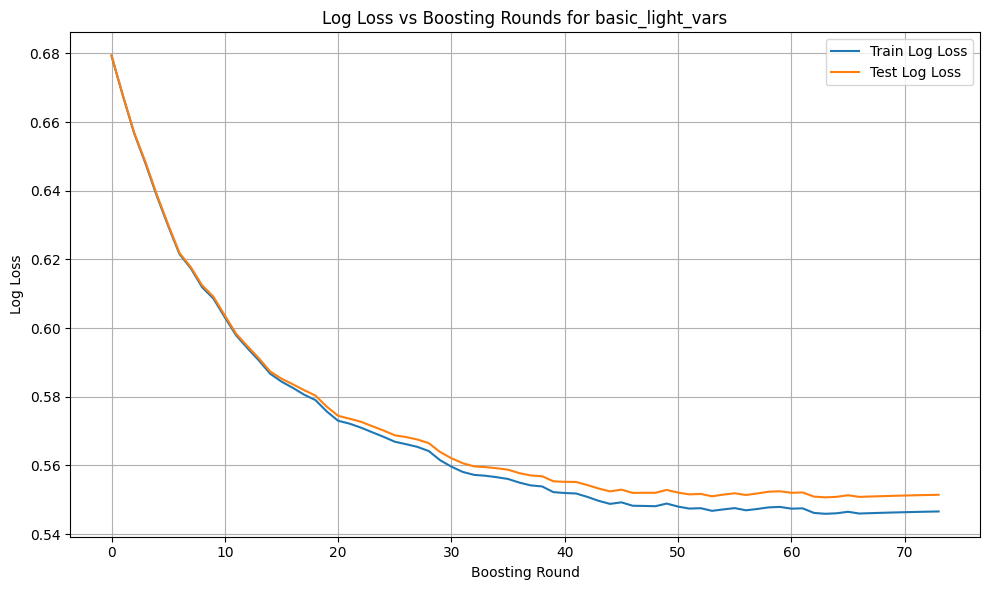

100%|██████████| 100/100 [00:21<00:00,  4.55trial/s, best loss: -0.7435001262018944]
Best hyperparameters: {'colsample_bytree': np.float64(0.5571818128088785), 'gamma': np.float64(7.040348358080751), 'learning_rate': np.float64(0.08003856467654524), 'max_depth': np.float64(9.0), 'min_child_weight': np.float64(1.0), 'n_estimators': np.float64(700.0), 'reg_alpha': np.float64(53.0), 'reg_lambda': np.float64(0.19159229246655762)}


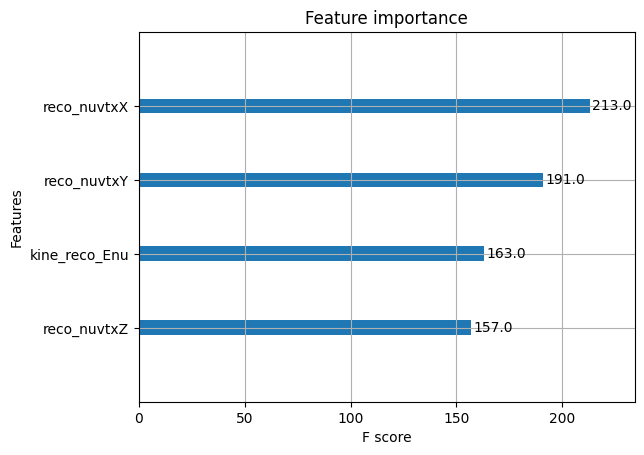

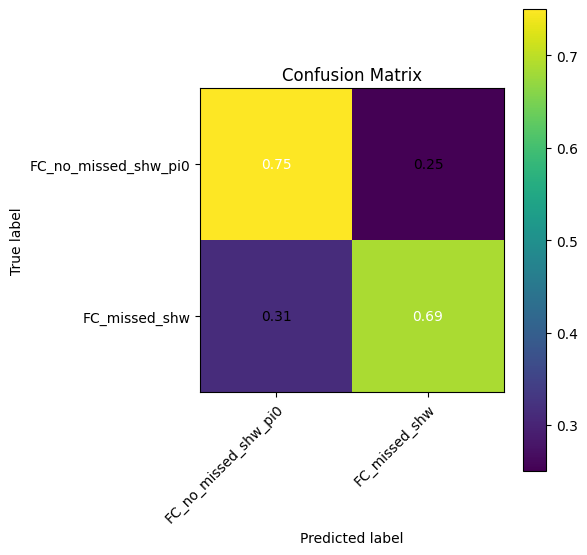

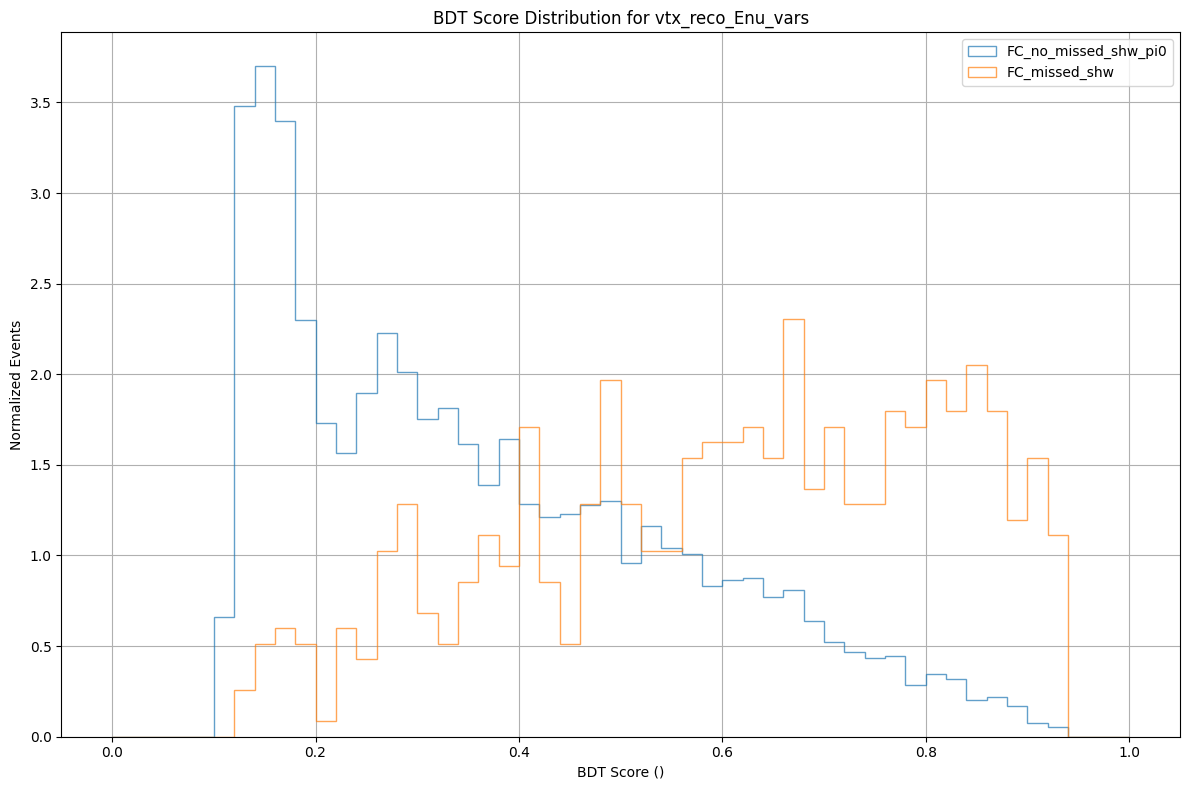

Eval results keys: dict_keys(['validation_0', 'validation_1'])


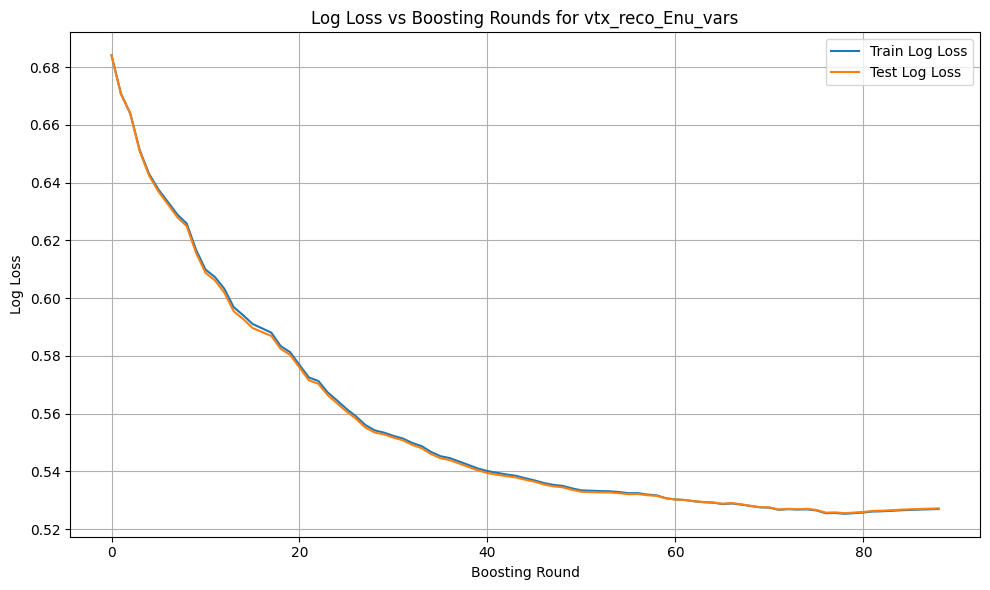

100%|██████████| 100/100 [00:25<00:00,  3.88trial/s, best loss: -0.7553645329815555]
Best hyperparameters: {'colsample_bytree': np.float64(0.5027440166274143), 'gamma': np.float64(8.079055793003416), 'learning_rate': np.float64(0.017108495185217187), 'max_depth': np.float64(7.0), 'min_child_weight': np.float64(1.0), 'n_estimators': np.float64(850.0), 'reg_alpha': np.float64(125.0), 'reg_lambda': np.float64(0.30042135479050835)}


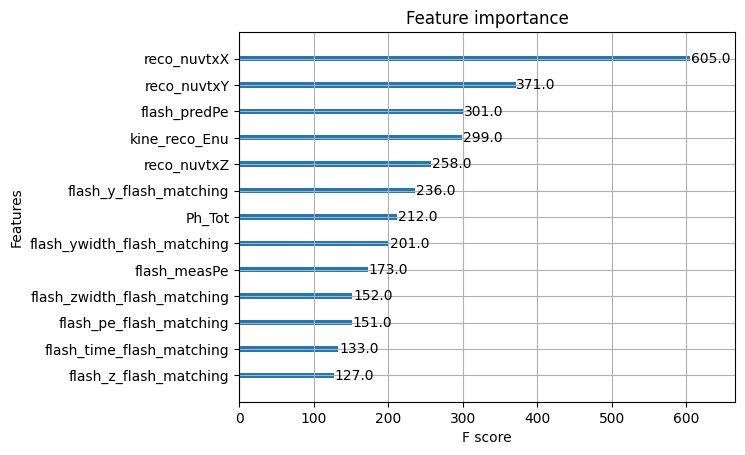

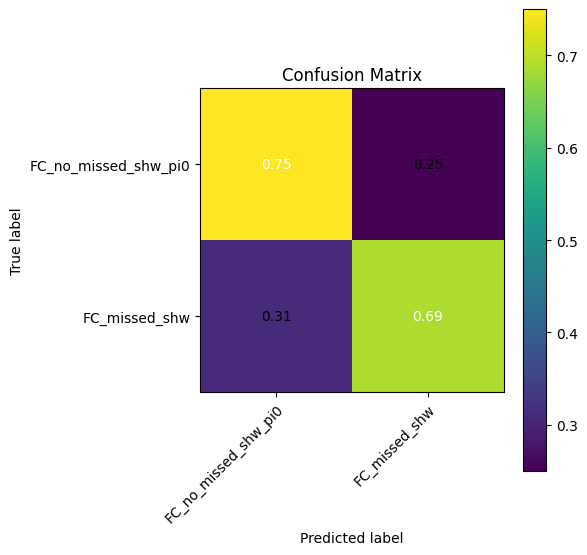

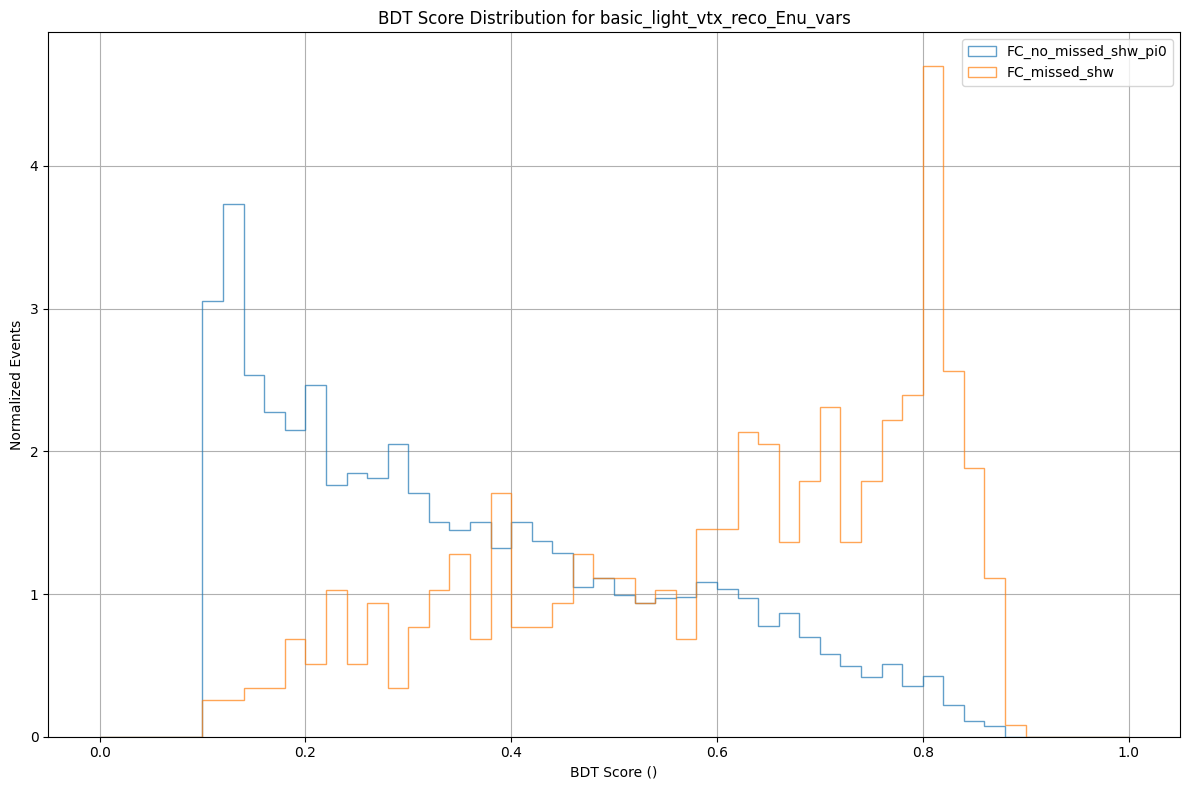

Eval results keys: dict_keys(['validation_0', 'validation_1'])


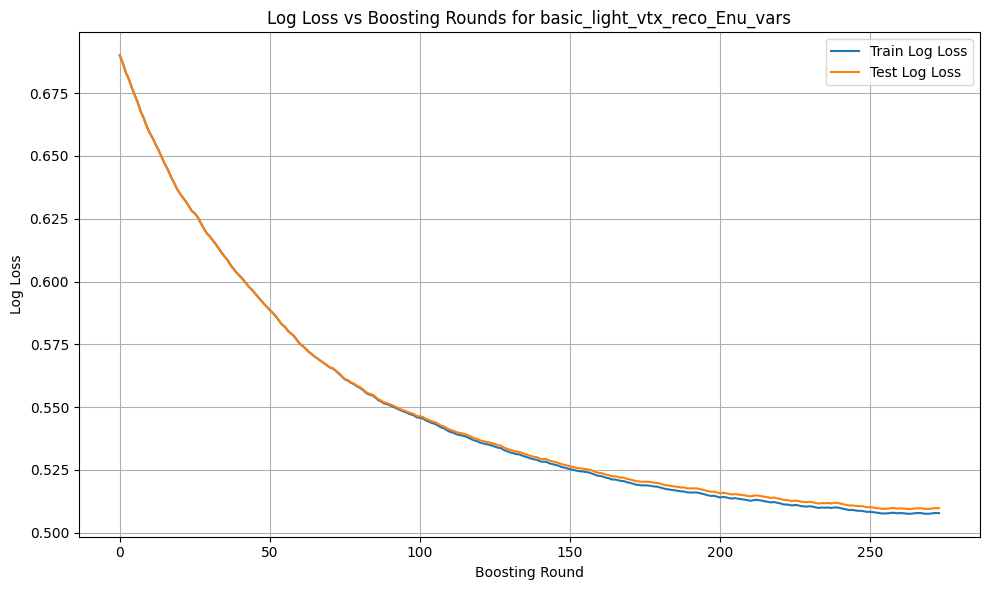

100%|██████████| 100/100 [00:35<00:00,  2.85trial/s, best loss: -0.7546258947238084]
Best hyperparameters: {'colsample_bytree': np.float64(0.8109858160625071), 'gamma': np.float64(3.224254722888059), 'learning_rate': np.float64(0.06915439077776907), 'max_depth': np.float64(6.0), 'min_child_weight': np.float64(6.0), 'n_estimators': np.float64(800.0), 'reg_alpha': np.float64(137.0), 'reg_lambda': np.float64(0.5480946343132375)}


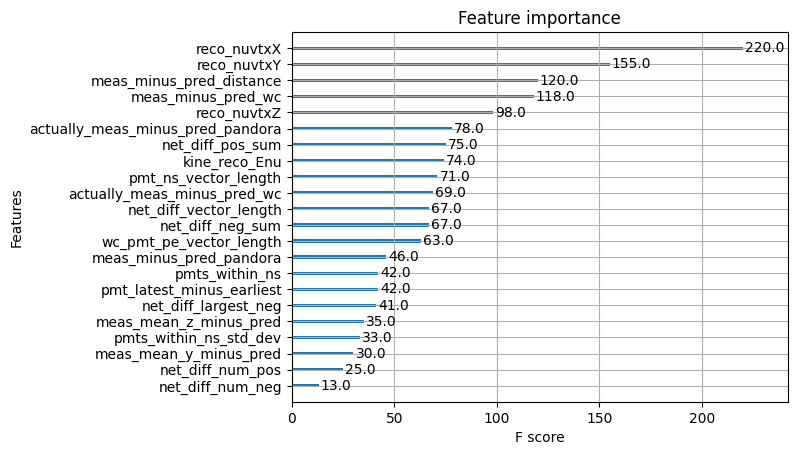

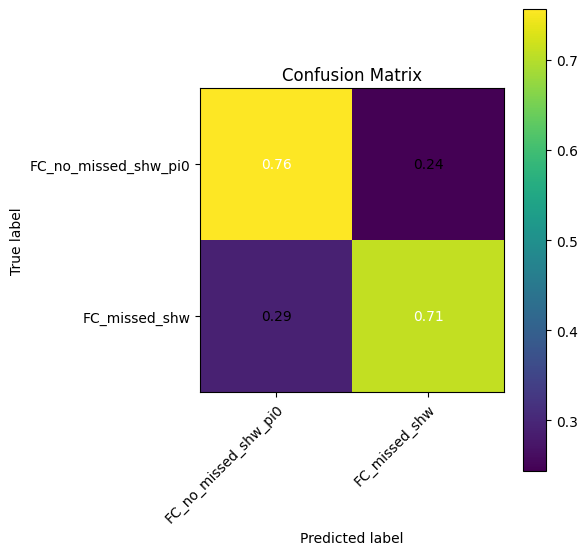

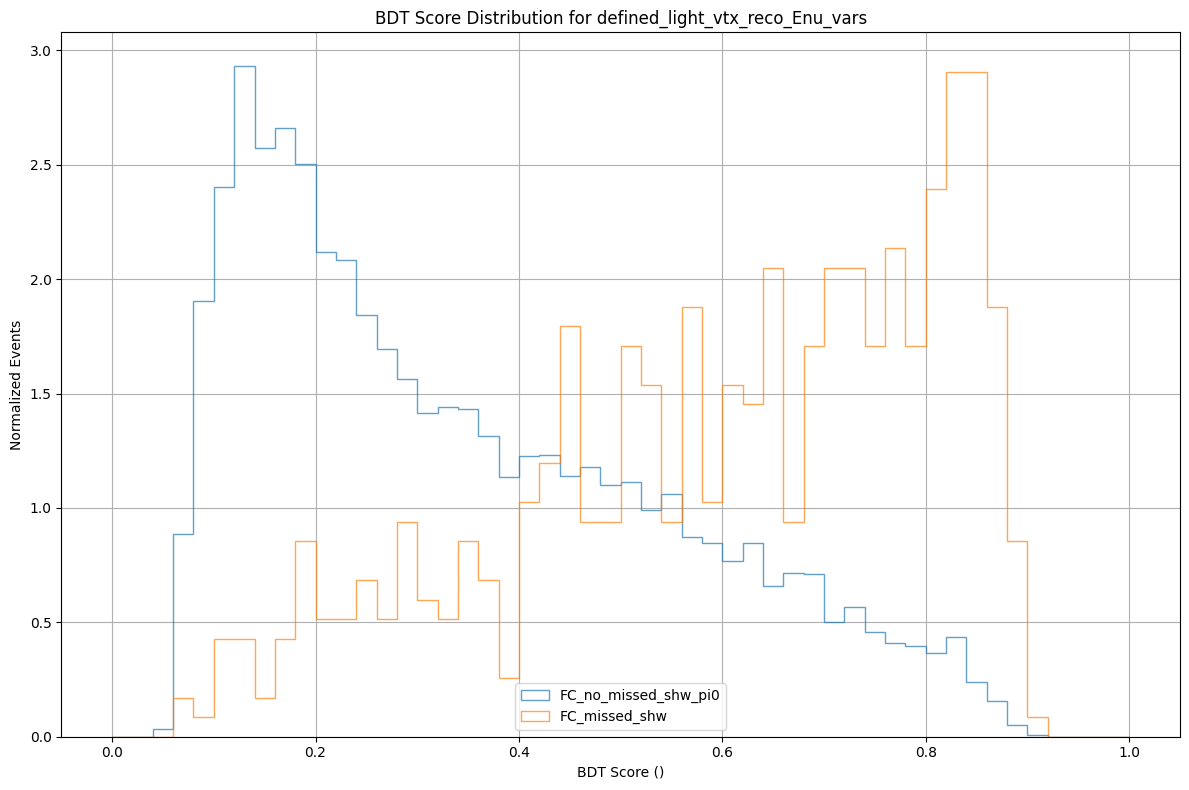

Eval results keys: dict_keys(['validation_0', 'validation_1'])


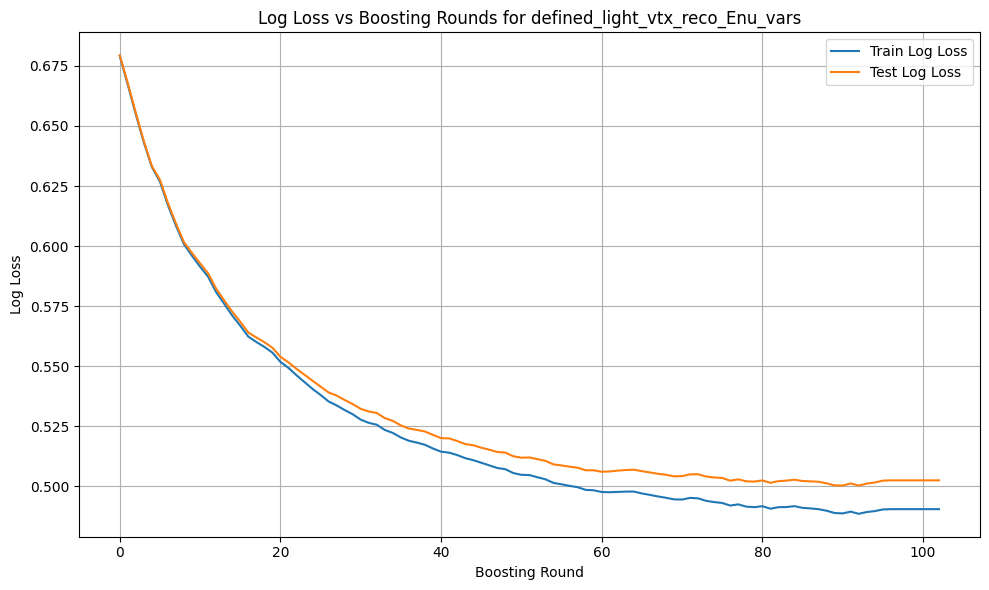

100%|██████████| 100/100 [00:25<00:00,  3.90trial/s, best loss: -0.721720060386416]
Best hyperparameters: {'colsample_bytree': np.float64(0.8415073702523619), 'gamma': np.float64(6.257256802795048), 'learning_rate': np.float64(0.06747173497083475), 'max_depth': np.float64(8.0), 'min_child_weight': np.float64(0.0), 'n_estimators': np.float64(700.0), 'reg_alpha': np.float64(64.0), 'reg_lambda': np.float64(0.6060051885576994)}


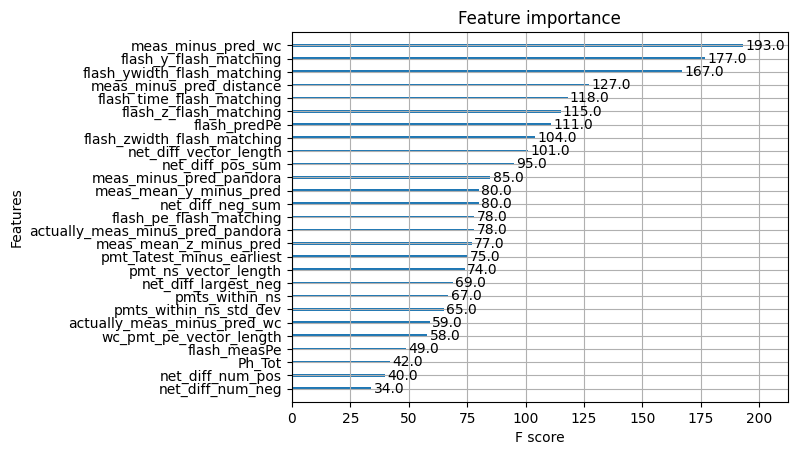

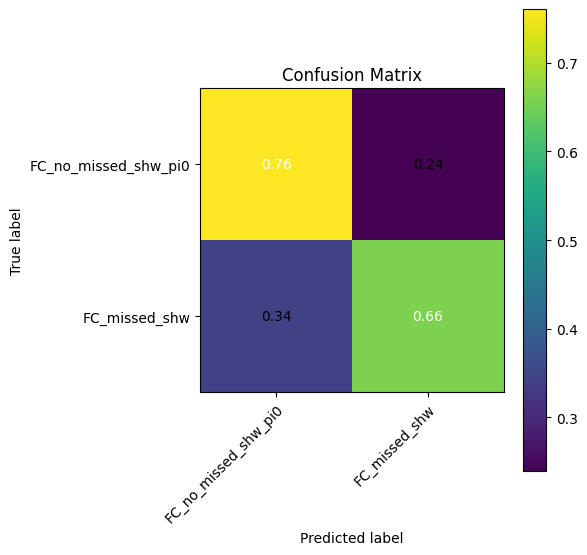

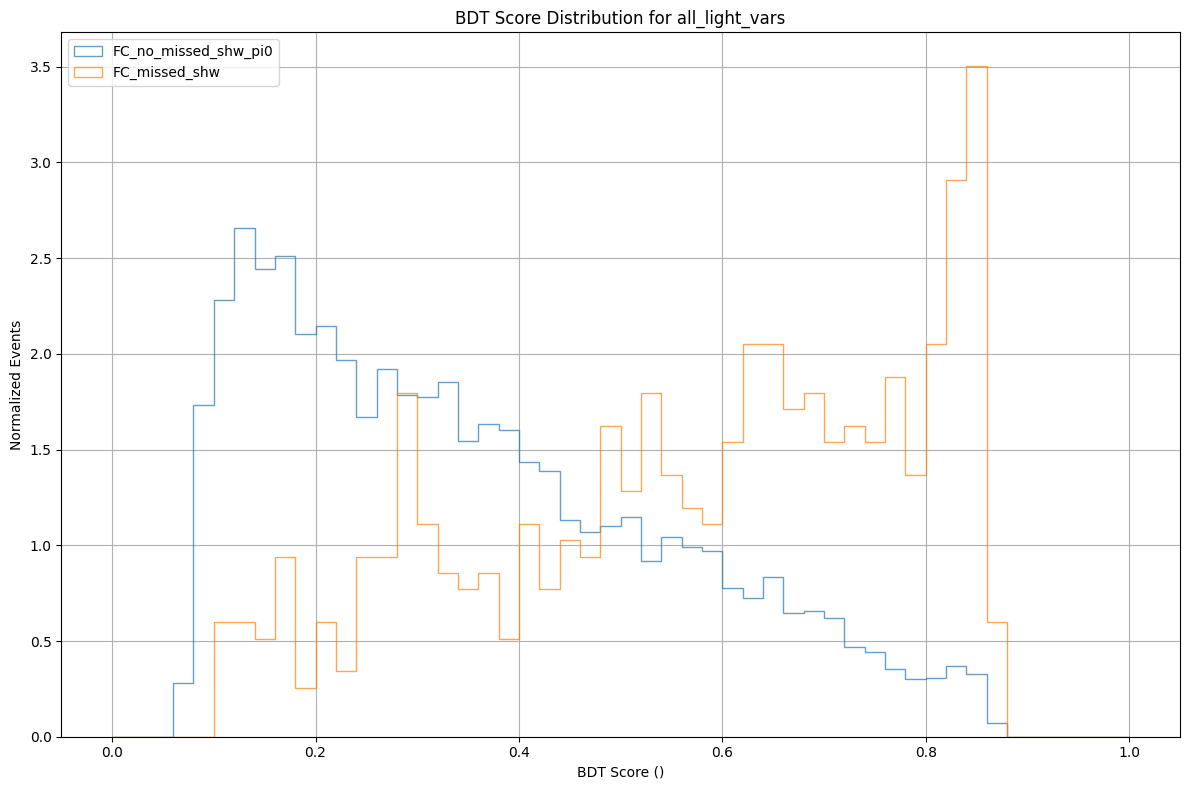

Eval results keys: dict_keys(['validation_0', 'validation_1'])


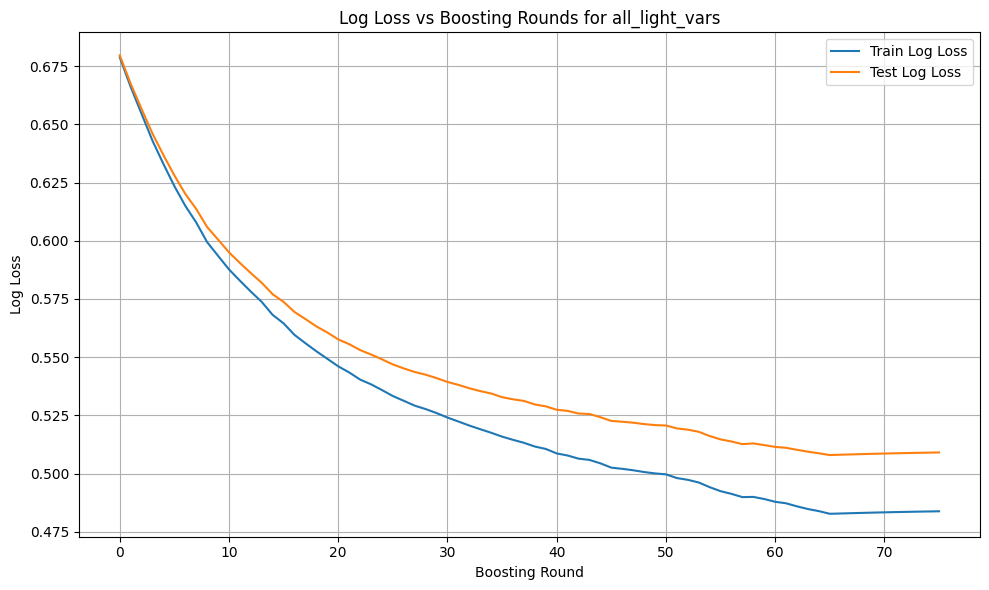

100%|██████████| 100/100 [00:30<00:00,  3.29trial/s, best loss: -0.7646548973478553]
Best hyperparameters: {'colsample_bytree': np.float64(0.5184488435553419), 'gamma': np.float64(6.21949172617578), 'learning_rate': np.float64(0.05554100207733203), 'max_depth': np.float64(10.0), 'min_child_weight': np.float64(2.0), 'n_estimators': np.float64(350.0), 'reg_alpha': np.float64(135.0), 'reg_lambda': np.float64(0.6167502968175865)}


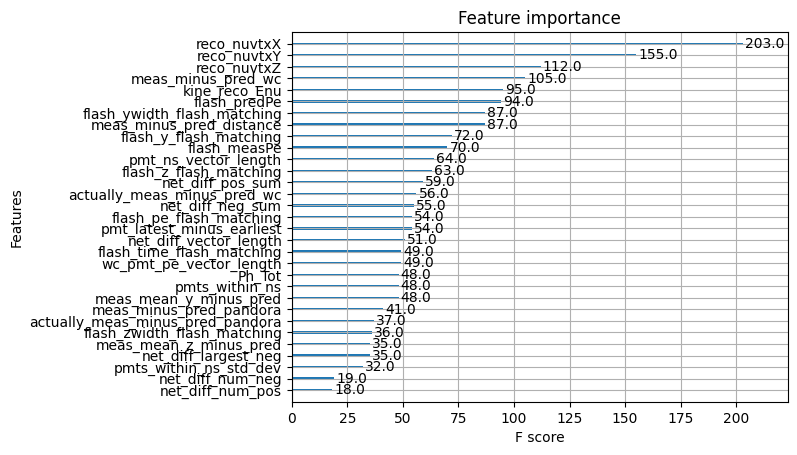

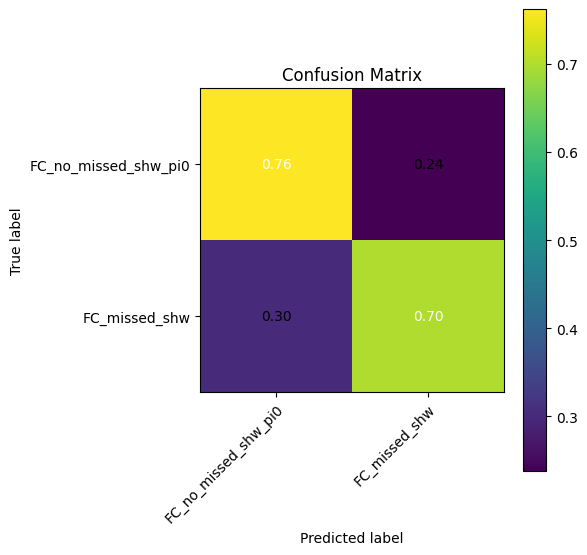

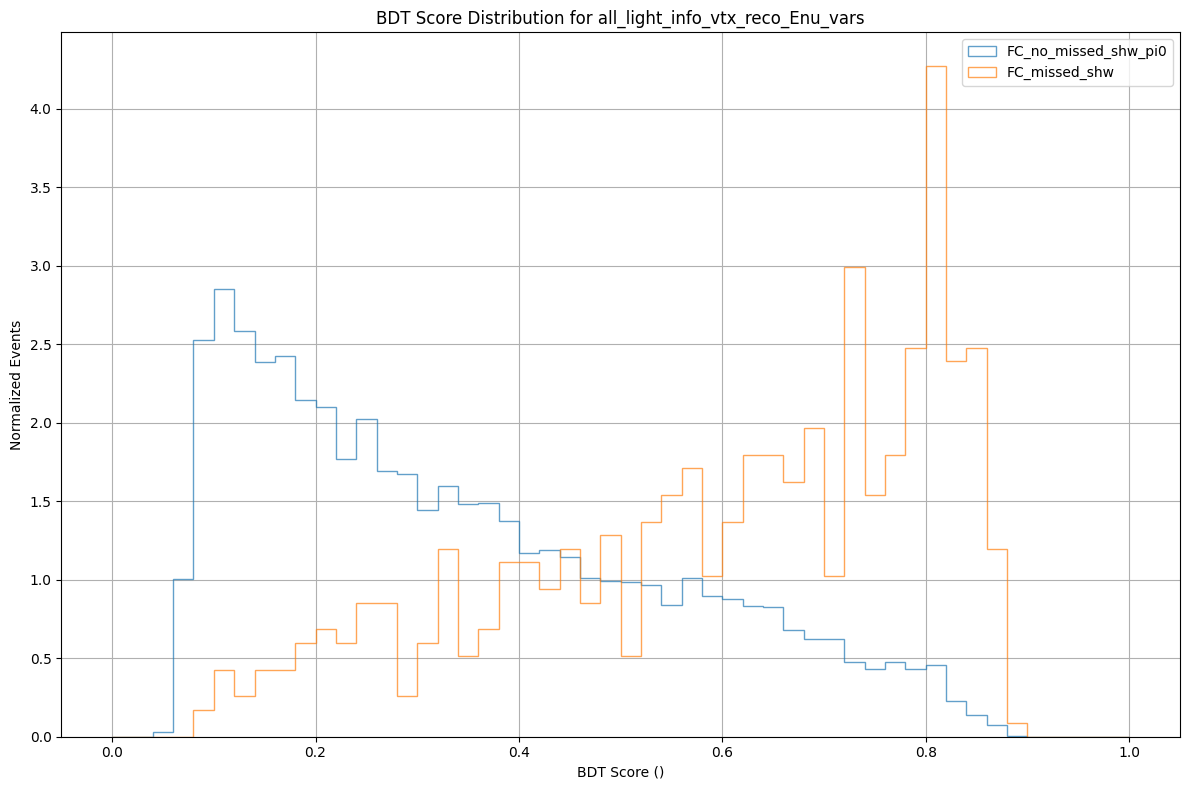

Eval results keys: dict_keys(['validation_0', 'validation_1'])


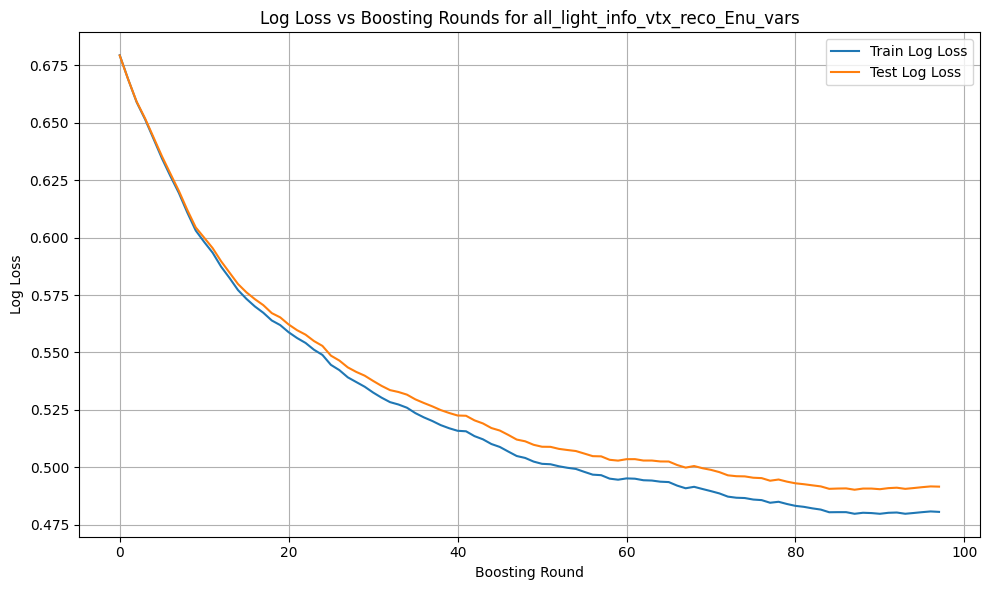

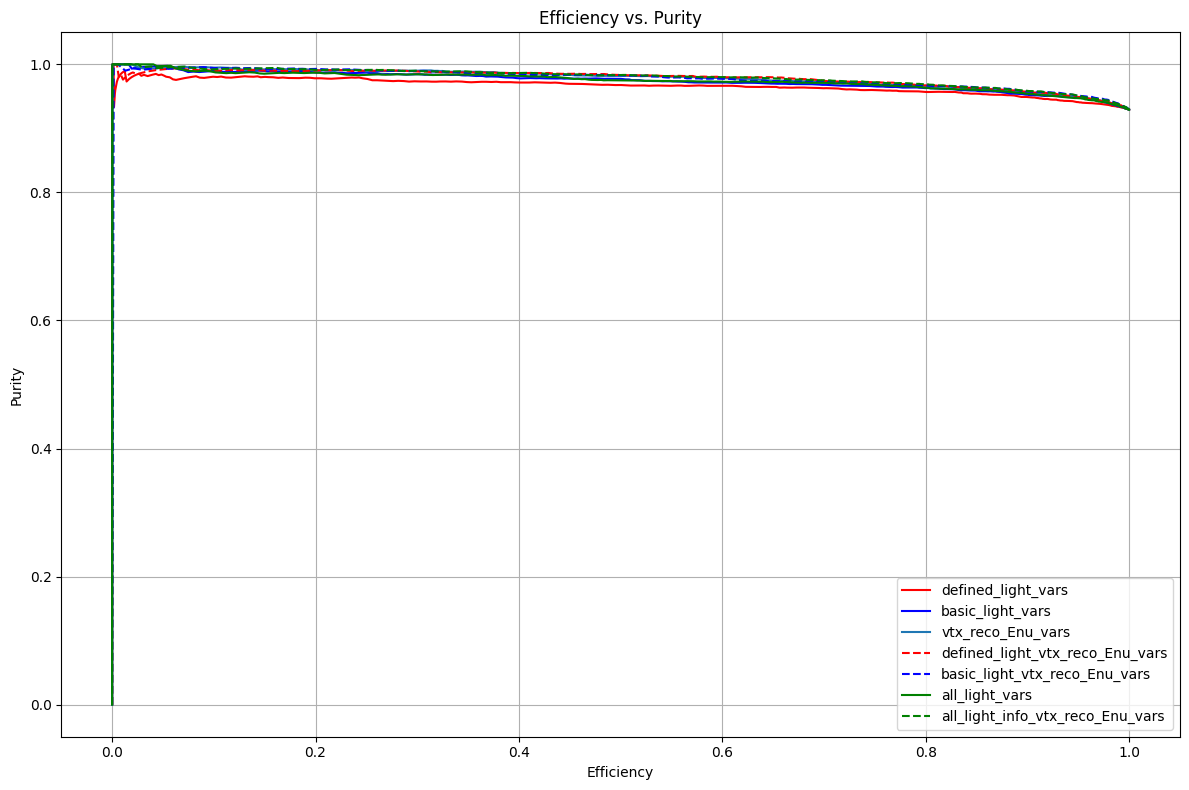

In [154]:

defined_light_vars = [
     'net_diff_neg_sum', 'net_diff_pos_sum', 'net_diff_num_pos', 'net_diff_num_neg',
    'net_diff_vector_length', 'net_diff_largest_neg',
    'actually_meas_minus_pred_pandora', 'meas_minus_pred_pandora',
    'actually_meas_minus_pred_wc', 'meas_minus_pred_wc',
    'wc_pmt_pe_vector_length', 'pmt_latest_minus_earliest', 'pmts_within_ns_std_dev', 'meas_mean_z_minus_pred', 'meas_mean_y_minus_pred', 'meas_minus_pred_distance', 
    'pmts_within_ns', 'pmt_ns_vector_length']


basic_light_vars = [
    'flash_pe_flash_matching', # sum of above vector
    'flash_time_flash_matching', # 
    'flash_y_flash_matching',
    'flash_z_flash_matching',
    'flash_timewidth_flash_matching',
    'flash_ywidth_flash_matching',
    'flash_zwidth_flash_matching',
    "Ph_Tot", 
    'flash_measPe',
    'flash_predPe']

light_bdt = ['net_diff_neg_sum', 'net_diff_pos_sum', 'net_diff_num_pos', 'net_diff_num_neg',
    'net_diff_vector_length', 'net_diff_largest_neg',
    'actually_meas_minus_pred_pandora', 'meas_minus_pred_pandora',
    'actually_meas_minus_pred_wc', 'meas_minus_pred_wc',
    'wc_pmt_pe_vector_length', 'pmt_latest_minus_earliest', 'pmts_within_ns_std_dev', 'meas_mean_z_minus_pred', 'meas_mean_y_minus_pred', 'meas_minus_pred_distance', 
    'pmts_within_ns', 'pmt_ns_vector_length', 'flash_pe_flash_matching',
    'flash_time_flash_matching', "Ph_Tot", 
    'flash_measPe',
    'flash_predPe'
]

all_light_vars = defined_light_vars + basic_light_vars

vtx_reco_Enu_vars = [
    'kine_reco_Enu', 'reco_nuvtxX', 'reco_nuvtxY', 'reco_nuvtxZ'
]

defined_light_vtx_reco_Enu_vars = defined_light_vars + vtx_reco_Enu_vars

basic_light_vtx_reco_Enu_vars = basic_light_vars + vtx_reco_Enu_vars

all_light_info_vtx_reco_Enu_vars = all_light_vars + vtx_reco_Enu_vars

random_state = 42

light_model, light_y_proba, light_y_test = train_bdt_on_missed_shower(all_df, defined_light_vars, vars_name='defined_light_vars', random_state=42)
basic_light_model, basic_light_y_proba, basic_light_y_test = train_bdt_on_missed_shower(all_df, basic_light_vars, vars_name='basic_light_vars', )

classic_model, classic_y_proba, classic_y_test = train_bdt_on_missed_shower(all_df, vtx_reco_Enu_vars, vars_name='vtx_reco_Enu_vars')

full_model, full_y_proba, full_y_test = train_bdt_on_missed_shower(all_df, basic_light_vtx_reco_Enu_vars, vars_name='basic_light_vtx_reco_Enu_vars')
defined_vtx_model, defined_vtx_y_proba, defined_vtx_y_test = train_bdt_on_missed_shower(all_df, defined_light_vtx_reco_Enu_vars, vars_name='defined_light_vtx_reco_Enu_vars')

joined_light_model, joined_light_y_proba, joined_light_y_test = train_bdt_on_missed_shower(all_df, all_light_vars, vars_name='all_light_vars')
everything_model, everything_y_proba, everything_y_test = train_bdt_on_missed_shower(all_df, all_light_info_vtx_reco_Enu_vars, vars_name='all_light_info_vtx_reco_Enu_vars')


light_thresholds, light_efficiencies, light_purities = calculate_efficiency_purity(light_y_proba, light_y_test)
basic_light_thresholds, basic_light_efficiencies, basic_light_purities = calculate_efficiency_purity(basic_light_y_proba, basic_light_y_test)
classic_thresholds, classic_efficiencies, classic_purities = calculate_efficiency_purity(classic_y_proba, classic_y_test)
defined_vtx_thresholds, defined_vtx_efficiencies, defined_vtx_purities = calculate_efficiency_purity(defined_vtx_y_proba, defined_vtx_y_test)
full_thresholds, full_efficiencies, full_purities = calculate_efficiency_purity(full_y_proba, full_y_test)
joined_light_thresholds, joined_light_efficiencies, joined_light_purities = calculate_efficiency_purity(joined_light_y_proba, joined_light_y_test)
everything_light_thresholds, everything_light_efficiencies, everything_light_purities = calculate_efficiency_purity(everything_y_proba, everything_y_test)

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix


plt.figure(figsize=(12, 8))
plt.plot(light_efficiencies, light_purities, label='defined_light_vars', color='red')
plt.plot(basic_light_efficiencies, basic_light_purities, label='basic_light_vars', color='blue')
plt.plot(classic_efficiencies, classic_purities, label='vtx_reco_Enu_vars')
plt.plot(defined_vtx_efficiencies, defined_vtx_purities, label='defined_light_vtx_reco_Enu_vars', color='red', linestyle='--')
plt.plot(full_efficiencies, full_purities, label='basic_light_vtx_reco_Enu_vars', color='blue', linestyle='--')
plt.plot(joined_light_efficiencies, joined_light_purities, label='all_light_vars', color='green')
plt.plot(everything_light_efficiencies, everything_light_purities, label='all_light_info_vtx_reco_Enu_vars', linestyle='--', color='green')
plt.xlabel('Efficiency')
plt.ylabel('Purity')
plt.title('Efficiency vs. Purity')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

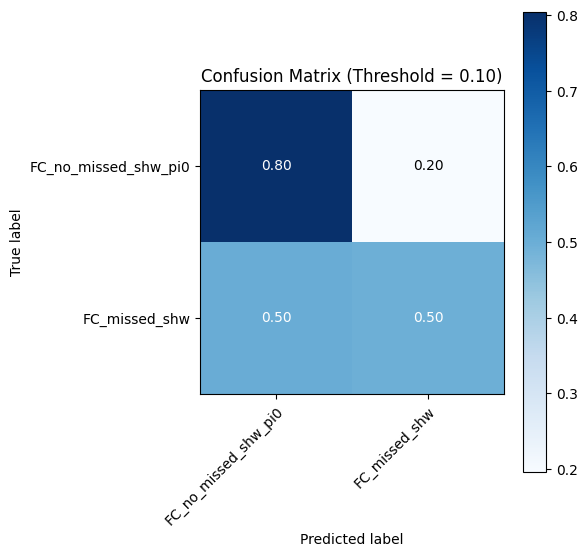

In [84]:
def plot_confusion_matrix_from_proba(y_true, y_proba, threshold=0.5, labels=None, normalize=False, title=None, cmap=plt.cm.Blues):
    """
    Plots a confusion matrix given BDT scores and a threshold.

    Parameters:
    - y_true: Ground truth binary labels (0/1).
    - y_proba: BDT score (probability of class 1).
    - threshold: Threshold for converting probabilities to binary predictions.
    - labels: List of label names (e.g., ["Class 0", "Class 1"]).
    - normalize: Normalize confusion matrix rows.
    - title: Plot title.
    - cmap: Colormap.
    """
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    if labels is None:
        labels = [str(i) for i in np.unique(y_true)]

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)

    if title is None:
        title = f'Confusion Matrix (Threshold = {threshold:.2f})'

    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        xlabel='Predicted label',
        ylabel='True label',
        title=title
    )

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    fig.tight_layout()
    plt.grid(False)
    plt.show()

plot_confusion_matrix_from_proba(
    y_true=y_test,
    y_proba=y_proba,
    threshold=0.1,
    labels=["FC_no_missed_shw_pi0", "FC_missed_shw"],
    normalize=True
)


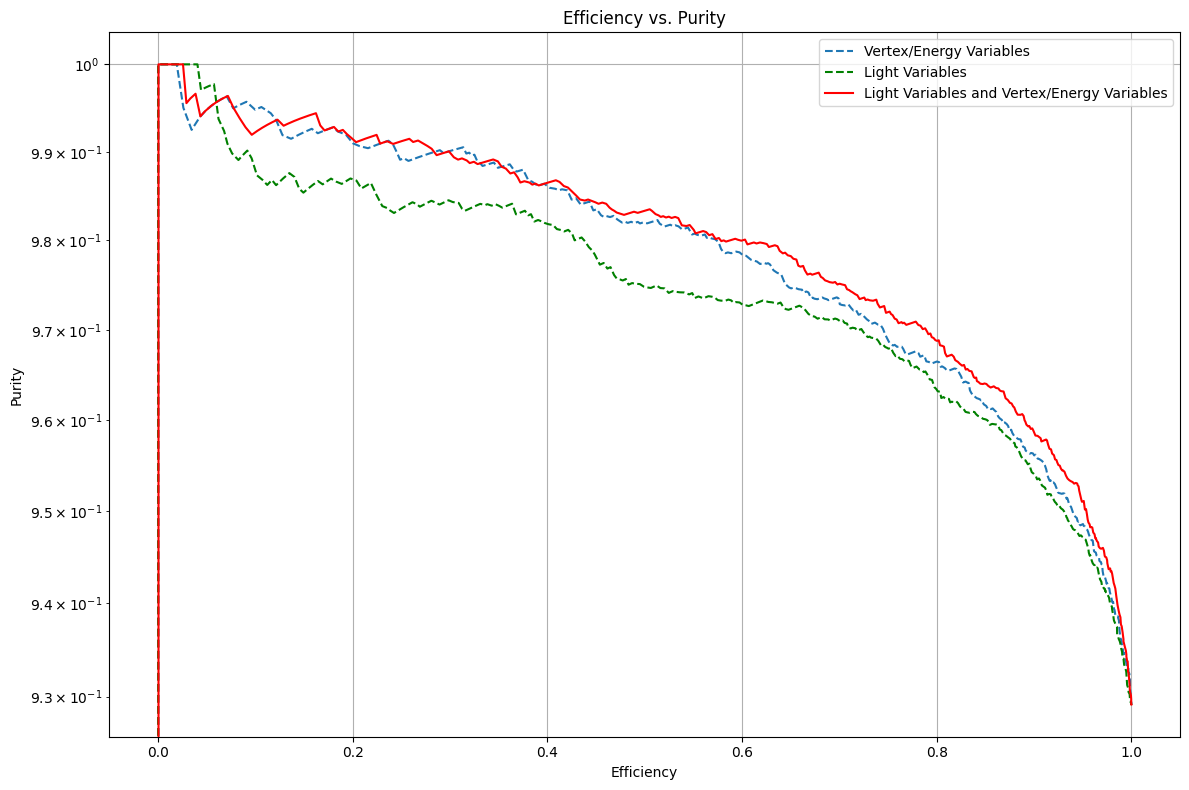

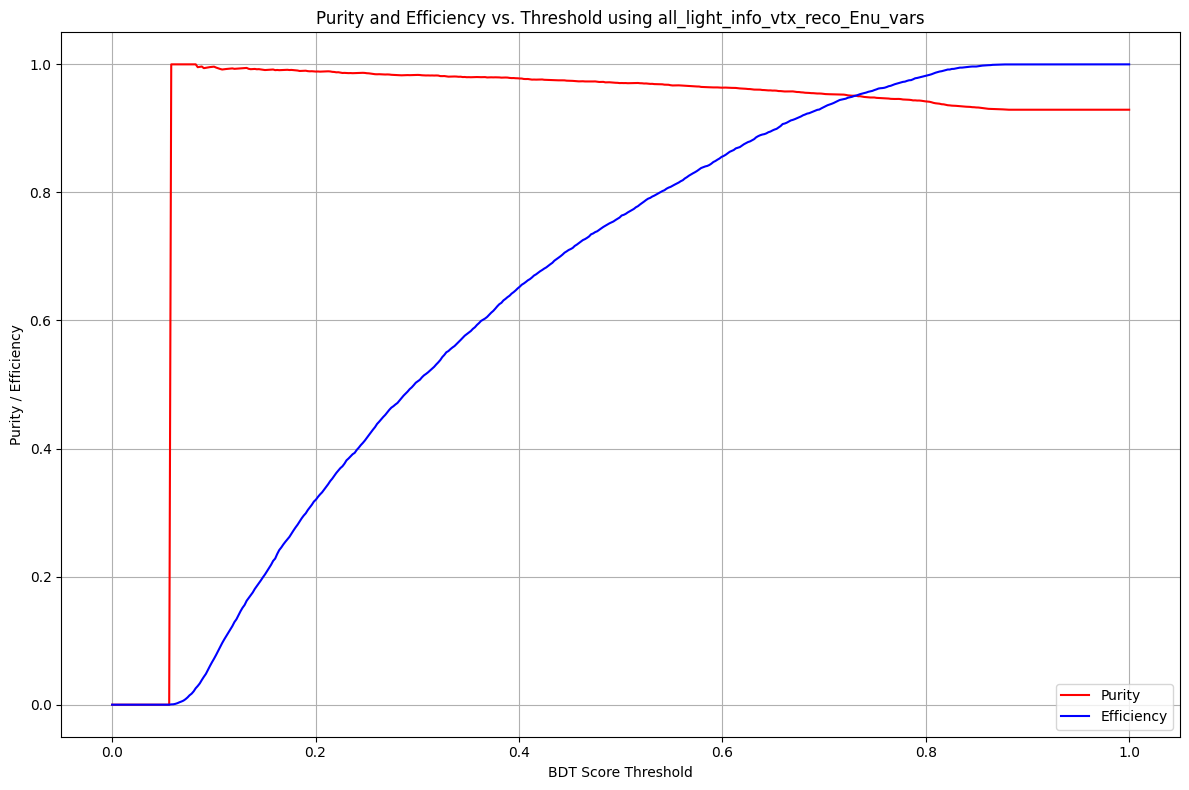

In [156]:
plt.figure(figsize=(12, 8))
#plt.plot(light_efficiencies, light_purities, label='defined_light_vars', color='red')
#plt.plot(basic_light_efficiencies, basic_light_purities, label='basic_light_vars', color='blue')
plt.plot(classic_efficiencies, classic_purities, label='Vertex/Energy Variables', linestyle='--')
#plt.plot(defined_vtx_efficiencies, defined_vtx_purities, label='defined_light_vtx_reco_Enu_vars', color='red', linestyle='--')
#plt.plot(full_efficiencies, full_purities, label='basic_light_vtx_reco_Enu_vars', color='blue', linestyle='--')
plt.plot(joined_light_efficiencies, joined_light_purities, label='Light Variables', color='green', linestyle='--')
plt.plot(everything_light_efficiencies, everything_light_purities, label='Light Variables and Vertex/Energy Variables', color='red')
plt.xlabel('Efficiency')
# y scale log
plt.yscale('log')
plt.ylabel('Purity')
plt.title('Efficiency vs. Purity')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# plot efficiency and purity at every point just for all vars:
plt.figure(figsize=(12, 8))
plt.plot(everything_light_thresholds, everything_light_purities, label='Purity', color='red')
plt.plot(everything_light_thresholds, everything_light_efficiencies, label='Efficiency', color='blue')
plt.xlabel('BDT Score Threshold')
plt.ylabel('Purity / Efficiency')
plt.title('Purity and Efficiency vs. Threshold using all_light_info_vtx_reco_Enu_vars')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
